# All Analysis

This notebooks aims at making All-encompasing Data Frame and Structures as well as Explore data on a more Inter-Subject Level


## Preprocessing 

#### Parameters and env creations:

Get our parameters. Create all necessery Directories and Name our analyses

In [386]:
#### ---- Options File ---- ####

import os 
import pandas as pd
import numpy as np

import pickle#### ---- Options File ---- ####

import os 
import pandas as pd
import numpy as np

import pickle

ExpName = 'FirstExperiment'  # 'FirstExperiment' or 'SecondExp'

### Options
est            = 'zscore'  # Whether to Zscore the data: # 'Zscore' or ''  
partial        = ''        # Whetheer to test Part of Experiment (first or second half): # 'first' or 'second' or ''
excludeDs      =["DS04","DS25"] #["DS03", "DS08","DS14","DS23"]#["DS03", "DS08","DS14","DS23"]  # DS04 or DS25  # Excludsion of given subjects (List)
excludeDSTrial = []        # Exclusion of specific trials in a given DS: # construct our tuple out of values from both olumn thus making it easier to compare via isin() 
if len(excludeDs) >0:
    exclusionName= '_'.join(excludeDs)
else:
    exclusionName= ''

### Analysis Name 
currentANalysisName = "NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean"
workingDir = os.getcwd();

mm = True;
### Create a Directory for Summary Statistics: W
statPath = (os.path.join(workingDir,ExpName,currentANalysisName,'summary',f"mode_{est}_{partial}_{exclusionName}_mm{mm}"))
os.makedirs(statPath, exist_ok=True)

### Create a .gitignore file in the summary directory
gi_path = os.path.join(workingDir,ExpName,currentANalysisName, ".gitignore")
gitignore_text = """\
# Ignore everything in this folder
*

# …but keep this file
!.gitignore
"""
# Only create it if it’s not already there
if not os.path.isfile(gi_path):
    with open(gi_path, "w", encoding="utf-8") as fh:
        fh.write(gitignore_text)

### Open Final stat Log: 
log_file = open(os.path.join(statPath,f"finalStatLog_{est}_{exclusionName}.txt"),'w+')


### Create Empty Result Data Structures:
# For Testing Main Effects 
coefs = []
zvals = []
pvals = []
conf1 = []
conf2 = []

# For Testing Trial Effect
coefsT = []
zvalsT = []
pvalsT = []
conf1T = []
conf2T = []

indx     = []
eye      = []
analysis = []


In [387]:
### Load Data By Subjects --> Greater Validity

subjects = [f for f in os.listdir(os.path.join(workingDir,ExpName,currentANalysisName,'individuals')) if  not os.path.isfile(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'individuals'), f))] # get all the filenames
subjects
allData = []
subjDict = {}
for i,subj in enumerate(subjects):
    print(f"DS{int(i+1):02d}: Processing subject {subj}")
    subjDict[f"DS{int(i+1):02d}"] = subj
    with open(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), 'rb') as file:
        currData = pickle.load(file)  # Call load method to deserialze
        #shutil.copyfile(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), os.path.join(os.path.split(workingDir)[0],'DataPack',ExpName,f"{subj}_preprocessed.pickle"))
        allData.append(currData)


DS01: Processing subject AGKO2706
DS02: Processing subject ALPR1107
DS03: Processing subject ALRU0107
DS04: Processing subject ARNI0107
DS05: Processing subject BEBA1207
DS06: Processing subject BEKA0107
DS07: Processing subject DOBA2406
DS08: Processing subject DOKL0207
DS09: Processing subject EWTR0107
DS10: Processing subject HUKO2905
DS11: Processing subject JADE0107
DS12: Processing subject JUBR0107
DS13: Processing subject JUFi0506
DS14: Processing subject JUSZ1107
DS15: Processing subject KAMI2606
DS16: Processing subject KASZ2806
DS17: Processing subject KIGI1207
DS18: Processing subject KRWI3006
DS19: Processing subject MAKA0506
DS20: Processing subject MAPA2306
DS21: Processing subject MAPA2606
DS22: Processing subject MATR2905
DS23: Processing subject MICZ0306
DS24: Processing subject NAZI2706
DS25: Processing subject NIJA0506
DS26: Processing subject PASZ0107
DS27: Processing subject TYSI0306
DS28: Processing subject WIBA2406
DS29: Processing subject WIGA2806
DS30: Processi

In [388]:


with open(r'C:\Users\barak\Documents\GitHub\startegicMW_lite\DataPack\data_second\PreprocessData2.pickle', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(allData, f, pickle.HIGHEST_PROTOCOL)

### Preprocess Pupil Data:

Preprocessing Aimed at getting True data and making one big structure:
1) grand_df - containing all Pupilometric Data
2) df_last10s_all - Containing Raw pupilometric Measures from last 10s of experiment

In [389]:
### Get Saccade and Blink Data


def get_BlinkSaccadesVariables(currentData,GazeConstraints=None):
    """
        This funciton aims at gathering different measures fromthe saccades and blinks for each participant
    
    """
    meausres = {
        ('Saccades','','SaccDistance'): [],         # 
         ('Saccades','','SaccNumber'): [],  
         ('Saccades','','SaccVelocity'): [],
         ('Saccades','','SaccVelocitySd'): [],
         ('Saccades','','SaccAmplitude'): [],
         ('Saccades','','SaccAmplitudeSd'): [],
         ('Saccades','','SaccDuration'): [],
         ('Saccades','','SaccDurationeSd'): [],
         ('Saccades','','FixLength'): [],
         ('Saccades','','FixLengthSd'): [],
         ('Blinks','','BlinkNumber'): [],
         ('Blinks','','BlinkRate'): [],
         ('Blinks','','BlinkDuration'): [],
         ('Blinks','','BlinkDurationSd'): []
    }
    

    for part in currentData['data']['STORY_1'].keys():

        if "all" in currentANalysisName:
            currentSaccDF = currentData['data']['STORY_1'][part]['Saccades']
            currentBlinkDF = currentData['data']['STORY_1'][part]['Blinks']  
            currentTming = currentData['data']['STORY_1'][part]['Gaze']
            interw = currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[0];
           
        else:
            currentSaccDF = currentData['data']['STORY_1'][part]['Saccades'] [( currentData['data']['STORY_1'][part]['Saccades']['Beg']  >= currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - 10000)]
            currentBlinkDF = currentData['data']['STORY_1'][part]['Blinks']  [( currentData['data']['STORY_1'][part]['Blinks']['Beg']  >= currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - 10000)]
            currentTming = currentData['data']['STORY_1'][part]['Gaze'][(currentData['data']['STORY_1'][part]['Gaze']['TimePoint'] >= currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - 10000)]
            interw = 10000

        # ### Fixation Length
        # LeftFIxInd = list(np.diff(currentSaccDF[currentSaccDF['Eye'] == 'L']['End']) - currentSaccDF[currentSaccDF['Eye'] == 'L']['Duration'].iloc[1:])
        # RightFixInd = list(np.diff(currentSaccDF[currentSaccDF['Eye'] == 'R']['End']) - currentSaccDF[currentSaccDF['Eye'] == 'R']['Duration'].iloc[1:])
        # fixBeg = pd.concat([currentSaccDF[currentSaccDF['Eye'] == 'R']['End'].iloc[0:-1]+2,currentSaccDF[currentSaccDF['Eye'] == 'L']['End'].iloc[0:-1]+2]).sort_index()
        # fixEnd = pd.concat([currentSaccDF[currentSaccDF['Eye'] == 'R']['Beg'].iloc[1:]-2,currentSaccDF[currentSaccDF['Eye'] == 'L']['Beg'].iloc[1:]-2]).sort_index()
        # #fixLen = list(pd.concat([RightFixInd,LeftFIxInd]).sort_index())

        # print(part)
        # print(currentSaccDF[currentSaccDF['Eye'] == 'L'])
        # RightFixInd.append(currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - currentSaccDF[currentSaccDF['Eye'] == 'R']['End'].iloc[-1])
        # LeftFIxInd.append(currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - currentSaccDF[currentSaccDF['Eye'] == 'L']['End'].iloc[-1])



        ## Collapse for one Eye: (Choose the Higher Number)
        if len(currentSaccDF[currentSaccDF['Eye'] == 'L']) >= len(currentSaccDF[currentSaccDF['Eye'] == 'R']):
            currentSaccDF = currentSaccDF[currentSaccDF['Eye'] == 'L']
        else:
            currentSaccDF = currentSaccDF[currentSaccDF['Eye'] == 'R']

        if len(currentBlinkDF[currentBlinkDF['Eye'] == 'L']) >= len(currentBlinkDF[currentBlinkDF['Eye'] == 'R']):
            currentBlinkDF = currentBlinkDF[currentBlinkDF['Eye'] == 'L']
        else:
            currentBlinkDF = currentBlinkDF[currentBlinkDF['Eye'] == 'R']


        ### Fixation Length:

        if  currentSaccDF.empty:
            fixLen = interw
        else:
            fixLen = list(np.diff(currentSaccDF['End']) - currentSaccDF['Duration'].iloc[1:])
            fixLen.append(currentData['data']['STORY_1'][part]['Gaze']['TimePoint'].iloc[-1] - currentSaccDF['End'].iloc[-1])
            


        ### Compute Measures (Saccades)
        meausres[('Saccades','','SaccDistance')].append(np.mean(np.sqrt((currentSaccDF['StartX'] -currentSaccDF['EndX'])**2 +(currentSaccDF['StartY'] -currentSaccDF['EndY'])**2)))# Mean Distance (Start-End Euclidean)
        meausres[ ('Saccades','','SaccNumber')].append(len(currentSaccDF)) # Number of Saccades

        meausres[ ('Saccades','','SaccVelocity')].append(np.mean(currentSaccDF['Velocity'] ) )# Mean Velocity
        meausres[ ('Saccades','','SaccVelocitySd')].append(np.std(currentSaccDF['Velocity'] ) )# SD Velocity

        meausres[('Saccades','','SaccAmplitude')].append(np.mean(currentSaccDF['Amplitude'] ) )# Mean Amplitude - straight from EyeLink Odległość Kątowa
        meausres[('Saccades','','SaccAmplitudeSd')].append(np.std(currentSaccDF['Amplitude'] ) )# SD Velocity

        meausres[('Saccades','','SaccDuration')].append(np.mean(currentSaccDF['Duration'] ) )# Mean Velocity
        meausres[('Saccades','','SaccDurationeSd')].append(np.nanstd(currentSaccDF['Duration'] ) )# SD Velocity

        meausres[('Saccades','','FixLength')].append(np.nanmean(fixLen) )# Mean Velocity
        meausres[('Saccades','','FixLengthSd')].append(np.nanstd(fixLen) )# SD Velocity

        ### COmpute Measures (Blinks)
        meausres[ ('Blinks','','BlinkNumber')].append(len(currentBlinkDF) )# Number of Blinks
        meausres[ ('Blinks','','BlinkRate')].append(len(currentBlinkDF)/interw)
        
        if len(currentBlinkDF) != 0:
            meausres[('Blinks','','BlinkDuration')].append(np.nanmean(currentBlinkDF['Duration'] ) )# Mean Blink Duration
            meausres[('Blinks','','BlinkDurationSd')].append(np.nanstd(currentBlinkDF['Duration'] ) )# SD of Blink Duration
        else:
            meausres[('Blinks','','BlinkDuration')].append(0) 
            meausres[('Blinks','','BlinkDurationSd')].append(0)
    return meausres


meausres= get_BlinkSaccadesVariables(allData[0])

In [390]:
log_file = open(os.path.join(statPath,f"finalStatLog_{est}_{exclusionName}.txt"),'w+')

from analysisFunctions import getPupilDiamLast
def pad_columns(df: pd.DataFrame, depth: int, fill='') -> pd.DataFrame:
    """
    Ensure df.columns is a MultiIndex with exactly `depth` levels.
    Missing levels are right-padded with `fill`.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        # single-level → promote to MultiIndex
        df.columns = pd.MultiIndex.from_tuples([(c,) + (fill,) * (depth - 1) for c in df.columns])
    elif df.columns.nlevels < depth:
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(col) + (fill,) * (depth - len(col)) for col in df.columns]
        )
    return df


dfs = []
target_depth = 3  # we want every DataFrame to have 3 column levels
last10sDF = []


for i, ds in enumerate(allData):

    # --- Pupil Last 10s! ---- ---------------------------------------
    karolinaLast10s,janekLast10s,last10sDF = getPupilDiamLast(ds,last10sDF,beg=5000,mode="all" ) #Cut first 5000 ms from trials

    # --- pupilMW ----------------------------------------------------
    pupil = ds['pupilMW'].copy()
    pupil = pad_columns(pupil, target_depth)

    # Add ID columns **with the same depth**
    pupil[('DS', '', '')] = f'DS{i + 1}'
    pupil[('trialNum', '', '')] = np.arange(1, len(pupil) + 1)

    # --- storyIndCheck ---------------------------------------------
    story = allData[i]['checkInfo']['storyIndCheck'].copy()

    # Ensure the second level retains original column names
    story.columns = pd.MultiIndex.from_tuples(
        [('Checks', '' ,col) for col in story.columns]
    )
    story = pad_columns(story, target_depth)  # Promote to 3 levels

    # ----Saccades and Blinks ---------------------------------
    meausres = pd.DataFrame(get_BlinkSaccadesVariables(allData[i]))
    meausres.columns = pd.MultiIndex.from_tuples(meausres.columns)

    # --- join for this participant ---------------------------------
    dfs.append(pd.concat([pupil, story,meausres], axis=1))

# Combine all participants into one big DataFrame
grand_df = pd.concat(dfs, axis=0, ignore_index=True)

# Remove spaces from all levels of MultiIndex column names
grand_df.columns = grand_df.columns.map(
    lambda col: tuple(c.replace(' ', '_') for c in col) if isinstance(col, tuple) else col
)

### Logging
log_file.write(" "*15+"="*58 + "\n")
log_file.write(" "*15+"="*5+ " "*15+" FINAL STATISTICS LOG:"+ " "*15+"="*5+ " \n")
log_file.write(" "*15+"="*58 + "\n\n")
log_file.write("\n===# Descriptives #=== \n\n")
log_file.write(f"      N.Subjects                   {len(allData)}\n")
log_file.write(f"      N. Trials                    {len(np.unique(grand_df['trialNum']))}\n")
log_file.write(f"      Mean Good Data across Subj:  {grand_df['Checks']['']['goodRatioLeft'].mean():3.3f}\n")
log_file.write(f"      Tracked MW across Subj:      {grand_df[grand_df['Tracking']=='TRACKED']['MW_Estimate'].mean():3.3f} ({grand_df[grand_df['Tracking']=='TRACKED']['MW_Estimate'].std():3.3f})\n")
log_file.write(f"      Untracked MW across Subj:    {grand_df[grand_df['Tracking']=='UNTRACKED']['MW_Estimate'].mean():3.3f} ({grand_df[grand_df['Tracking']=='UNTRACKED']['MW_Estimate'].std():3.3f})\n")


### Change the name of a column for better readability
import re
grand_df['DS'] = grand_df['DS'].str.replace(
    r'DS(\d+)',                       # grab the digits after “DS”
    lambda m: f'DS{int(m.group(1)):02d}',  # re-emit them with 2-digit zero-padding
    regex=True
)


from analysisFunctions import add_ds_trial_tracking
df_last10s_all = add_ds_trial_tracking(last10sDF, grand_df)

### Save the data: 
grand_df.to_excel(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'summary'),"all_data.xlsx"))




In [391]:
### Add Gaze Data
means_list = []
stds_list = []


for i, ds in enumerate(allData):
    if "all" not in currentANalysisName:
        _, _, currentDs = getPupilDiamLast(ds, [], beg=10000, end=0, mode="ls")
    else:
        _, _, currentDs = getPupilDiamLast(ds, [], beg=5000, end=0, mode="all")


    ### Degree of Visual Angle Removal:


    
    
    for trial_df in currentDs:
        leftConstr = np.rad2deg(np.arctan(np.sqrt((trial_df['LeftX'] - 1920/2)**2 + (trial_df['LeftY'] - 1080/2)**2)/(94 * np.mean([1920/53,1080/30])))) < 2.5
        rightConstr = np.rad2deg(np.arctan(np.sqrt((trial_df['RightX'] - 1920/2)**2 + (trial_df['RightY'] - 1080/2)**2)/(94 * np.mean([1920/53,1080/30])))) < 2.5
        trial_df[['LeftY', 'RightY']] = trial_df[['LeftY', 'RightY']] - 1080/2 # Normalise so it will show the distance to the center of the screen
        trial_df[['LeftX', 'RightX']] = trial_df[['LeftX', 'RightX']] - 1920/2
        
        
        means = pd.concat([trial_df[rightConstr][['RightX', 'RightY']].mean(),trial_df[leftConstr][['LeftX', 'LeftY']].mean()],axis=0)
        stds  =pd.concat([trial_df[rightConstr][['RightX', 'RightY']].std(),trial_df[leftConstr][['LeftX', 'LeftY']].std()],axis=0)

        means_list.append(means)
        stds_list.append(stds)

# Desired order for columns: LeftX, RightX, LeftY, RightY
gaze_cols_order = ['LeftX', 'RightX', 'LeftY', 'RightY']

# Build DataFrames with correct MultiIndex columns and reorder
means_df = pd.DataFrame(means_list, columns=['LeftX', 'LeftY', 'RightX', 'RightY'])
means_df = means_df[gaze_cols_order]
means_df.columns = pd.MultiIndex.from_product([['Gaze'], ['mean'], gaze_cols_order])

stds_df = pd.DataFrame(stds_list, columns=['LeftX', 'LeftY', 'RightX', 'RightY'])
stds_df = stds_df[gaze_cols_order]
stds_df.columns = pd.MultiIndex.from_product([['Gaze'], ['std'], gaze_cols_order])

# Concatenate to grand_df (index should match)
grand_df = pd.concat([grand_df, means_df, stds_df], axis=1)
grand_df.to_excel(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'summary'),"all_data.xlsx"))
grand_df


MW_Estimate GazeDifference Pupil_Diameter                             \
                                          Mean                        Std   
                                      Left_Eye   Right_Eye       Left_Eye   
0           33.0      26.748062     205.442240  197.241035  142018.781858   
1           42.0      23.260986     -76.403796  -26.825190  131296.020009   
2           26.0      24.600092     251.252493  182.578155  158370.811863   
3           36.0      26.890070     -56.400901  -57.753338   68866.649152   
4           18.0      25.912801       5.028579  -17.135736   81655.412401   
...          ...            ...            ...         ...            ...   
1235        66.0      51.018427      99.462817  103.380316   28500.433209   
1236        32.0      47.842086     111.708826   75.354816   41839.794632   
1237        53.0      44.538468     369.721335  299.789831  140897.416492   
1238        42.0      49.443932    -262.051059 -166.916959   61523.237161   
1239        38.0      47.616072    -177.162949 -143.725295   20361.315240   

                                                                 ...  \
                         diff                   auc              ...   
          Right_Eye  Left_Eye Right_Eye    Left_Eye   Right_Eye  ...   
0     120398.665780 -0.125268 -0.127531  205.381851  197.185187  ...   
1     133033.889621 -0.045222 -0.004766  -76.407290  -26.848570  ...   
2     134361.862003 -0.109430 -0.124932  251.168775  182.519259  ...   
3      65207.722491 -0.061406 -0.076708  -56.427647  -57.785944  ...   
4      81545.589997  0.205500  0.229746    5.052714  -17.125622  ...   
...             ...       ...       ...         ...         ...  ...   
1235   20485.822616 -0.130476 -0.103036   99.426508  103.354707  ...   
1236   25366.520287 -0.150406 -0.091024  111.661766   75.326300  ...   
1237   91568.598208  0.010927  0.012414  369.626867  299.715513  ...   
1238   39072.911108 -0.060146 -0.061894 -262.037215 -166.916565  ...   
1239   13937.235676 -0.054030 -0.049058 -177.165912 -143.727810  ...   

            Blinks                       Gaze                        \
                                         mean                         
     BlinkDuration BlinkDurationSd      LeftX     RightX      LeftY   
0        92.833333       26.689053  -3.714250  -2.560918   2.887622   
1       117.200000      138.355677   7.165421   0.320350  14.019685   
2        78.769231       25.582908   4.711742   4.221188  16.432872   
3        83.142857       15.633559   3.664226   9.032275  14.769480   
4       100.769231       28.988469  13.774986   5.089739  22.862603   
...            ...             ...        ...        ...        ...   
1235    356.909091      111.402183  60.623571  15.407607  10.967308   
1236    324.750000      144.305016  57.782715  19.559366  12.211433   
1237    292.800000       94.145419  51.281521  12.761914   8.439256   
1238    259.800000      129.501969  54.878427   9.515158  15.808502   
1239    298.250000       94.251989  62.806900  19.373925  14.597543   

                                                             
                       std                                   
         RightY      LeftX     RightX      LeftY     RightY  
0      4.813998  16.353546  11.365964  16.909412  13.091461  
1      9.173113  11.046577  10.125931  16.112850  13.774400  
2      8.802660  12.733200  11.437350  16.955096  12.286137  
3      4.003652  11.154809  11.387285  14.588388  13.025893  
4     11.564292   9.689280   9.517526  13.872746  12.201810  
...         ...        ...        ...        ...        ...  
1235  -6.685228  13.901098  13.726186  17.266783  16.977229  
1236  -4.941053  17.024129  18.555451  21.303953  24.874722  
1237   8.438566  14.514985  13.260174  18.834381  25.582891  
1238   9.285638  13.664141  15.521909  15.258673  18.287334  
1239  -0.732546  10.287102  11.060728  10.576586  14.005917  

[1240 rows x 47 columns]

In [392]:
ddd = pd.DataFrame(subjDict,index=['DS']).transpose().set_axis(pd.MultiIndex.from_product([['Subject'], [''], ['']]), axis=1)
ddd['DS'] = ddd.index
ddd.reset_index()
grand_df = grand_df.merge(ddd)

In [393]:
#### Change AU to mm:
if mm:
    LeftPupilConv = 6/7430;
    RightPupilConv = 6/6721;

    grand_df[('Pupil_Diameter','Mean','Left_Eye')]   = grand_df[('Pupil_Diameter','Mean','Left_Eye')].astype(float) * (LeftPupilConv)
    grand_df[('Pupil_Diameter','Mean','Right_Eye')]  = grand_df[('Pupil_Diameter','Mean','Right_Eye')].astype(float) * (RightPupilConv)


    # Std is standard deviation → scale linearly by conv
    grand_df[('Pupil_Diameter','Std','Left_Eye')]   = grand_df[('Pupil_Diameter','Std','Left_Eye')].astype(float) * (LeftPupilConv**2)
    grand_df[('Pupil_Diameter','Std','Right_Eye')]  = grand_df[('Pupil_Diameter','Std','Right_Eye')].astype(float) * (RightPupilConv**2)


    print(grand_df)

    grand_df.to_excel(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'summary'),"all_data.xlsx"))


     MW_Estimate GazeDifference Pupil_Diameter                                \
                                          Mean                 Std             
                                      Left_Eye Right_Eye  Left_Eye Right_Eye   
0           33.0      26.748062       0.165902  0.176082  0.092613  0.095953   
1           42.0      23.260986      -0.061699 -0.023947  0.085620  0.106022   
2           26.0      24.600092       0.202896  0.162992  0.103276  0.107081   
3           36.0      26.890070      -0.045546 -0.051558  0.044909  0.051968   
4           18.0      25.912801       0.004061 -0.015297  0.053249  0.064988   
...          ...            ...            ...       ...       ...       ...   
1235        66.0      51.018427       0.080320  0.092290  0.018586  0.016326   
1236        32.0      47.842086       0.090209  0.067271  0.027284  0.020216   
1237        53.0      44.538468       0.298564  0.267630  0.091881  0.072976   
1238        42.0      49.443932      -0.

### Get Trial-wise Pupil DFs:

This is used to later check:
- trial based Correlation
- Signrank of Timepoints between Tracked and Untracked Trials for Subjects and All! 

In [394]:
currentPupilDf = {}
currentPupilPd = []
Pupils = []

trials = {}


### Compute Trial based All Data 
for j in range(0,40):
    trials[j] = [];
for i, ds in enumerate(allData):
   
    PupilTrials = [];

    currentPupilDs = [];
    _,_,currentPupilDs = getPupilDiamLast(ds,currentPupilDs,beg = 0,end=0,mode="all") # Cut 5000 ms from beg and End to see how Eye behaves in the middle of the trial
    currentPupilDs = [df.assign(trialNum=j+1) for j, df in enumerate(currentPupilDs)]

    currentPupilDf = pd.concat(currentPupilDs); # Create one Data Froame for a subject containing ALL trials 
    currentPupilDf['DS'] =f"DS{(i+1):02d}" # rename the Subject
    currentPupilDf['gazeDiff'] = np.sqrt((currentPupilDf['LeftX'] - currentPupilDf['RightY'])**2 + (currentPupilDf['LeftY'] - currentPupilDf['RightX'])**2); # compute the gaze Difference by Euclidean Distance
   
    if mm:
        currentPupilDf['LeftPupil'] = currentPupilDf['LeftPupil'] * (LeftPupilConv)
        currentPupilDf['RightPupil'] = currentPupilDf['RightPupil'] * (LeftPupilConv)

    if not grand_df[grand_df['DS'] == f"DS{(i+1):02d}"].empty: # If the DS is NOT missing  then for that particular entity we get the values we ascribe whether the first entity has been TRACKED or UNTRACKED
        currentPupilDf['firstEnt'] = grand_df[grand_df['DS'] == f"DS{(i+1):02d}"].iloc[0]['Tracking'].values[0]

        for j in range(0,40):
            currPupTrial =  currentPupilDf[currentPupilDf['trialNum']==j+1]
            trials[j].append(currPupTrial)



### Cut to 35s if ALL - to 10s if 10 s 
# Additionally add Baseline correction
# if  "all" in currentANalysisName:
#     delimet = 35000
# else:
#     delimet = 10000
trialsCut = trials.copy()

trialsOLD = trials;
for i,tr in enumerate(trials):
    for j,ds in enumerate(trials[i]):
        # trialsCut[i][j]= ds[ds['TimePoint'].iloc[-1] - ds['TimePoint'] <=delimet]
        trialsCut[i][j] = ds[ds['TimePoint'] < ds['TimePoint'].iloc[0] + 40000]
        trialsCut[i][j] = trialsCut[i][j].reset_index(drop=True)
        trialsCut[i][j]['Ind'] = trialsCut[i][j].index
        choce = ds[(ds['TimePoint'] >= trialsCut[i][j]['TimePoint'].iloc[0]) & (ds['TimePoint']  <= 200+  trialsCut[i][j]['TimePoint'].iloc[0])]
        if len(choce) == 0:
            print(choce['LeftPupil'] )
        trialsCut[i][j]['LeftPupil'] = trialsCut[i][j]['LeftPupil']  - np.nanmean(choce['LeftPupil'])
        trialsCut[i][j]['RightPupil'] = trialsCut[i][j]['RightPupil']  - np.nanmean(choce['RightPupil'])



In [395]:
import os, pandas as pd
# one-liner (concatenate DataFrames in trials; set trialNum if missing)
all_trials_df = pd.concat(
    [(df.assign(trialNum=int(t)+1) if 'trialNum' not in df.columns else df)
     for t, lst in trials.items() for df in lst
     if isinstance(df, pd.DataFrame) and not df.empty],
    ignore_index=True
) if any(isinstance(df, pd.DataFrame) for lst in trials.values() for df in lst) else pd.DataFrame()
print(all_trials_df.shape)
all_trials_df.to_pickle(os.path.join(statPath, "all_trials_df.pkl"))

(4960000, 13)


#### CHECK!

Whether you Proportionally Differentiate between Tracked and Untracked Entity

### CHECK!

Subject Wise Differences in parameters!

In [396]:
grand_df

MW_Estimate GazeDifference Pupil_Diameter                                \
                                          Mean                 Std             
                                      Left_Eye Right_Eye  Left_Eye Right_Eye   
0           33.0      26.748062       0.165902  0.176082  0.092613  0.095953   
1           42.0      23.260986      -0.061699 -0.023947  0.085620  0.106022   
2           26.0      24.600092       0.202896  0.162992  0.103276  0.107081   
3           36.0      26.890070      -0.045546 -0.051558  0.044909  0.051968   
4           18.0      25.912801       0.004061 -0.015297  0.053249  0.064988   
...          ...            ...            ...       ...       ...       ...   
1235        66.0      51.018427       0.080320  0.092290  0.018586  0.016326   
1236        32.0      47.842086       0.090209  0.067271  0.027284  0.020216   
1237        53.0      44.538468       0.298564  0.267630  0.091881  0.072976   
1238        42.0      49.443932      -0.211616 -0.149011  0.040120  0.031139   
1239        38.0      47.616072      -0.143066 -0.128307  0.013278  0.011107   

                                                  ...          Blinks  \
          diff                   auc              ...                   
      Left_Eye Right_Eye    Left_Eye   Right_Eye  ... BlinkDurationSd   
0    -0.125268 -0.127531  205.381851  197.185187  ...       26.689053   
1    -0.045222 -0.004766  -76.407290  -26.848570  ...      138.355677   
2    -0.109430 -0.124932  251.168775  182.519259  ...       25.582908   
3    -0.061406 -0.076708  -56.427647  -57.785944  ...       15.633559   
4     0.205500  0.229746    5.052714  -17.125622  ...       28.988469   
...        ...       ...         ...         ...  ...             ...   
1235 -0.130476 -0.103036   99.426508  103.354707  ...      111.402183   
1236 -0.150406 -0.091024  111.661766   75.326300  ...      144.305016   
1237  0.010927  0.012414  369.626867  299.715513  ...       94.145419   
1238 -0.060146 -0.061894 -262.037215 -166.916565  ...      129.501969   
1239 -0.054030 -0.049058 -177.165912 -143.727810  ...       94.251989   

           Gaze                                                         \
           mean                                         std              
          LeftX     RightX      LeftY     RightY      LeftX     RightX   
0     -3.714250  -2.560918   2.887622   4.813998  16.353546  11.365964   
1      7.165421   0.320350  14.019685   9.173113  11.046577  10.125931   
2      4.711742   4.221188  16.432872   8.802660  12.733200  11.437350   
3      3.664226   9.032275  14.769480   4.003652  11.154809  11.387285   
4     13.774986   5.089739  22.862603  11.564292   9.689280   9.517526   
...         ...        ...        ...        ...        ...        ...   
1235  60.623571  15.407607  10.967308  -6.685228  13.901098  13.726186   
1236  57.782715  19.559366  12.211433  -4.941053  17.024129  18.555451   
1237  51.281521  12.761914   8.439256   8.438566  14.514985  13.260174   
1238  54.878427   9.515158  15.808502   9.285638  13.664141  15.521909   
1239  62.806900  19.373925  14.597543  -0.732546  10.287102  11.060728   

                             Subject  
                                      
          LeftY     RightY            
0     16.909412  13.091461  AGKO2706  
1     16.112850  13.774400  AGKO2706  
2     16.955096  12.286137  AGKO2706  
3     14.588388  13.025893  AGKO2706  
4     13.872746  12.201810  AGKO2706  
...         ...        ...       ...  
1235  17.266783  16.977229  ZURY1007  
1236  21.303953  24.874722  ZURY1007  
1237  18.834381  25.582891  ZURY1007  
1238  15.258673  18.287334  ZURY1007  
1239  10.576586  14.005917  ZURY1007  

[1240 rows x 48 columns]

## Data Exclusion and Modifier appication

Here We make a possibe Data Exclusion based on DS number and previous Occular Assessment: 
As well as apply any data transformation and modifiers such as removing NaN, Zscores



In [397]:
## -- Joice of DS -- ##
grand_df = grand_df[~grand_df['DS'].isin(excludeDs)]

## -- Joice of DS AND Trials --##
filtered_df = grand_df[~grand_df[['DS', 'trialNum']].apply(tuple, axis=1).isin(excludeDSTrial)]

## -- Z score of MW Estimate -- 
if est == 'zscore': 
    grand_df['MW_Estimate'] = grand_df.groupby('DS')['MW_Estimate'].transform(
        lambda x: (x - x.mean()) / x.std() ) # Transforms a DataFrame BY GROUP but returns the original Data Frame! 

## --- Only Part of Trials -- ##
if partial == 'second':
    grand_df  = grand_df[(grand_df[('trialNum', '', '')] > 20) & (grand_df[('trialNum', '', '')] <= 40)]
elif partial =='first':
    grand_df  = grand_df[(grand_df[('trialNum', '', '')] <= 20)]

#### Remove NaN values from grand_df + BUT ONLZ FROM oUR MAIN ANALysis coLUMNS
grand_df= grand_df[grand_df[['MW_Estimate',	'GazeDifference',	'Pupil_Diameter','Checks','Gaze']].isna().sum(axis=1)==0]

C:\Users\barak\AppData\Local\Temp\ipykernel_33620\1807516457.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grand_df['MW_Estimate'] = grand_df.groupby('DS')['MW_Estimate'].transform(


In [398]:
grand_df[grand_df['MW_Estimate'] >=  np.mean(grand_df['MW_Estimate'])].groupby('Tracking').count()

C:\Users\barak\AppData\Local\Temp\ipykernel_33620\3330726017.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grand_df[grand_df['MW_Estimate'] >=  np.mean(grand_df['MW_Estimate'])].groupby('Tracking').count()


MW_Estimate GazeDifference Pupil_Diameter                     \
                                               Mean                Std   
                                           Left_Eye Right_Eye Left_Eye   
Tracking                                                                 
TRACKED           214            214            214       214      214   
UNTRACKED         305            305            305       305      305   

                                                           ...  \
                        diff                auc            ...   
          Right_Eye Left_Eye Right_Eye Left_Eye Right_Eye  ...   
Tracking                                                   ...   
TRACKED         214      214       214      214       214  ...   
UNTRACKED       305      305       305      305       305  ...   

                   Blinks  Gaze                                                \
                           mean                       std                       
          BlinkDurationSd LeftX RightX LeftY RightY LeftX RightX LeftY RightY   
Tracking                                                                        
TRACKED               214   214    214   214    214   214    214   214    214   
UNTRACKED             305   305    305   305    305   305    305   305    305   

          Subject  
                   
                   
Tracking           
TRACKED       214  
UNTRACKED     305  

[2 rows x 47 columns]

## Analyses

### (0) TEST the Pupil Dynamics::

Test whether on ANY timepoint differ in the Pupil Diameter between MW tracked and MW Untracked
This is to probe the idea of Evoked Pupil Diameter - Just at the end of the experiment


#### Compute All Evokede Pupil Diameter with controll for Trial number and DS:  

+ See how Tracking/Untracking are differing
+ See how Low and High Attentionality are differing 


#### (0.1) Pupil Dynamics with baseline of timepoint 0 

This aims at checking How the Pupil Diameter locked to a trial beginnign will evolve in time:

TO DO - Statistical Testing

In [399]:
# Join All Cut trials into One 

temp_df = grand_df[['DS','trialNum','Tracking','MW_Estimate']].copy()
temp_df.columns = temp_df.columns.get_level_values(0)
temp_df['MW_binarised'] = temp_df['MW_Estimate']>0
merged_all =[]

for i,tr in enumerate(trials):
    merged_all.append(temp_df.merge(pd.concat(trialsCut[i],ignore_index=False)))

    
merges = pd.concat(merged_all) # THis is ALL SINGLE DATAFRAME containing Cut and Baseline corrected TRIALS with MW_Estimate 
merges

,DS,trialNum,Tracking,MW_Estimate,MW_binarised,index,TimePoint,LeftX,LeftY,LeftPupil,RightX,RightY,RightPupil,gazeDiff,firstEnt,Ind
0,DS01,1,TRACKED,0.788517,True,65,130.0,989.4,511.6,-0.055292,954.7,497.1,-0.061289,662.341981,TRACKED,0
1,DS01,1,TRACKED,0.788517,True,70,140.0,991.2,514.7,-0.052681,955.9,501.9,-0.058597,658.841354,TRACKED,1
2,DS01,1,TRACKED,0.788517,True,75,150.0,994.3,516.9,-0.049316,958.9,502.7,-0.056674,661.085895,TRACKED,2
3,DS01,1,TRACKED,0.788517,True,80,160.0,993.8,513.4,-0.045682,958.9,502.6,-0.054627,663.134745,TRACKED,3
4,DS01,1,TRACKED,0.788517,True,85,170.0,990.5,514.3,-0.043394,959.3,500.1,-0.049804,662.206282,TRACKED,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111995,DS31,40,UNTRACKED,0.506240,True,983895,2000850.0,1009.1,537.8,NaN,976.3,520.3,NaN,656.664062,TRACKED,3995
111996,DS31,40,UNTRACKED,0.506240,True,983900,2000860.0,1008.3,541.0,NaN,977.9,522.1,NaN,653.660501,TRACKED,3996
111997,DS31,40,UNTRACKED,0.506240,True,983905,2000870.0,1006.6,540.9,NaN,976.2,521.5,NaN,651.773043,TRACKED,3997
111998,DS31,40,UNTRACKED,0.506240,True,983910,2000880.0,1008.7,539.6,NaN,976.1,523.4,NaN,652.723785,TRACKED,3998


In [400]:
mergesTrue = merges[merges['LeftPupil'].isna() == False]

In [401]:
temp_df = grand_df[['DS','trialNum','Tracking','MW_Estimate']].copy()
temp_df.columns = temp_df.columns.get_level_values(0)
temp_df['MW_binarised'] = temp_df['MW_Estimate']>0
merged_all =[]

for i,tr in enumerate(trials):
    #Quick Recut: removing trials with blinks or missing dat at the beginning (4 in total )
    currTrRec = []
    for tr in trials[i]:
        if not tr['LeftPupil'].isna().iloc[0]:
            currentTr = tr[0:1000]
            currentTr['TimePoint'] = range(0, 1000)
            currTrRec.append(currentTr)

    merged_all.append(temp_df.merge(pd.concat(currTrRec,ignore_index=False)))

    
merges_substr = pd.concat(merged_all) # THis is ALL SINGLE DATAFRAME containing Cut and Baseline corrected TRIALS with MW_Estimate 
merges_substr[['LeftPupil','RightPupil']] = merges_substr[['LeftPupil','RightPupil']] - merges_substr[['DS','trialNum','LeftPupil','RightPupil']].groupby(['DS','trialNum']).transform('first')

C:\Users\barak\AppData\Local\Temp\ipykernel_33620\1878927246.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  currentTr['TimePoint'] = range(0, 1000)
C:\Users\barak\AppData\Local\Temp\ipykernel_33620\1878927246.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  currentTr['TimePoint'] = range(0, 1000)
C:\Users\barak\AppData\Local\Temp\ipykernel_33620\1878927246.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [402]:
untrackedAggr = merges_substr[merges_substr.Tracking == 'UNTRACKED'][['LeftPupil','RightPupil','TimePoint']].groupby('TimePoint').agg(['mean','sem'])

trackedAggr = merges_substr[merges_substr.Tracking == 'TRACKED'][['LeftPupil','RightPupil','TimePoint']].groupby('TimePoint').agg(['mean','sem'])
focusAggr =merges_substr[merges_substr.MW_binarised][['LeftPupil','RightPupil','TimePoint']].groupby('TimePoint').agg(['mean','sem'])

mwAggr =merges_substr[merges_substr.MW_binarised == 0][['LeftPupil','RightPupil','TimePoint']].groupby('TimePoint').agg(['mean','sem'])

In [403]:
merges_substr

,DS,trialNum,Tracking,MW_Estimate,MW_binarised,index,TimePoint,LeftX,LeftY,LeftPupil,RightX,RightY,RightPupil,gazeDiff,firstEnt,Ind
0,DS01,1,TRACKED,0.788517,True,65,0,989.4,511.6,0.000000,954.7,497.1,0.000000,662.341981,TRACKED,0
1,DS01,1,TRACKED,0.788517,True,70,1,991.2,514.7,0.002611,955.9,501.9,0.002692,658.841354,TRACKED,1
2,DS01,1,TRACKED,0.788517,True,75,2,994.3,516.9,0.005976,958.9,502.7,0.004614,661.085895,TRACKED,2
3,DS01,1,TRACKED,0.788517,True,80,3,993.8,513.4,0.009610,958.9,502.6,0.006662,663.134745,TRACKED,3
4,DS01,1,TRACKED,0.788517,True,85,4,990.5,514.3,0.011898,959.3,500.1,0.011485,662.206282,TRACKED,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,DS29,40,TRACKED,-0.665709,False,965722,995,944.9,574.8,-0.195908,974.3,576.1,-0.181131,543.703678,UNTRACKED,995
3996,DS29,40,TRACKED,-0.665709,False,965727,996,943.6,575.4,-0.196716,973.4,575.7,-0.183392,541.991153,UNTRACKED,996
3997,DS29,40,TRACKED,-0.665709,False,965732,997,944.1,575.2,-0.196474,972.4,573.7,-0.184603,543.105883,UNTRACKED,997
3998,DS29,40,TRACKED,-0.665709,False,965737,998,945.5,578.5,-0.198331,972.8,572.8,-0.187833,542.565922,UNTRACKED,998


#### Pupil Dynamics for last 10s with baseline at this 10s

In [404]:
#### Threadding of Models:

import os, warnings, numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
delimet = 10000
# 1) Build the iteration list from UNIQUE Inds, then decimate to every 5th
all_inds = np.sort(merges_substr['TimePoint'].dropna().unique())
indices_to_fit = [int(i) for i in all_inds if (i % 5 == 0) and (0 <= i < delimet)]

print(f"Unique Inds total: {len(all_inds)}")
print(f"Sampling every 5th Ind in [0,{delimet}) → {len(indices_to_fit)} iters (expected ≈ {delimet//5})")

merges_dec = merges_substr[merges_substr["TimePoint"] % 5 == 0].copy()


def _one_fit(i):
    try:
        import statsmodels.formula.api as smf
        cur = merges_dec.loc[merges_dec['TimePoint'] == i]
        cur = cur[cur['LeftPupil'].notna()]
        if cur.empty:
            return i, np.nan, np.nan
        m1 = smf.mixedlm("LeftPupil ~ Tracking", data=cur, groups="DS").fit(method="lbfgs", disp=0)
        m2 = smf.mixedlm("LeftPupil ~ MW_binarised ", data=cur, groups="DS").fit(method="lbfgs", disp=0)

        return i, m1.pvalues.get('Tracking[T.UNTRACKED]', np.nan), m1.tvalues.get('Tracking[T.UNTRACKED]', np.nan),m1.bse_fe['Tracking[T.UNTRACKED]'],m2.pvalues.get('MW_binarised[T.True]', np.nan), m2.tvalues.get('MW_binarised[T.True]', np.nan),m2.bse_fe['MW_binarised[T.True]']
    except Exception as e:
        print(f"ERROR at i={i}: {e}")
        return i, np.nan, np.nan
    


# 4) Parallel run (threads avoid BrokenProcessPool)
pvalsTR = {i: np.nan for i in indices_to_fit}
tstatTR = {i: np.nan for i in indices_to_fit}
stdErrrsTR = {i: np.nan for i in indices_to_fit}

pvalsMW = {i: np.nan for i in indices_to_fit}
tstatMW = {i: np.nan for i in indices_to_fit}
stdErrrsMW = {i: np.nan for i in indices_to_fit}
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    futures = {ex.submit(_one_fit, i): i for i in indices_to_fit}
    total = len(futures)
    for done_count, fut in enumerate(as_completed(futures), 1):
        i, pv, tv,stEr,pv2,tv2,stEr2 = fut.result()
        pvalsTR[i] = pv
        tstatTR[i] = tv
        stdErrrsTR[i] = stEr
        pvalsMW[i] = pv2
        tstatMW[i] = tv2
        stdErrrsMW[i] = stEr2
        #print(f"Finished i={i} ({done_count}/{total})")



Unique Inds total: 1000
Sampling every 5th Ind in [0,10000) → 200 iters (expected ≈ 2000)


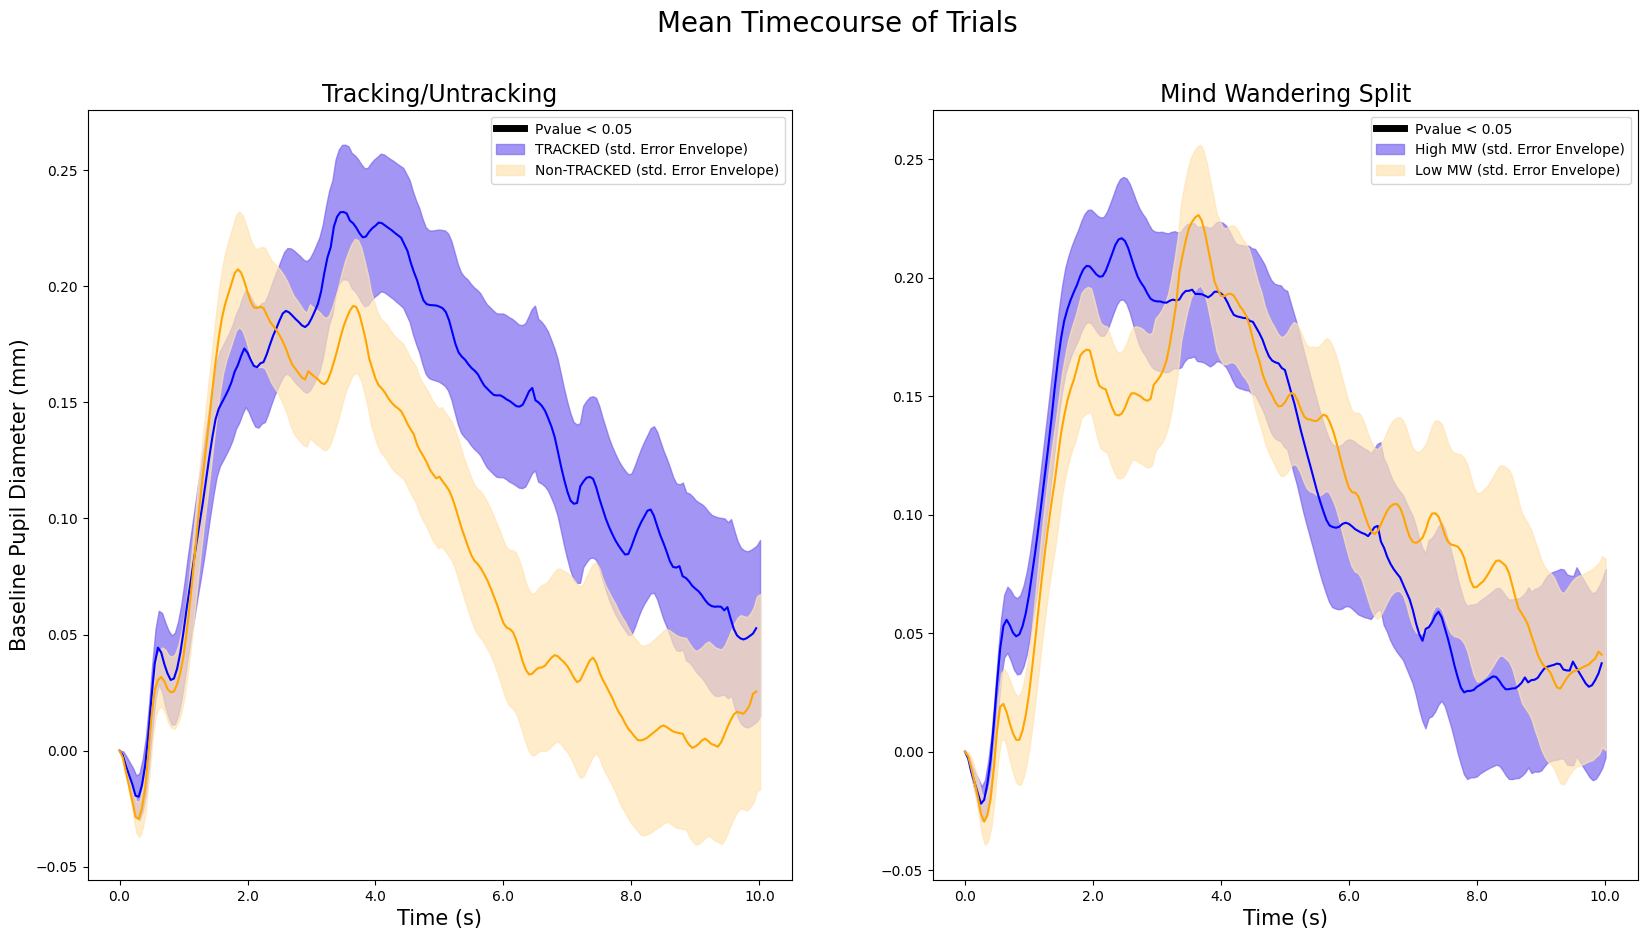

In [405]:
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(20,10))
delimet = 10000



pvalsTr = np.array(multipletests(list(pvalsTR.values())[1:], method='fdr_bh')[1]) # Already Corrected for Multiple Comparisons
pvalsTr[pvalsTr>0.05] = np.nan
pvalsTr[pvalsTr<=0.05] = 1

pvalsMw = np.array(multipletests(list(pvalsMW.values())[1:], method='fdr_bh')[1])
pvalsMw[pvalsMw>0.05] = np.nan
pvalsMw[pvalsMw<=0.05] = 1


fig.suptitle("Mean Timecourse of Trials",fontsize=20)
maxPos = np.max(pd.concat((trackedAggr['LeftPupil']['mean'] ,untrackedAggr['LeftPupil']['mean'])));
ax[0].plot(list(pvalsMW.keys())[1:],(maxPos+ 0.2*abs(maxPos))*pvalsTr,'k',label='Pvalue < 0.05', linewidth=5)

ax[0].set_title("Tracking/Untracking",fontsize=17)
ax[0].plot(trackedAggr['LeftPupil']['mean'].iloc[::5],color='blue')
ax[0].plot(untrackedAggr['LeftPupil']['mean'].iloc[::5],color='orange' )

ax[0].fill_between(np.linspace(1,int(delimet/10)+1,int(delimet/50)), 
                    trackedAggr['LeftPupil']['mean'].iloc[::5] -  trackedAggr['LeftPupil']['sem'].iloc[::5] , 
                    trackedAggr['LeftPupil']['mean'].iloc[::5]  +  trackedAggr['LeftPupil']['sem'].iloc[::5] , 
                    color='mediumslateblue', alpha=0.7, label='TRACKED (std. Error Envelope)') # make an STD Shade 


ax[0].fill_between(np.linspace(1,int(delimet/10)+1,int(delimet/50)), 
                    untrackedAggr['LeftPupil']['mean'].iloc[::5]  -  untrackedAggr['LeftPupil']['sem'].iloc[::5] , 
                    untrackedAggr['LeftPupil']['mean'].iloc[::5]   +  untrackedAggr['LeftPupil']['sem'].iloc[::5] , 
                    color='moccasin', alpha=0.7, label='Non-TRACKED (std. Error Envelope)') # make an STD Shade 

ax[0].legend()
ax[0].set_xticklabels(ax[0].get_xticks()/100) 
ax[0].set_xlabel("Time (s)",fontsize=15)
ax[0].set_ylabel("Baseline Pupil Diameter (mm)",fontsize=15)

maxPos = np.max(pd.concat((focusAggr['LeftPupil']['mean'] ,mwAggr['LeftPupil']['mean'])));
ax[1].plot(list(pvalsMW.keys())[1:],(maxPos+ 0.2*abs(maxPos))*pvalsMw,'k',label='Pvalue < 0.05', linewidth=5)

ax[1].set_title("Mind Wandering Split",fontsize=17)
ax[1].plot(mwAggr['LeftPupil']['mean'].iloc[::5],color='blue' )
ax[1].plot(focusAggr['LeftPupil']['mean'].iloc[::5],color='orange' )

ax[1].fill_between(np.linspace(1,int(delimet/10)+1,int(delimet/50)), 
                    mwAggr['LeftPupil']['mean'].iloc[::5]   -  mwAggr['LeftPupil']['sem'].iloc[::5], 
                    mwAggr['LeftPupil']['mean'].iloc[::5]   +  mwAggr['LeftPupil']['sem'].iloc[::5] , 
                    color='mediumslateblue', alpha=0.7, label='High MW (std. Error Envelope)') # make an STD Shade 
ax[1].fill_between(np.linspace(1,int(delimet/10)+1,int(delimet/50)), 
                    focusAggr['LeftPupil']['mean'].iloc[::5]   -  focusAggr['LeftPupil']['sem'].iloc[::5], 
                    focusAggr['LeftPupil']['mean'].iloc[::5]   +  focusAggr['LeftPupil']['sem'].iloc[::5] , 
                    color='moccasin', alpha=0.7, label='Low MW (std. Error Envelope)') # make an STD Shade 
ax[1].set_xticklabels(ax[0].get_xticks()/100) 
ax[1].set_xlabel("Time (s)",fontsize=15)
ax[1].legend()
plt.savefig(os.path.join(statPath,f"MeanPupilEnvelope_FirstTimeBase.png"))



#### Pupil Dynamics for All Trial

In [406]:
# import os, warnings, numpy as np
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from statsmodels.tools.sm_exceptions import ConvergenceWarning
# warnings.simplefilter("ignore", ConvergenceWarning)
# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# os.environ.setdefault("OMP_NUM_THREADS", "1")
# os.environ.setdefault("MKL_NUM_THREADS", "1")
# delimet = 40000
# # 1) Build the iteration list from UNIQUE Inds, then decimate to every 5th
# all_inds = np.sort(mergesTrue['Ind'].dropna().unique())
# indices_to_fit = [int(i) for i in all_inds if (i % 5 == 0) and (0 <= i < delimet)]

# print(f"Unique Inds total: {len(all_inds)}")
# print(f"Sampling every 5th Ind in [0,{delimet}) → {len(indices_to_fit)} iters (expected ≈ {delimet//5})")

# # 2) Work on a decimated table for speed (keeps only rows with Ind multiple of 5)
# merges_dec = mergesTrue[mergesTrue["Ind"] % 5 == 0].copy()

# # 3) Worker (uses merges_dec; one fit per unique Ind)
# def _one_fit(i):
#     try:
#         import statsmodels.formula.api as smf
#         cur = merges_dec.loc[merges_dec['Ind'] == i]
#         cur = cur[cur['LeftPupil'].notna()]
#         if cur.empty:
#             return i, np.nan, np.nan
#         m1 = smf.mixedlm("LeftPupil ~ Tracking + trialNum", data=cur, groups="DS").fit(method="lbfgs", disp=0)
#         m2 = smf.mixedlm("LeftPupil ~ MW_binarised + trialNum", data=cur, groups="DS").fit(method="lbfgs", disp=0)

#         return i, m1.pvalues.get('Tracking[T.UNTRACKED]', np.nan), m1.tvalues.get('Tracking[T.UNTRACKED]', np.nan),m1.bse_fe['Tracking[T.UNTRACKED]'],m2.pvalues.get('MW_binarised[T.True]', np.nan), m2.tvalues.get('MW_binarised[T.True]', np.nan),m2.bse_fe['MW_binarised[T.True]']
#     except Exception as e:
#         print(f"ERROR at i={i}: {e}")
#         return i, np.nan, np.nan

# # 4) Parallel run (threads avoid BrokenProcessPool)
# pvalsTR = {i: np.nan for i in indices_to_fit}
# tstatTR = {i: np.nan for i in indices_to_fit}
# stdErrrsTR = {i: np.nan for i in indices_to_fit}

# pvalsMW = {i: np.nan for i in indices_to_fit}
# tstatMW = {i: np.nan for i in indices_to_fit}
# stdErrrsMW = {i: np.nan for i in indices_to_fit}
# with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
#     futures = {ex.submit(_one_fit, i): i for i in indices_to_fit}
#     total = len(futures)
#     for done_count, fut in enumerate(as_completed(futures), 1):
#         i, pv, tv,stEr,pv2,tv2,stEr2 = fut.result()
#         pvalsTR[i] = pv
#         tstatTR[i] = tv
#         stdErrrsTR[i] = stEr
#         pvalsMW[i] = pv2
#         tstatMW[i] = tv2
#         stdErrrsMW[i] = stEr2
#         #print(f"Finished i={i} ({done_count}/{total})")



In [407]:
# trackedMean = merges[['Tracking','Ind','LeftPupil']].groupby(['Tracking','Ind']).agg(['mean','std','count']).loc['TRACKED']
# untrackedMean = merges[['Tracking','Ind','LeftPupil']].groupby(['Tracking','Ind']).agg(['mean','std','count']).loc['UNTRACKED']
# mwestimMean = merges[['MW_binarised','Ind','LeftPupil']].groupby(['MW_binarised','Ind']).agg(['mean','std','count']).loc[True]
# mwestimLowMean = merges[['MW_binarised','Ind','LeftPupil']].groupby(['MW_binarised','Ind']).agg(['mean','std','count']).loc[False]


In [408]:
# from statsmodels.stats.multitest import multipletests

# fig,ax = plt.subplots(1,2,figsize=(20,10))

# pvals_corrected = multipletests(list(pvalsMW.values()), method='fdr_bh')[1]

# pvalsTr = np.array(multipletests(list(pvalsTR.values()), method='fdr_bh')[1]) # Already Corrected for Multiple Comparisons
# pvalsTr[pvalsTr>0.05] = np.nan
# pvalsTr[pvalsTr<=0.05] = 1

# pvalsMw = np.array(multipletests(list(pvalsMW.values()), method='fdr_bh')[1])
# pvalsMw[pvalsMw>0.05] = np.nan
# pvalsMw[pvalsMw<=0.05] = 1
# fig.suptitle("Mean Timecourse of Trials",fontsize=20)
# maxPos = np.max(pd.concat((trackedMean['LeftPupil']['mean'] ,untrackedMean['LeftPupil']['mean'])));
# ax[0].plot(list(pvalsMW.keys()),(maxPos+ 0.2*abs(maxPos))*pvalsTr,'k',label='Pvalue < 0.05', linewidth=5)
# ax[0].set_title("Tracking/Untracking",fontsize=17)
# ax[0].plot(trackedMean['LeftPupil']['mean'].iloc[::5],color='blue')
# ax[0].plot(untrackedMean['LeftPupil']['mean'].iloc[::5],color='orange' )

# ax[0].fill_between(np.linspace(1,int(delimet/10),int(delimet/50)), 
#                     trackedMean['LeftPupil']['mean'].iloc[::5] - list(stdErrrsTR.values()) , 
#                     trackedMean['LeftPupil']['mean'].iloc[::5]  +   list(stdErrrsTR.values()) , 
#                     color='mediumslateblue', alpha=0.7, label='TRACKED (std. Error Envelope)') # make an STD Shade 

# ax[0].fill_between(np.linspace(1,int(delimet/10),int(delimet/50)), 
#                     untrackedMean['LeftPupil']['mean'].iloc[::5]  - list(stdErrrsTR.values()) , 
#                     untrackedMean['LeftPupil']['mean'].iloc[::5]  +  list(stdErrrsTR.values()), 
#                     color='moccasin', alpha=0.7, label='TRACKED (std. Error Envelope)') # make an STD Shade 

# ax[0].legend()
# ax[0].set_xticklabels(ax[0].get_xticks()/100) 
# ax[0].set_xlabel("Time (s)",fontsize=15)
# ax[0].set_ylabel("Baseline Pupil Diameter (mm)",fontsize=15)

# maxPos = np.max(pd.concat((mwestimMean['LeftPupil']['mean'] ,mwestimLowMean['LeftPupil']['mean'])));
# ax[1].plot(list(pvalsMW.keys()),(maxPos+ 0.2*abs(maxPos))*pvalsMw,'k',label='Pvalue < 0.05', linewidth=5)
# ax[1].set_title("Mind Wandering Split",fontsize=17)
# ax[1].plot(mwestimMean['LeftPupil']['mean'].iloc[::5],color='blue' )
# ax[1].plot(mwestimLowMean['LeftPupil']['mean'].iloc[::5],color='orange' )

# ax[1].fill_between(np.linspace(1,int(delimet/10),int(delimet/50)), 
#                     mwestimMean['LeftPupil']['mean'].iloc[::5]   -   list(stdErrrsMW.values()) , 
#                     mwestimMean['LeftPupil']['mean'].iloc[::5]   +   list(stdErrrsMW.values())  , 
#                     color='mediumslateblue', alpha=0.7, label='High MW (std. Error Envelope)') # make an STD Shade 
# ax[1].fill_between(np.linspace(1,int(delimet/10),int(delimet/50)), 
#                     mwestimLowMean['LeftPupil']['mean'].iloc[::5]   -   list(stdErrrsMW.values()) , 
#                     mwestimLowMean['LeftPupil']['mean'].iloc[::5]   +  list(stdErrrsMW.values()) , 
#                     color='moccasin', alpha=0.7, label='Low MW (std. Error Envelope)') # make an STD Shade 
# ax[1].set_xticklabels(ax[0].get_xticks()/100) 
# ax[1].set_xlabel("Time (s)",fontsize=15)
# ax[1].legend()
# plt.savefig(os.path.join(statPath,f"MeanPupilEnvelope.png"))



## (1) GENERAL: Test Is Tracked Entity Different from Untracked Entity?

### (1.1) Test Whether Pupil Diameter Differs between Tracked and Untracked Entity: 

We controll immediatley for SUBJECTS

so Making Basic Models:

        MW_estimate ~ Tracking +trialNum + (1|Subjects)


Additionally we plot the Envelope of STD from subjects as well as provide the Mean differs across subjects of MW Both in TIme as in Absolute:

Important here to check:
+ Whether there is a difference between Tracked and Untracked Entity
+ Whether there is an Effect of Trial Number (As MW Rate should increase in time)

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    1154      Method:               REML       
No. Groups:          29        Scale:                0.9141     
Min. group size:     37        Log-Likelihood:       -1593.8470 
Max. group size:     40        Converged:            Yes        
Mean group size:     39.8                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.479    0.064 -7.509 0.000 -0.604 -0.354
Tracking[T.UNTRACKED]  0.347    0.056  6.156 0.000  0.236  0.457
trialNum               0.015    0.002  6.011 0.000  0.010  0.019
DS Var                 0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


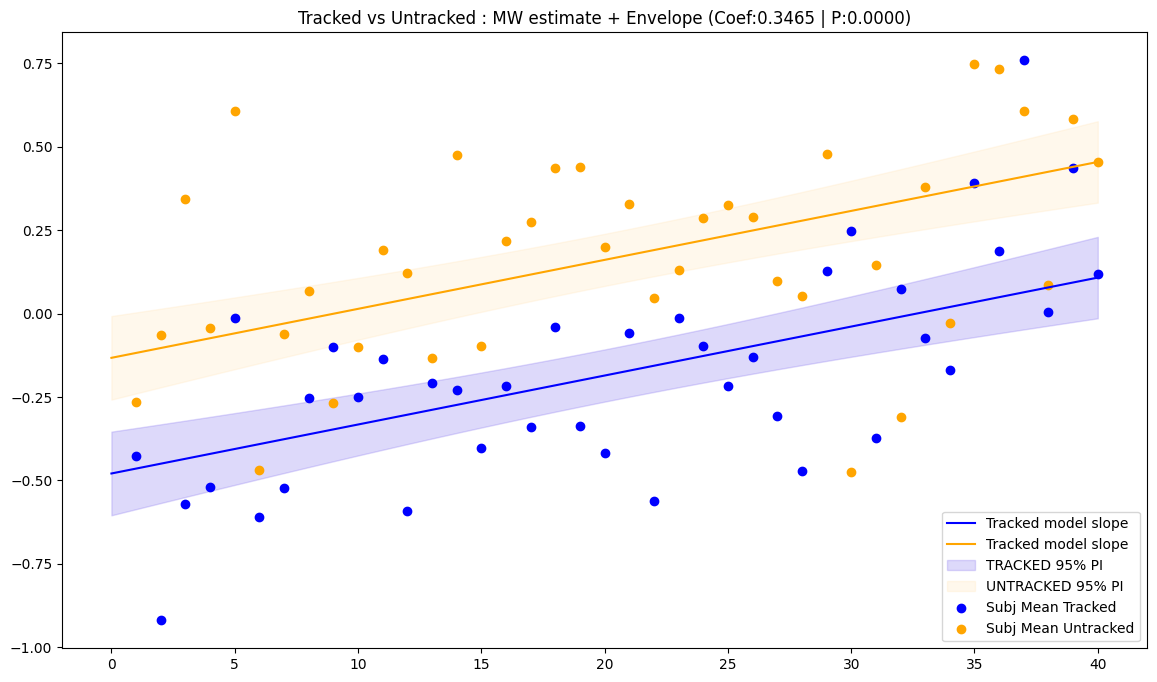

In [409]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt

from analysisFunctions import plotTrialTrack

### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

m = smf.mixedlm("MW_Estimate ~ Tracking+trialNum ", data=grand_df[['DS','trialNum','Tracking','MW_Estimate']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate")
eye.append('')
analysis.append('')

log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_{est}_{exclusionName}.png"))



#### Checks

**Chek the assumptions of linear models**
+ Homoscedasticity
+ Normality of residuals
+ vfs

In [410]:

def linearModelChecks(m,grand_df,formula =  "MW_Estimate ~ Tracking + trialNum"):
    # trial-level diagnostics
    resid   = m.resid                   # raw (conditional) residuals
    fitted  = m.fittedvalues            # conditional fitted values
    std_res = resid / np.sqrt(m.scale)  # ≈ studentised residuals
    fig,axs = plt.subplots(2,1,figsize=(14, 8))
    plt.suptitle("Checks for a Linear Model")

    # (1) Homoscedascisity
    axs[0].scatter(fitted, std_res, alpha=0.6, s=15,color='blue')
    axs[0].axhline(0, linestyle='--',color='orange')
    axs[0].set_xlabel("Fitted value")
    axs[0].set_ylabel("Studentised residual")
    axs[0].set_title("Residuals vs fitted")

    # (2) 
    sm.qqplot(std_res, line="45", fit=True, ax=axs[1])
    axs[1].set_title("Normal Q–Q")

    # (3) Colinearity:
    from patsy import dmatrices

    formula_fixed = formula  # your fixed part
    y, X = dmatrices(formula_fixed, data=grand_df, return_type="dataframe")
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )
    print(vif)

     # Drop the intercept from display (its VIF is usually not meaningful)
    vif_display = vif.drop('Intercept', errors='ignore')
    
    # Convert to multiline string
    vif_text = "\n".join([f"{k}: {v:.2f}" for k, v in vif_display.items()])
    vif_text = f"VIFs\n{vif_text}"

    axs[1].text(
        0.8, 0.5, vif_text,
        transform=axs[1].transAxes,
        verticalalignment='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )


Intercept                5.136933
Tracking[T.UNTRACKED]    1.000000
trialNum                 1.000000
dtype: float64


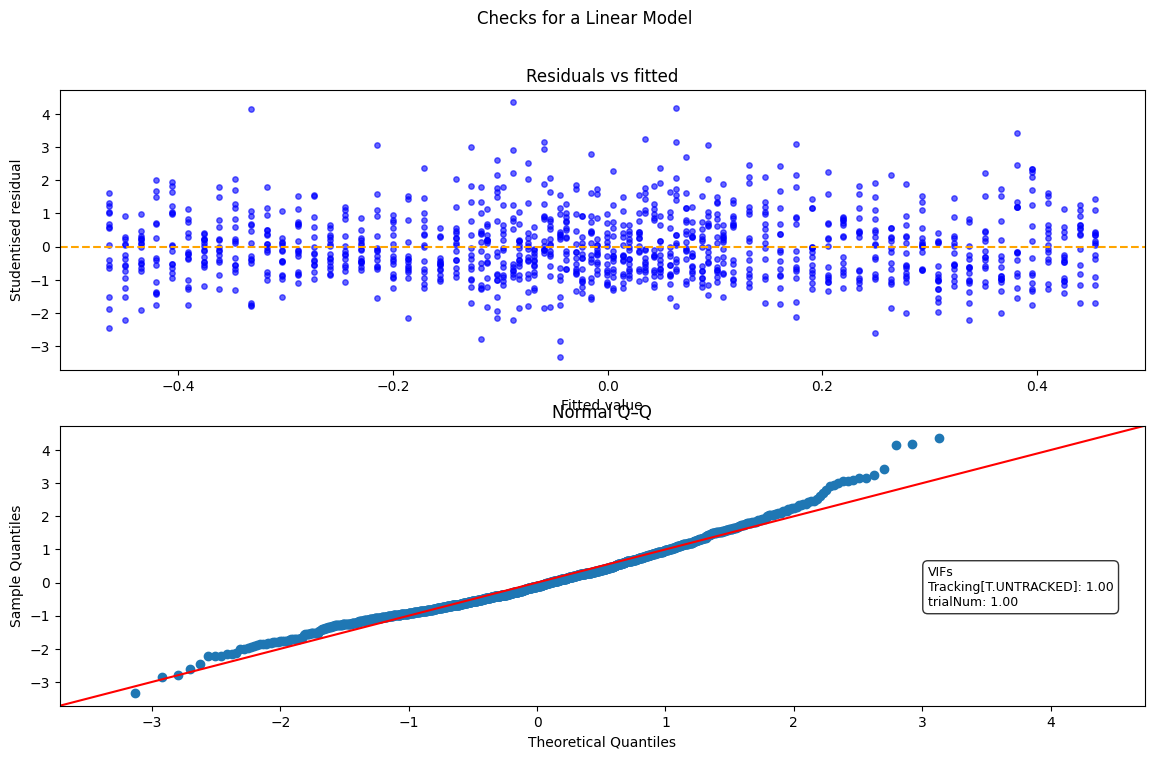

In [411]:
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df)
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_Checks_{est}_{exclusionName}.png"))

**Check the Mean of  MW estimated for every Particiapnt**

The purpose is to plot whether by means alone we cane see the relationship

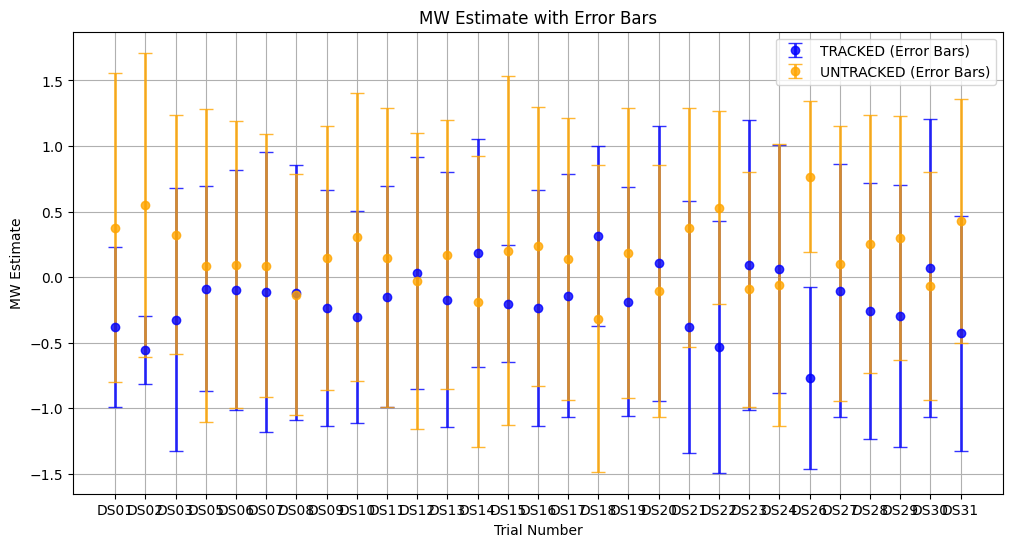

In [412]:
mew = grand_df[grand_df['Tracking'] == 'TRACKED'][['DS','MW_Estimate']].groupby(['DS'])
umew = grand_df[grand_df['Tracking'] == 'UNTRACKED'][['DS','MW_Estimate']].groupby(['DS'])


plt.figure(figsize=(12, 6))

# Plot for TRACKED group
plt.errorbar(mew.mean().index, 
             mew.mean()['MW_Estimate'].values, 
             yerr=mew.std()['MW_Estimate'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(umew.mean().index, 
             umew.mean()['MW_Estimate'].values, 
             yerr=umew.std()['MW_Estimate'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('MW Estimate')
plt.title('MW Estimate with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"MWacrossSubj_Unc_{est}_{exclusionName}.png"))


### (1.2) Test Whether Pupil Diameter Differs between Tracked and Untracked Entity: 

We controll immediatley for SUBJECTS

so Making Basic Models:

        Pupil ~ Tracking +trialNum + (1|Subjects)

Each Pupil Measurment is a tad bit different: We are using:
+ Pupil Std
+ Pupil Mean Diameter
+ Pupil Differentiate Series



======== Test for Pupil Diameter Mean // Left_Eye =======

             Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    Pupil  
No. Observations:      1150       Method:                REML   
No. Groups:            29         Scale:                 0.0461 
Min. group size:       37         Log-Likelihood:        97.8116
Max. group size:       40         Converged:             Yes    
Mean group size:       39.7                                     
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.133    0.021 -6.283 0.000 -0.175 -0.092
Tracking[T.UNTRACKED] -0.007    0.013 -0.585 0.558 -0.032  0.017
trialNum               0.001    0.001  1.382 0.167 -0.000  0.002
DS Var                 0.007    0.010                           



======== Test for Pupil Diameter Mean //

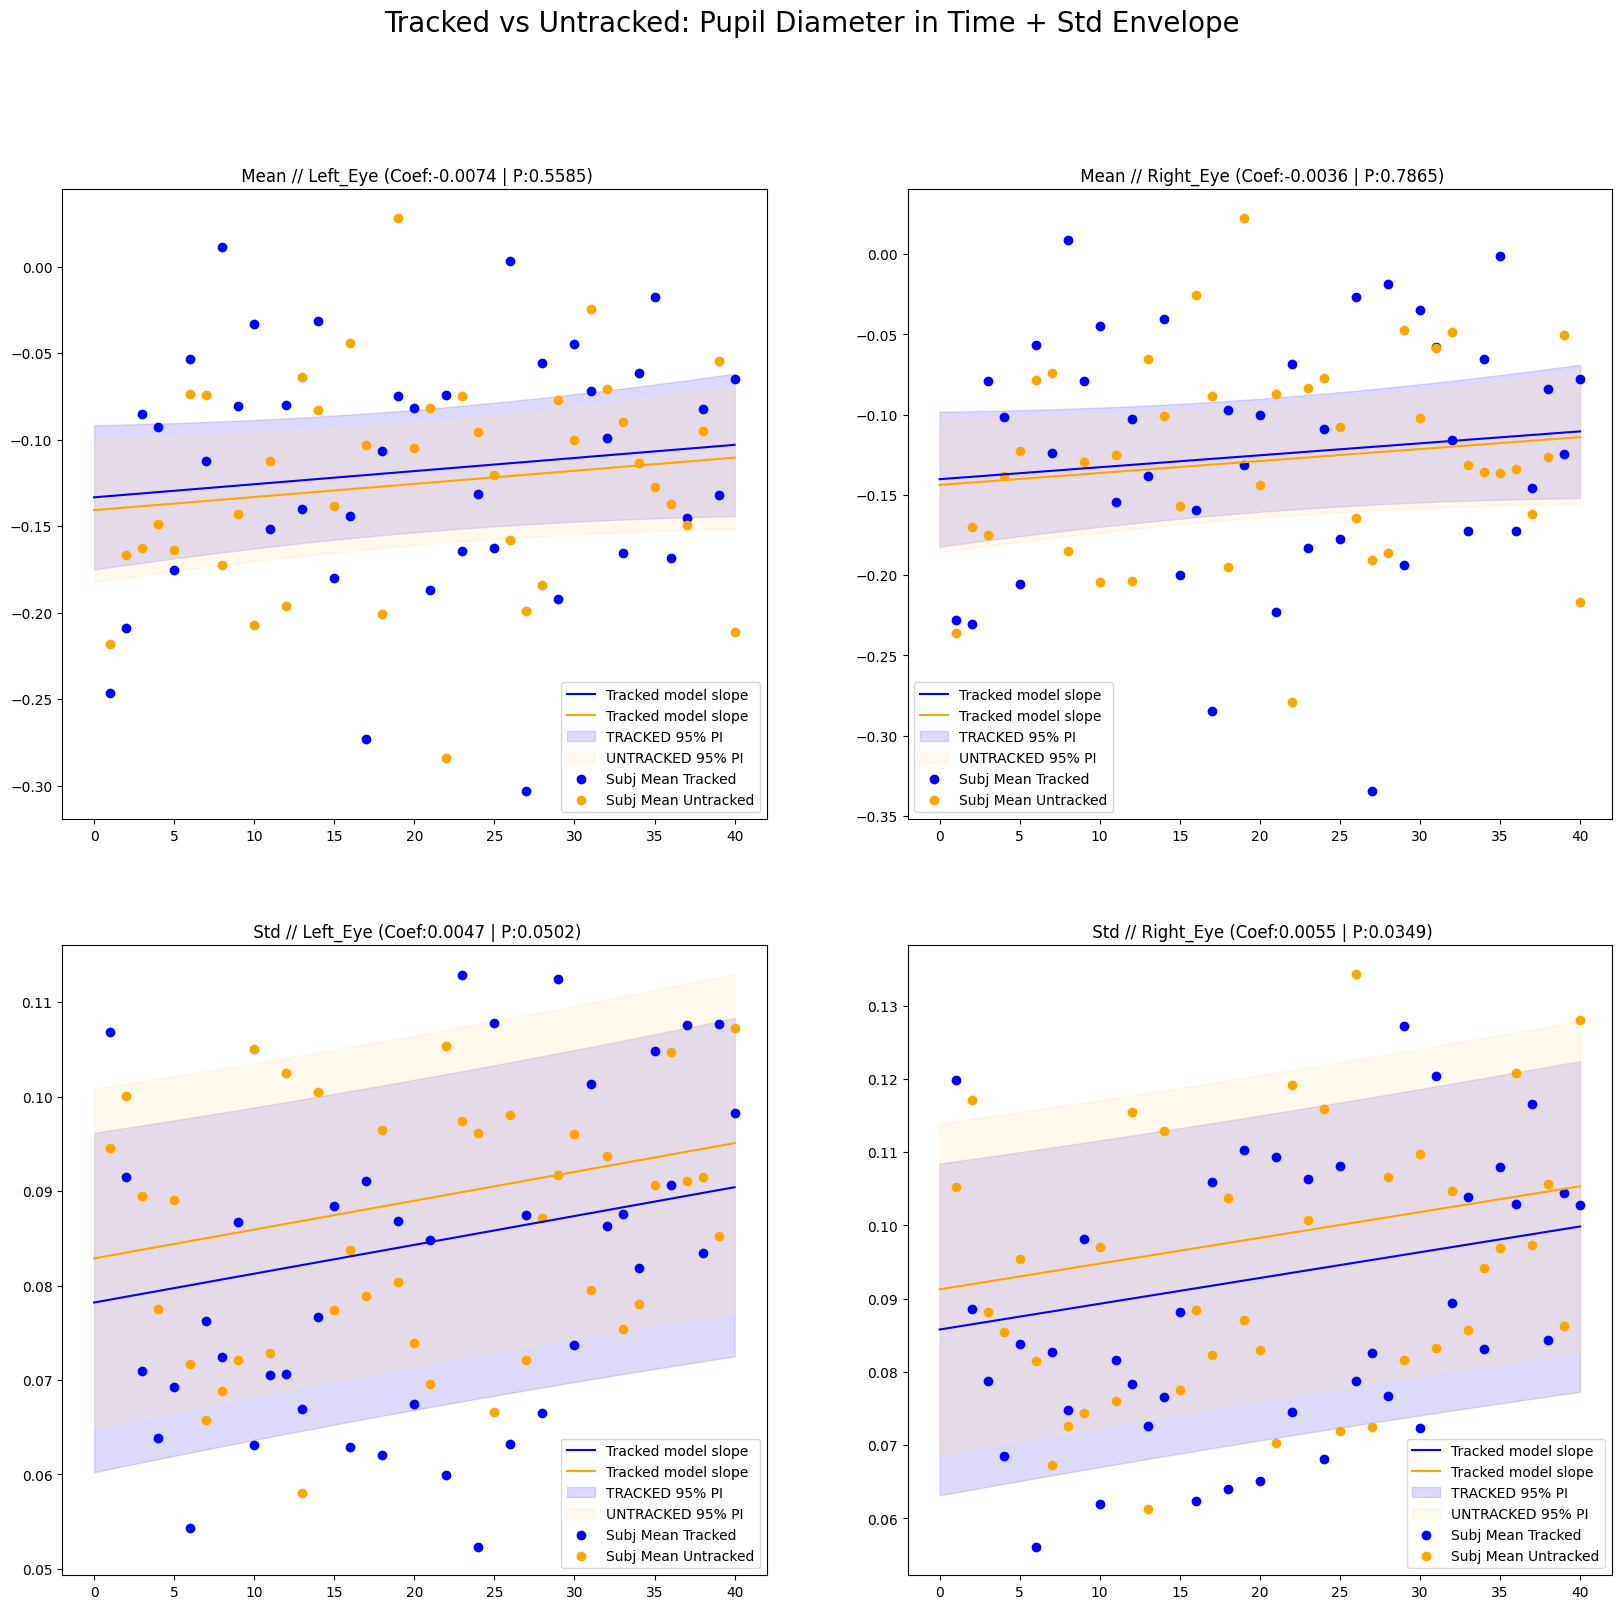

In [413]:
import statsmodels.formula.api as smf
models = []

fig, axes = plt.subplots(2,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.2) Pupil Diameter vs Tracking (Pupil ~ Tracking +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Pupil_Diameter'].columns):

    if i > 3:
        continue
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Pupil_Diameter'][ind[0]][ind[1]], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Pupil', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Pupil', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Pupil'] = pd.to_numeric(currentDf['Pupil'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Pupil'] - currentDf['Pupil'].mean() <3*currentDf['Pupil'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Pupil ~ Tracking +trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])
    indx.append("Pupil Diam")
    eye.append(ind[0])
    analysis.append(ind[1])

    plotTrialTrack(m,"Pupil",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"PupilvsTracking_Unc_{est}_{exclusionName}.png"))


#### (1.3) Test Whether Pupil Diameter and MW Estimates ARE Tracking Each other 

We controll immediatley for SUBJECTS

so Making Basic Models:

        Pupil ~ MW_Estimate +trialNum + (1|Subjects)




======== Test MW vs Pupil Diameter Mean // Left_Eye =======

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Pupil   
No. Observations: 1150    Method:             REML    
No. Groups:       29      Scale:              0.0461  
Min. group size:  37      Log-Likelihood:     102.6278
Max. group size:  40      Converged:          Yes     
Mean group size:  39.7                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept   -0.122    0.017 -7.200 0.000 -0.155 -0.088
MW_Estimate -0.002    0.006 -0.243 0.808 -0.014  0.011
DS Var       0.007    0.010                           



======== Test MW vs Pupil Diameter Mean // Right_Eye =======

        Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Pupil  
No. Observations:  1149    Method:             REML   
No. Groups

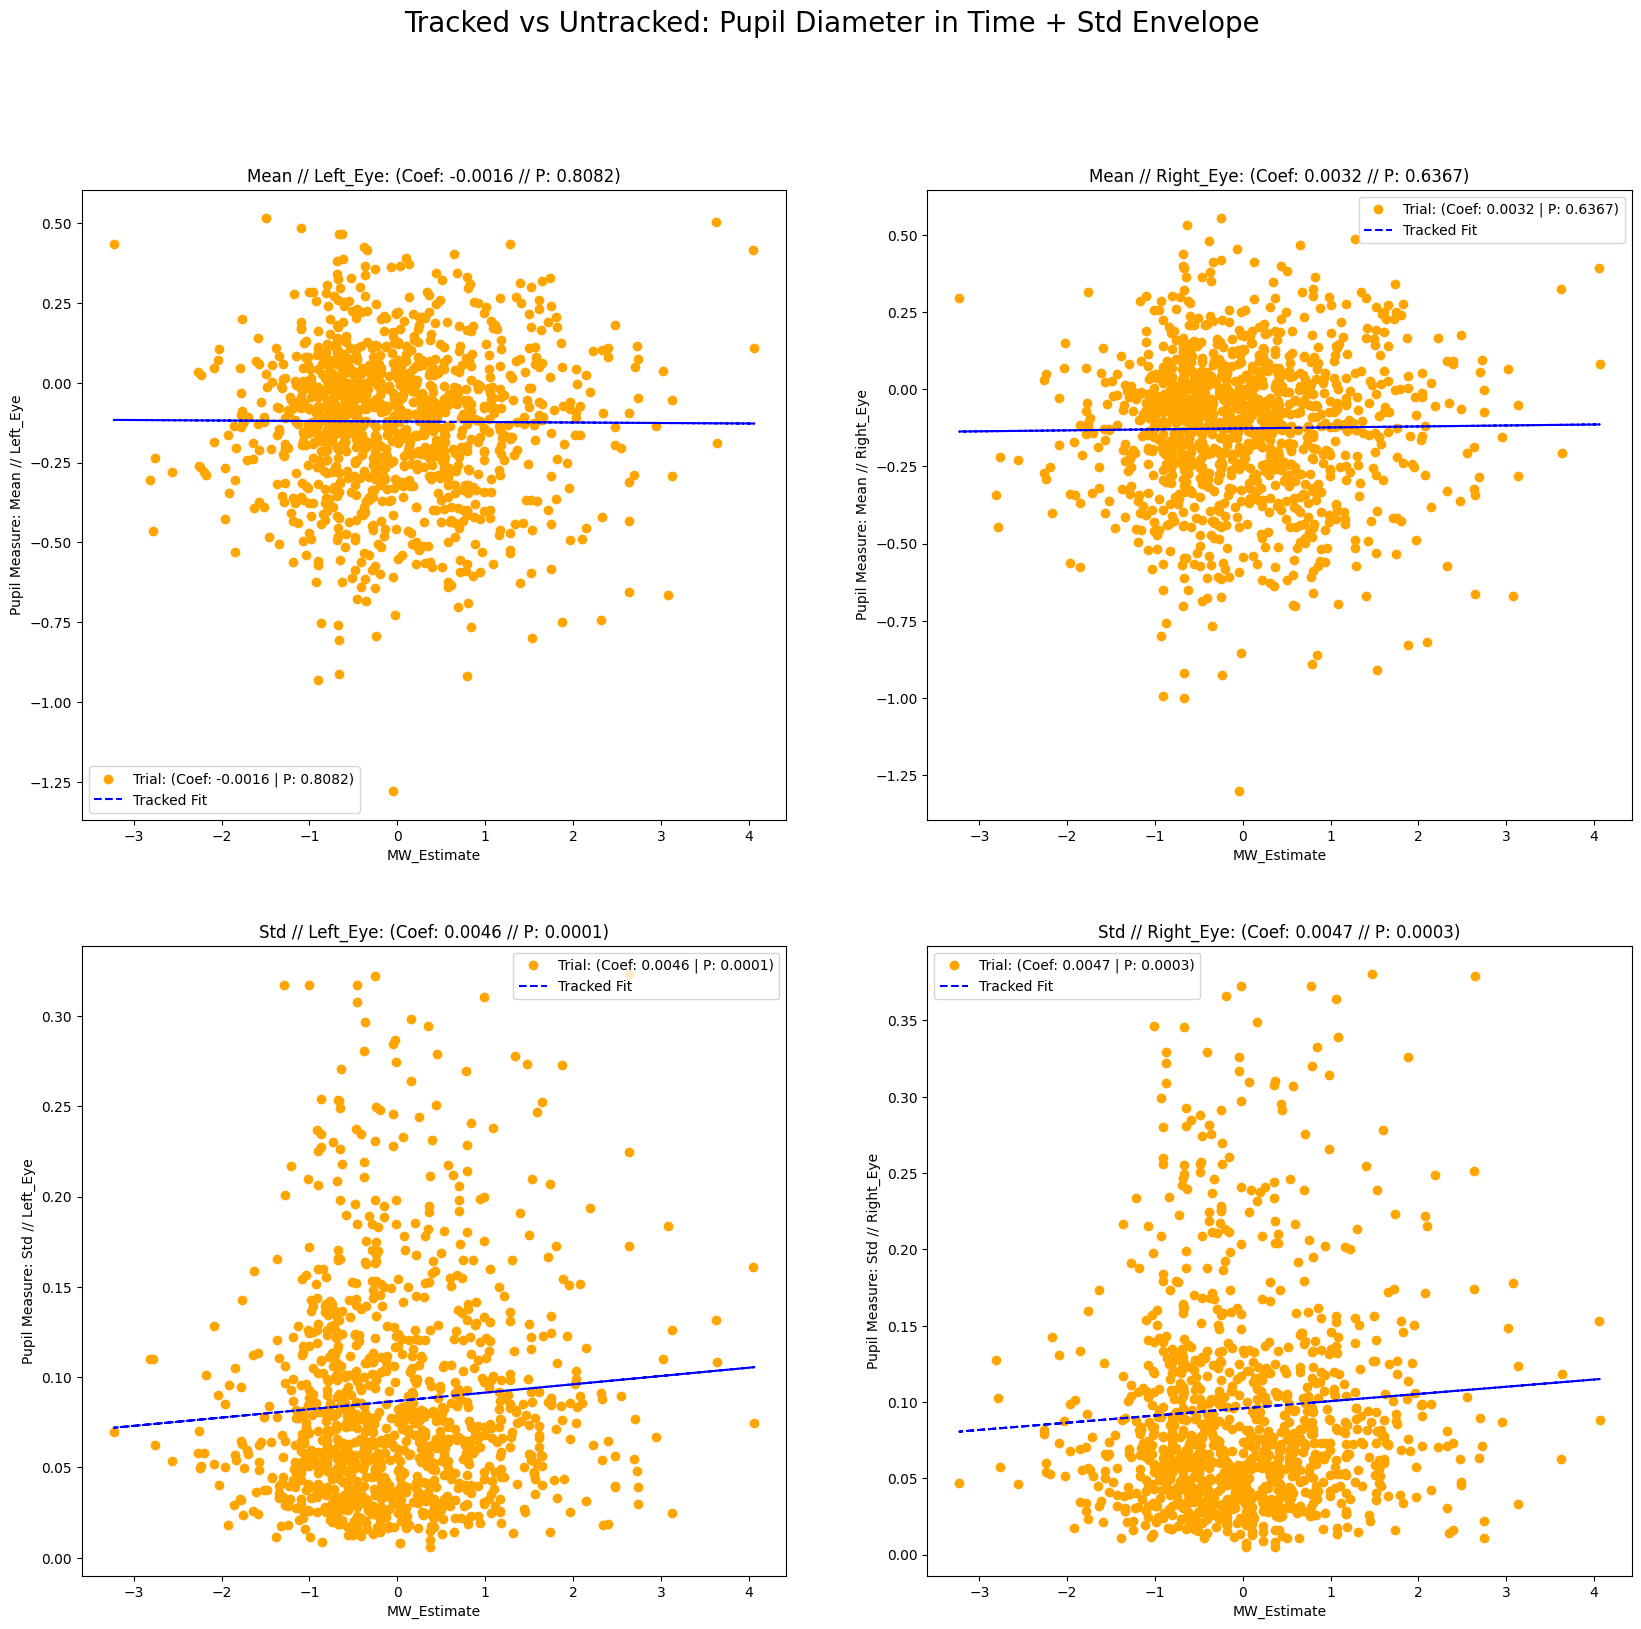

In [414]:
import statsmodels.formula.api as smf
models = []

import matplotlib.pyplot as plt
from analysisFunctions import plot_pupil_vs_mw
fig, axes = plt.subplots(2, 2, figsize=(20, 18))  # Adjust rows/columns as needed
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope", fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
currentModels =[];

log_file.write("\n(1.3) Pupil Diameter vs MW (Pupil ~ MW +Tracking +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Pupil_Diameter'].columns):
   


    if i > 3:
        continue

    print("\n\n=============================================================")
    print(f"======== Test MW vs Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")
    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Pupil_Diameter'][ind[0]][ind[1]], grand_df['MW_Estimate'], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Pupil','MW_Estimate', 'DS', 'trialNum', 'Tracking']

    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this
    # Clean the data
    currentDf = currentDf.dropna(subset=['Pupil','MW_Estimate', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Pupil'] = pd.to_numeric(currentDf['Pupil'], errors='coerce')  # Ensure numeric
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Pupil'] - currentDf['Pupil'].mean() <3*currentDf['Pupil'].std()]
    # Fit the mixed effects model
    m = smf.mixedlm("Pupil ~ MW_Estimate   ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    currentModels.append(m)
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      MW Estimate Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")

    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Pupil x MW")
    eye.append(ind[0])
    analysis.append(ind[1])

    print(m.summary())  # ≈ summary(lm(...)) in R
    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],tracking=False,meas2=1)
plt.savefig(os.path.join(statPath,f"PupilvsMW_Unc_{est}_{exclusionName}.png"))

## (1.4) Left-Right Gaze Difference (TO DO )


- Aimed at computing the difference between the Eyes as an euclidean distance between them, while controlling for Tracking and Trial 
- To see whether the MW estimate can be predicted by the Eye Vergence: a
- And Whether the Eye Vergence is different between the Tracking and Untracking condition

              Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  GazeDifference
No. Observations:    1154     Method:              REML          
No. Groups:          29       Scale:               378.2607      
Min. group size:     37       Log-Likelihood:      -5123.6401    
Max. group size:     40       Converged:           Yes           
Mean group size:     39.8                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              58.609    5.404 10.846 0.000 48.018 69.200
Tracking[T.UNTRACKED]   0.486    1.145  0.425 0.671 -1.758  2.731
trialNum               -0.005    0.050 -0.104 0.917 -0.103  0.092
DS Var                797.922   11.234                           



c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


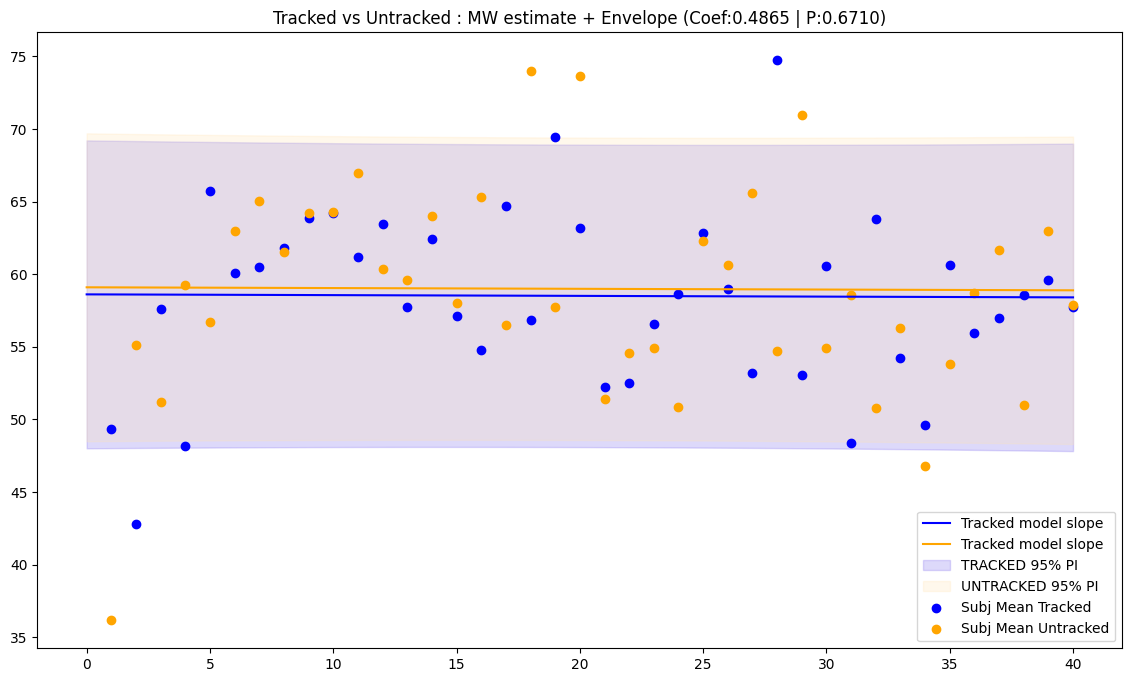

In [415]:
import statsmodels.formula.api as smf

m = smf.mixedlm("GazeDifference ~ Tracking +trialNum", data=grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()

log_file.write("(1.4.1) Uncorrected Samples (GazeDifference ~ Tracking  +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("Gaze Difference ")
eye.append('')
analysis.append('Tracking')

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'GazeDifference',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" ,paramNum = [0,1,2])
plt.savefig(os.path.join(statPath,f"GazeDiff_TrVsUntr_Unc_{est}_{exclusionName}.png"))



Intercept                5.136933
Tracking[T.UNTRACKED]    1.000000
trialNum                 1.000000
dtype: float64


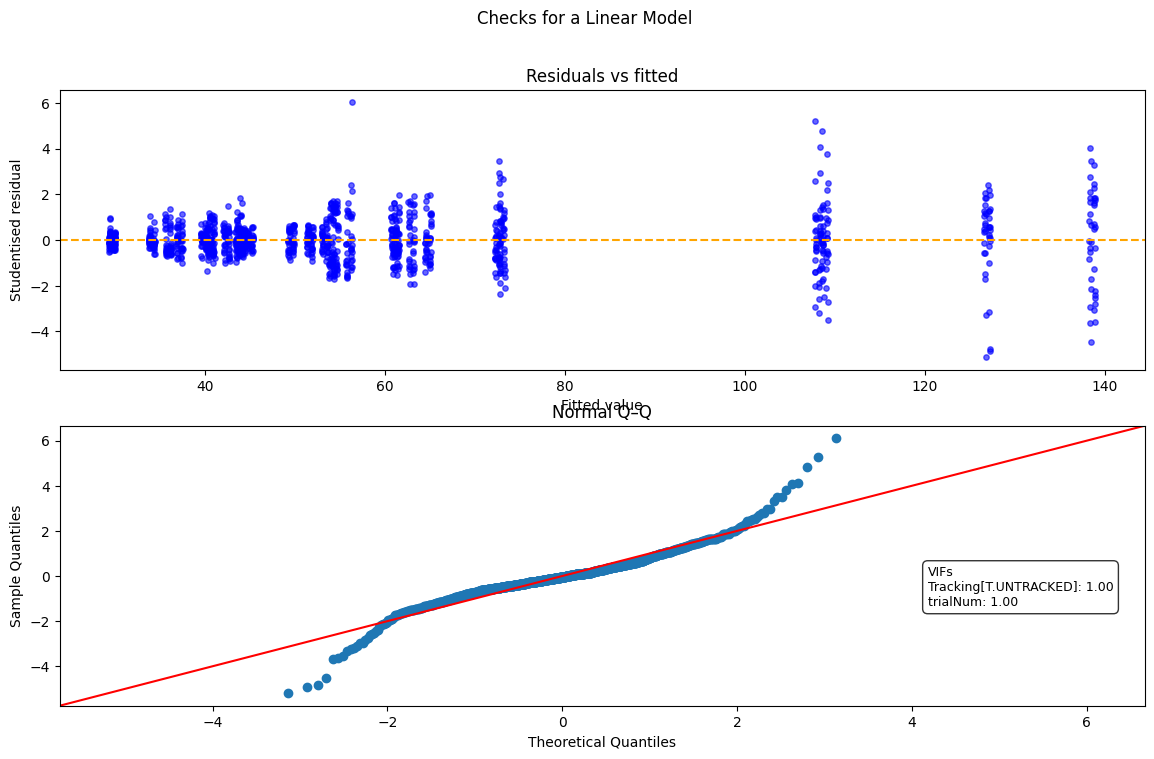

In [416]:
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df,formula="GazeDifference ~ Tracking +trialNum")
plt.savefig(os.path.join(statPath,f"GazeDiff_TrVsUntr_Unc_Check_{est}_{exclusionName}.png"))

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: GazeDifference
No. Observations: 1154    Method:             REML          
No. Groups:       29      Scale:              376.5725      
Min. group size:  37      Log-Likelihood:     -5120.2240    
Max. group size:  40      Converged:          Yes           
Mean group size:  39.8                                      
-------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept     58.754     5.277  11.133  0.000  48.411  69.097
MW_Estimate    1.192     0.580   2.054  0.040   0.055   2.328
DS Var       798.161    11.262                               



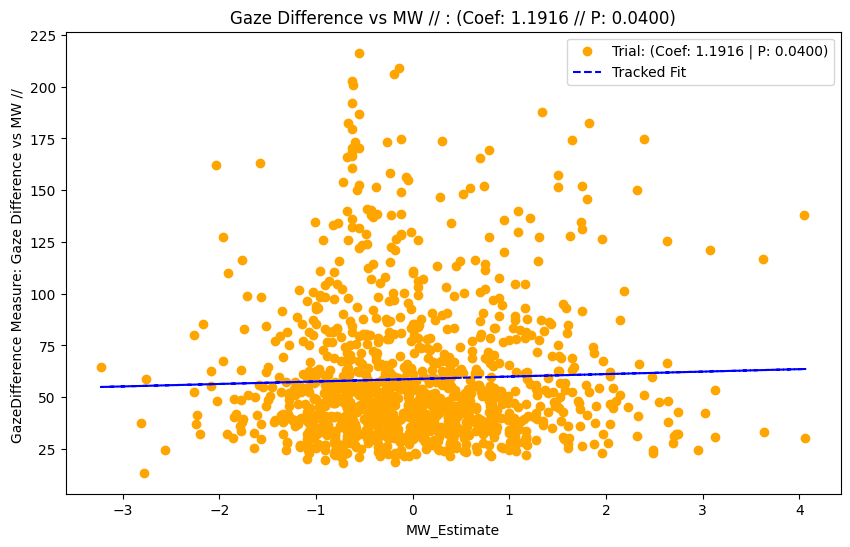

In [417]:
# Combine single-level and multi-level columns
subset = pd.concat([
    grand_df[('MW_Estimate', '', '')].rename('MW_Estimate'),

    grand_df[('Tracking', '', '')].rename('Tracking'),
    grand_df[('DS', '', '')].rename('DS'),
    grand_df[('trialNum', '', '')].rename('trialNum'),
    grand_df[('Checks', '', 'gazeDiff')].rename('gazeDiff')
], axis=1)



import statsmodels.formula.api as smf

m = smf.mixedlm(" GazeDifference~ MW_Estimate ", data=grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()

log_file.write("(1.4.2) Uncorrected Samples (MW_Estimate ~ GazeDifference+Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      MW_Estimate Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
# log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[3]]:3.3f}| Z: {m.tvalues[m.params.keys()[3]]:3.3f}| P: {m.pvalues[m.params.keys()[3]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[3]][0]:3.3f} {m.conf_int().loc[m.params.keys()[3]][1]:3.3f})\n")




print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("Gaze Difference ")
eye.append('')
analysis.append('MW_estimate')

plot_pupil_vs_mw(m, grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']], ["Gaze Difference vs MW",""], ax=None,meas='GazeDifference',meas1=1,meas2=1,target='MW_Estimate',tracking=False)
plt.savefig(os.path.join(statPath,f"MWvsGaze_Unc_{est}_{exclusionName}.png"))


Intercept      1.000039
MW_Estimate    1.000000
dtype: float64


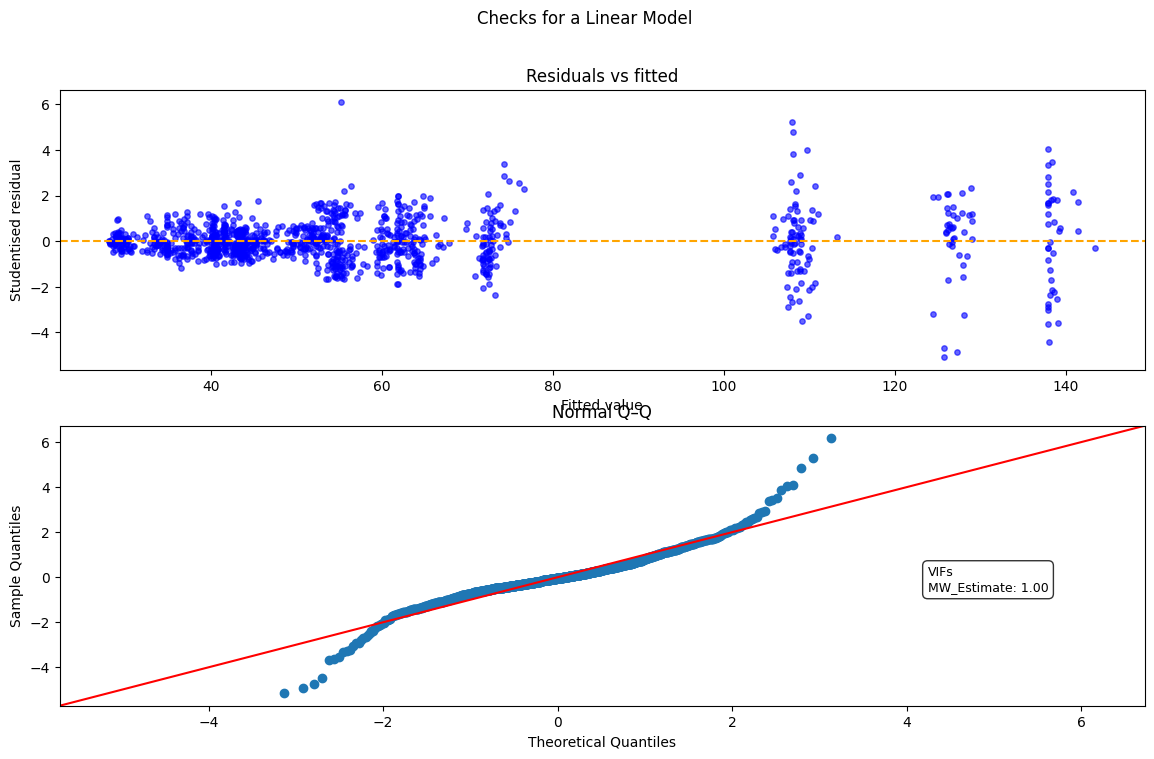

In [418]:
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df, formula="GazeDifference ~ MW_Estimate")
plt.savefig(os.path.join(statPath,f"MWvsGaze_Unc_Check_{est}_{exclusionName}.png"))

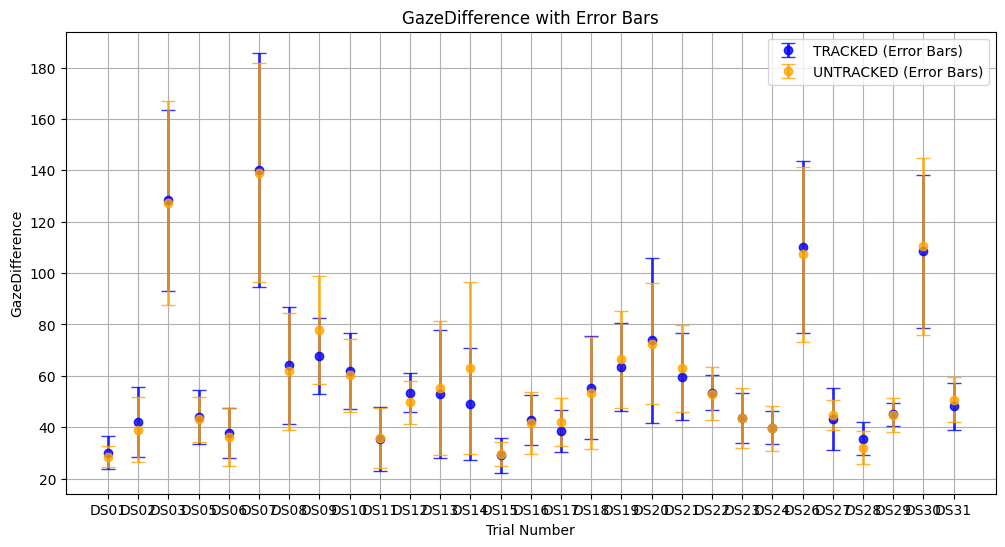

In [419]:
mew = grand_df[grand_df['Tracking'] == 'TRACKED'][['DS','GazeDifference']].groupby(['DS'])
umew = grand_df[grand_df['Tracking'] == 'UNTRACKED'][['DS','GazeDifference']].groupby(['DS'])


plt.figure(figsize=(12, 6))

# Plot for TRACKED group
plt.errorbar(mew.mean().index, 
             mew.mean()['GazeDifference'].values, 
             yerr=mew.std()['GazeDifference'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(umew.mean().index, 
             umew.mean()['GazeDifference'].values, 
             yerr=umew.std()['GazeDifference'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('GazeDifference')
plt.title('GazeDifference with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"GazeDiffacrossSubj__{est}_{exclusionName}.png"))

### 1.7.4 - Wariancja 

Quick check of Differences in Variance of Eye Movements in Tracked and Untracked periods of time 

this basically equivalent almost to using All data segments and computing PupilDiamterStd - but instead with Variance 

In [420]:
trs = [];
subs = [];
vars = [];
trackedUntracked = [];
for i in range(len(trials[1])): # SUbjects
    for j in range(0,40):    # Trials
        subs.append(i)
        trs.append(j)
        vars.append(np.nanvar(trials[j][i]['LeftPupil']));

        if (trials[j][i]['firstEnt'].iloc[0] =='TRACKED') and (j % 2 ==0):
            trackedUntracked.append('TRACKED')
        else:
            trackedUntracked.append('UNTRACKED')

varDf = pd.DataFrame({'DS':subs,'TrialNum':trs,'VarLeftPupil':vars,'Tracking':trackedUntracked})
varDf = varDf.reset_index(drop=True)
varDf = varDf.dropna(subset=["VarLeftPupil"])
m = smf.mixedlm("VarLeftPupil ~Tracking +TrialNum", data=varDf,
                    groups="DS",  # Random intercept
                    ).fit()

m.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM  Dependent Variable:  VarLeftPupil
No. Observations:   297      Method:              REML        
No. Groups:         25       Scale:               0.0028      
Min. group size:    1        Log-Likelihood:      404.1150    
Max. group size:    28       Converged:           Yes         
Mean group size:    11.9                                      
--------------------------------------------------------------
                      Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             0.091    0.016 5.720 0.000  0.060  0.122
Tracking[T.UNTRACKED] 0.003    0.009 0.322 0.748 -0.015  0.021
TrialNum              0.000    0.000 0.081 0.935 -0.001  0.001
DS Var                0.004    0.027                          
==============================================================

"""

### (1.8) Gaze Data Testing: 


Tests whether Gaze Patterns are Different across our subjects 



======== Test for Pupil Diameter mean // LeftX =======

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Gaze      
No. Observations:    1154       Method:                REML      
No. Groups:          29         Scale:                 367.2609  
Min. group size:     37         Log-Likelihood:        -5094.4869
Max. group size:     40         Converged:             Yes       
Mean group size:     39.8                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              15.390    3.557  4.327 0.000  8.419 22.361
Tracking[T.UNTRACKED]   0.803    1.128  0.712 0.477 -1.408  3.014
trialNum               -0.480    0.049 -9.814 0.000 -0.576 -0.384
DS Var                319.450    4.642                           



======== Test for Pupil Diame

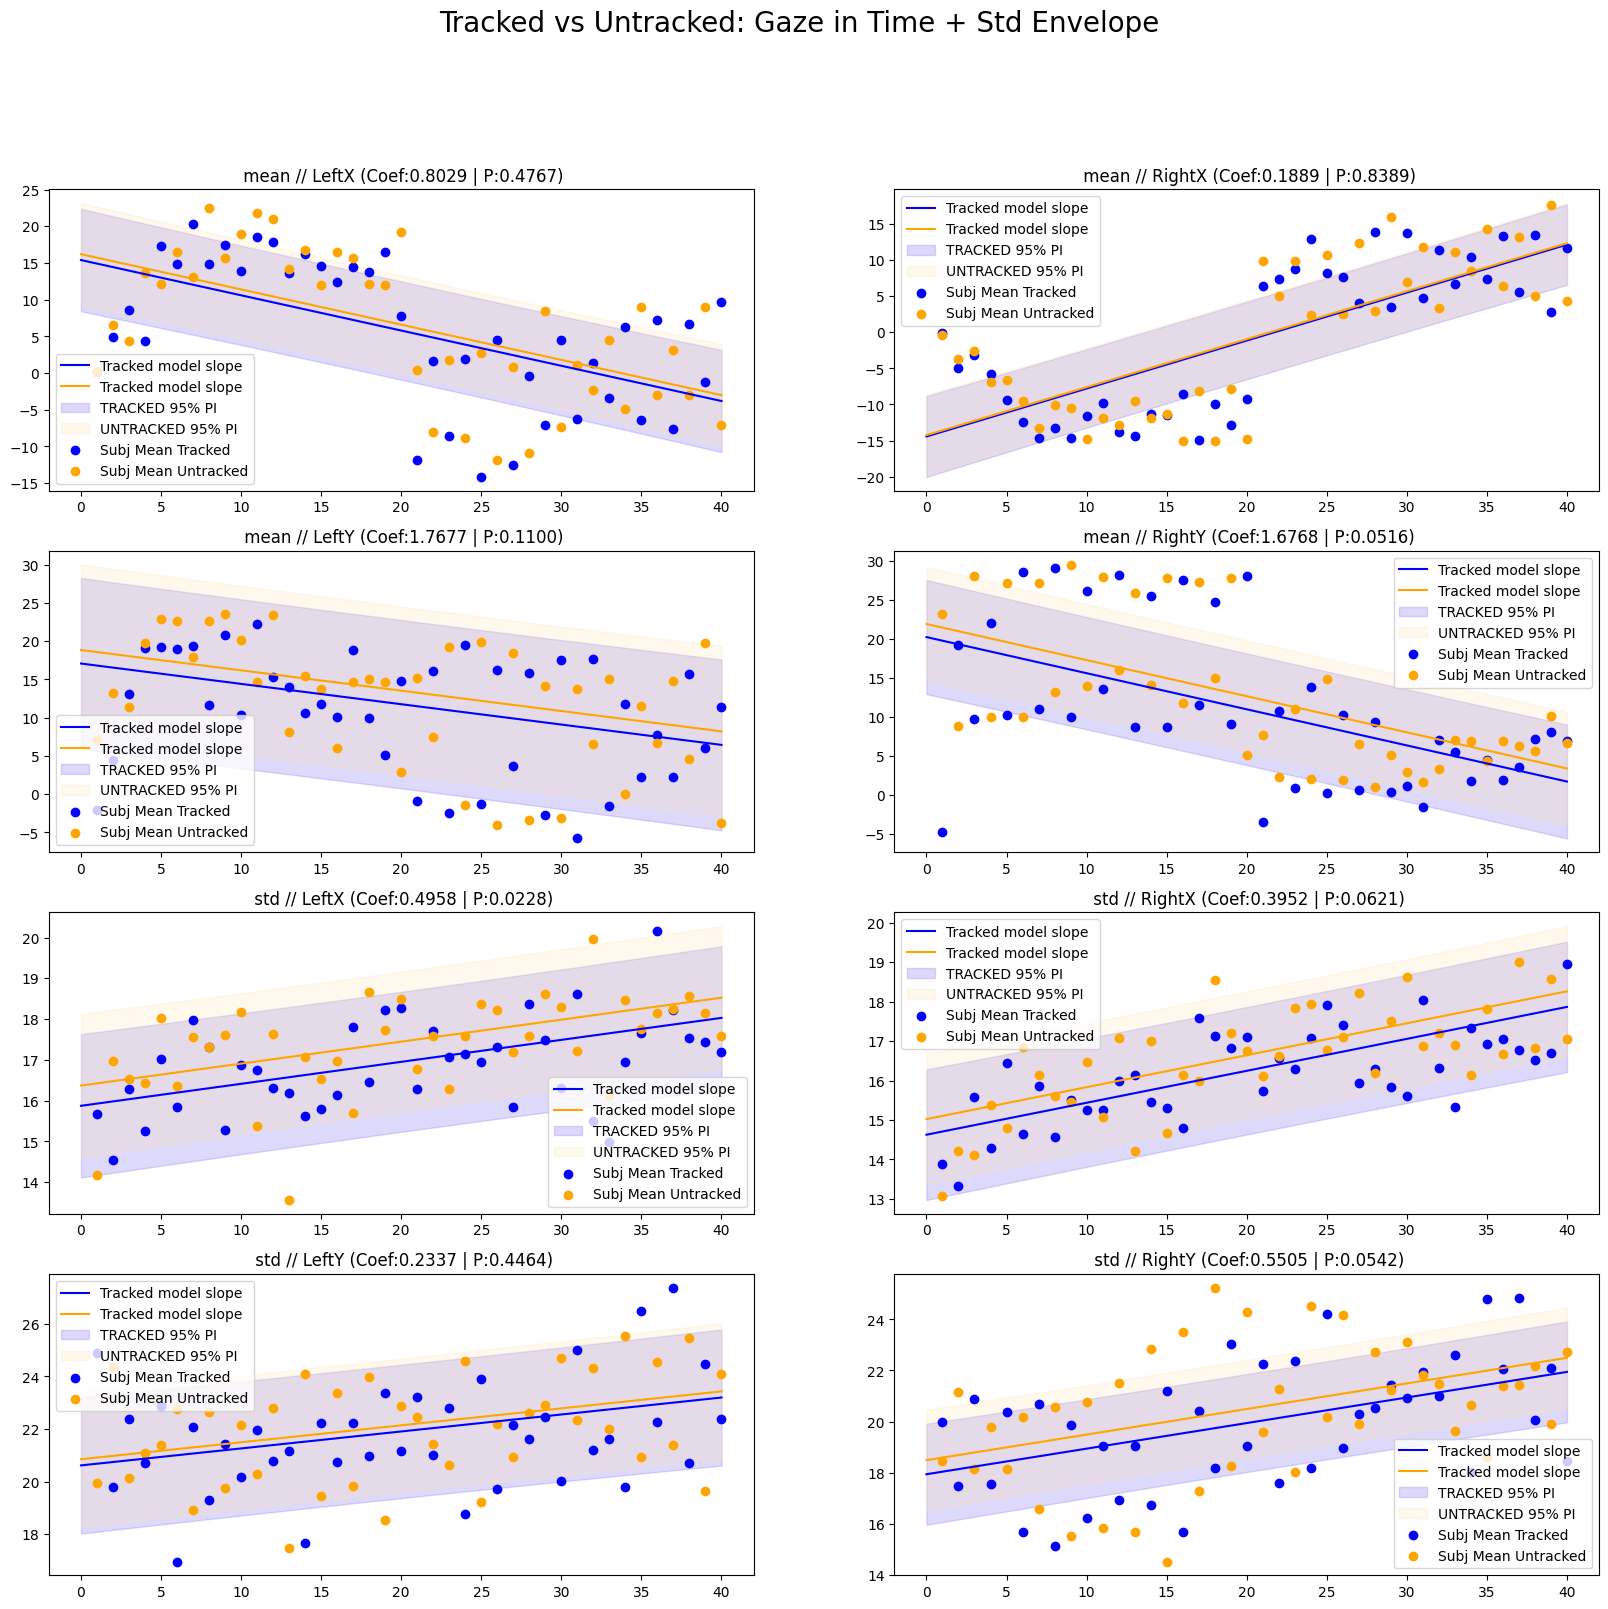

In [421]:
import statsmodels.formula.api as smf
from analysisFunctions import plotTrialTrack
models = []
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Gaze in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.8.1) Gaze Parameters vs Tracking (Gaze ~ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Gaze'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Gaze'][ind[0]][ind[1]], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Gaze', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Gaze', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Gaze'] = pd.to_numeric(currentDf['Gaze'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Gaze'] - currentDf['Gaze'].mean() <3*currentDf['Gaze'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Gaze ~ Tracking +trialNum ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])


    indx.append("Gaze vs Tracking")
    eye.append(ind[0])
    analysis.append(ind[1])



    plotTrialTrack(m,"Gaze",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"GzevsTrackin_{est}_{exclusionName}.png"))



======== Test for Pupil Diameter mean // LeftX =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Gaze      
No. Observations: 1154    Method:             REML      
No. Groups:       29      Scale:              397.3440  
Min. group size:  37      Log-Likelihood:     -5137.8031
Max. group size:  40      Converged:          Yes       
Mean group size:  39.8                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      5.968    3.365  1.773 0.076 -0.628 12.564
MW_Estimate   -1.110    0.596 -1.863 0.062 -2.278  0.058
DS Var       318.469    4.458                           



======== Test for Pupil Diameter mean // RightX =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Gaze      
No. Observations: 1154    Method:             R

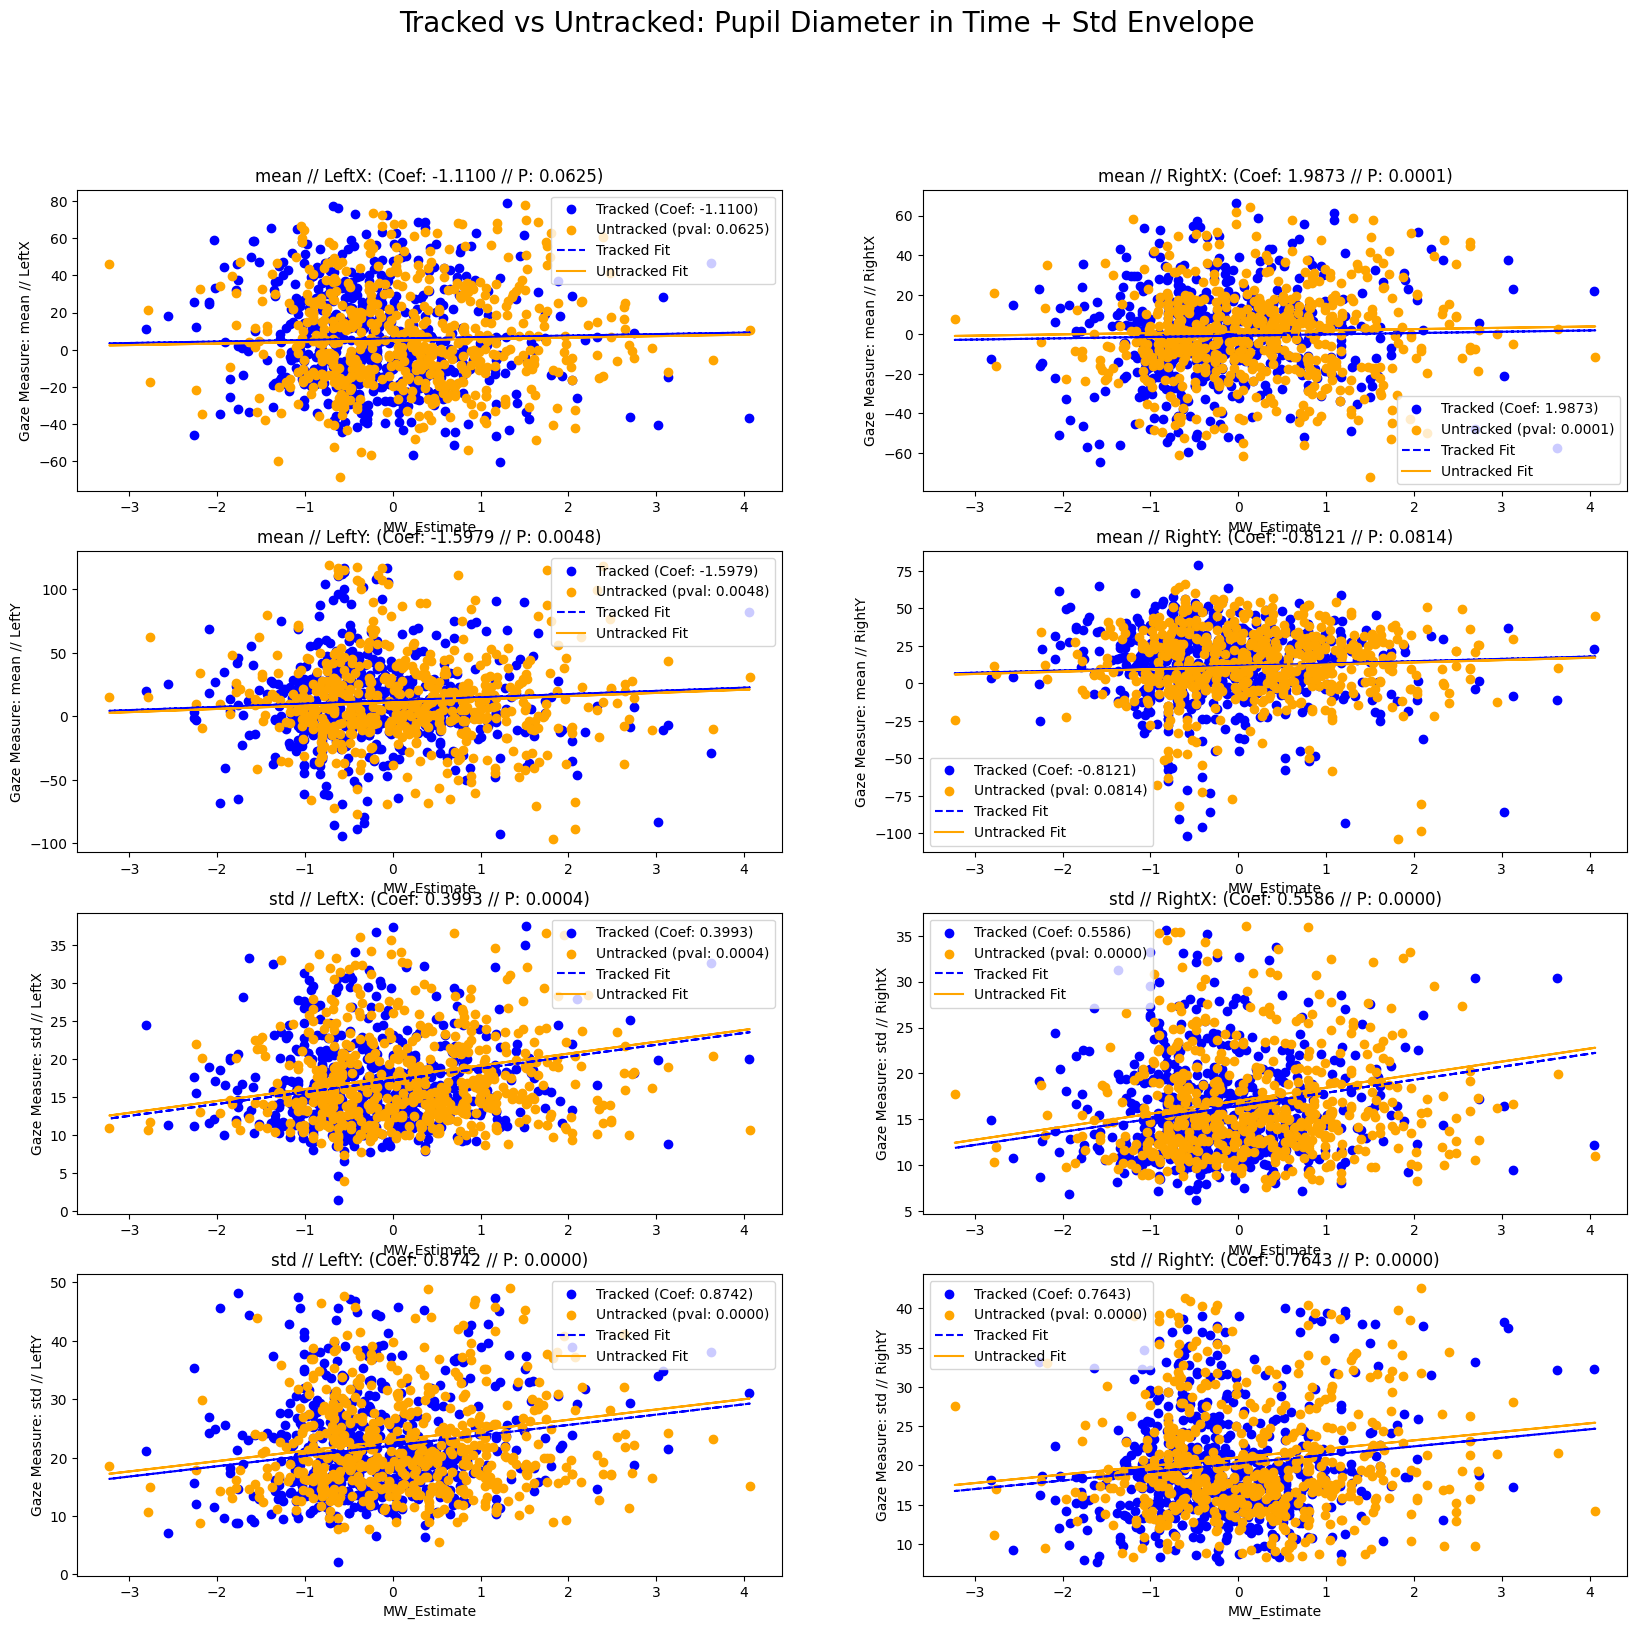

In [422]:
import statsmodels.formula.api as smf
from analysisFunctions import plotTrialTrack
models = []
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.8.2) Gaze Parameters vs MW (Gaze ~ MW_Estimate+ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Gaze'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Gaze'][ind[0]][ind[1]],grand_df['MW_Estimate'], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Gaze','MW_Estimate', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric    
    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this

    # Clean the data
    currentDf = currentDf.dropna(subset=['Gaze', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Gaze'] = pd.to_numeric(currentDf['Gaze'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Gaze'] - currentDf['Gaze'].mean() <3*currentDf['Gaze'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Gaze ~ MW_Estimate", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Gaze vs MW")
    eye.append(ind[0])
    analysis.append(ind[1])

    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas='Gaze',meas2=1)

plt.savefig(os.path.join(statPath,f"GazevsMW_{est}_{exclusionName}.png"))

### (1.9) Saccade and BLink Testing

Here we check whethet tracking Untracking Conditions, as well as Mind Wandering depends on Saccades And/ Or Blinks:
WARNING This is for ALL of the duration of Trial


#### (1.9.1) Saccades vs Tracking/Untracking



======== Test for Saccades  // SaccDistance =======

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Saccade   
No. Observations:     1123       Method:                REML      
No. Groups:           29         Scale:                 1177.8374 
Min. group size:      17         Log-Likelihood:        -5617.0274
Max. group size:      40         Converged:             Yes       
Mean group size:      38.7                                        
------------------------------------------------------------------
                       Coef.   Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               78.265    7.760 10.086 0.000 63.056 93.475
Tracking[T.UNTRACKED]    6.953    2.049  3.393 0.001  2.937 10.969
trialNum                 0.053    0.089  0.601 0.548 -0.121  0.227
DS Var                1590.035   12.884                           



======== Test for S

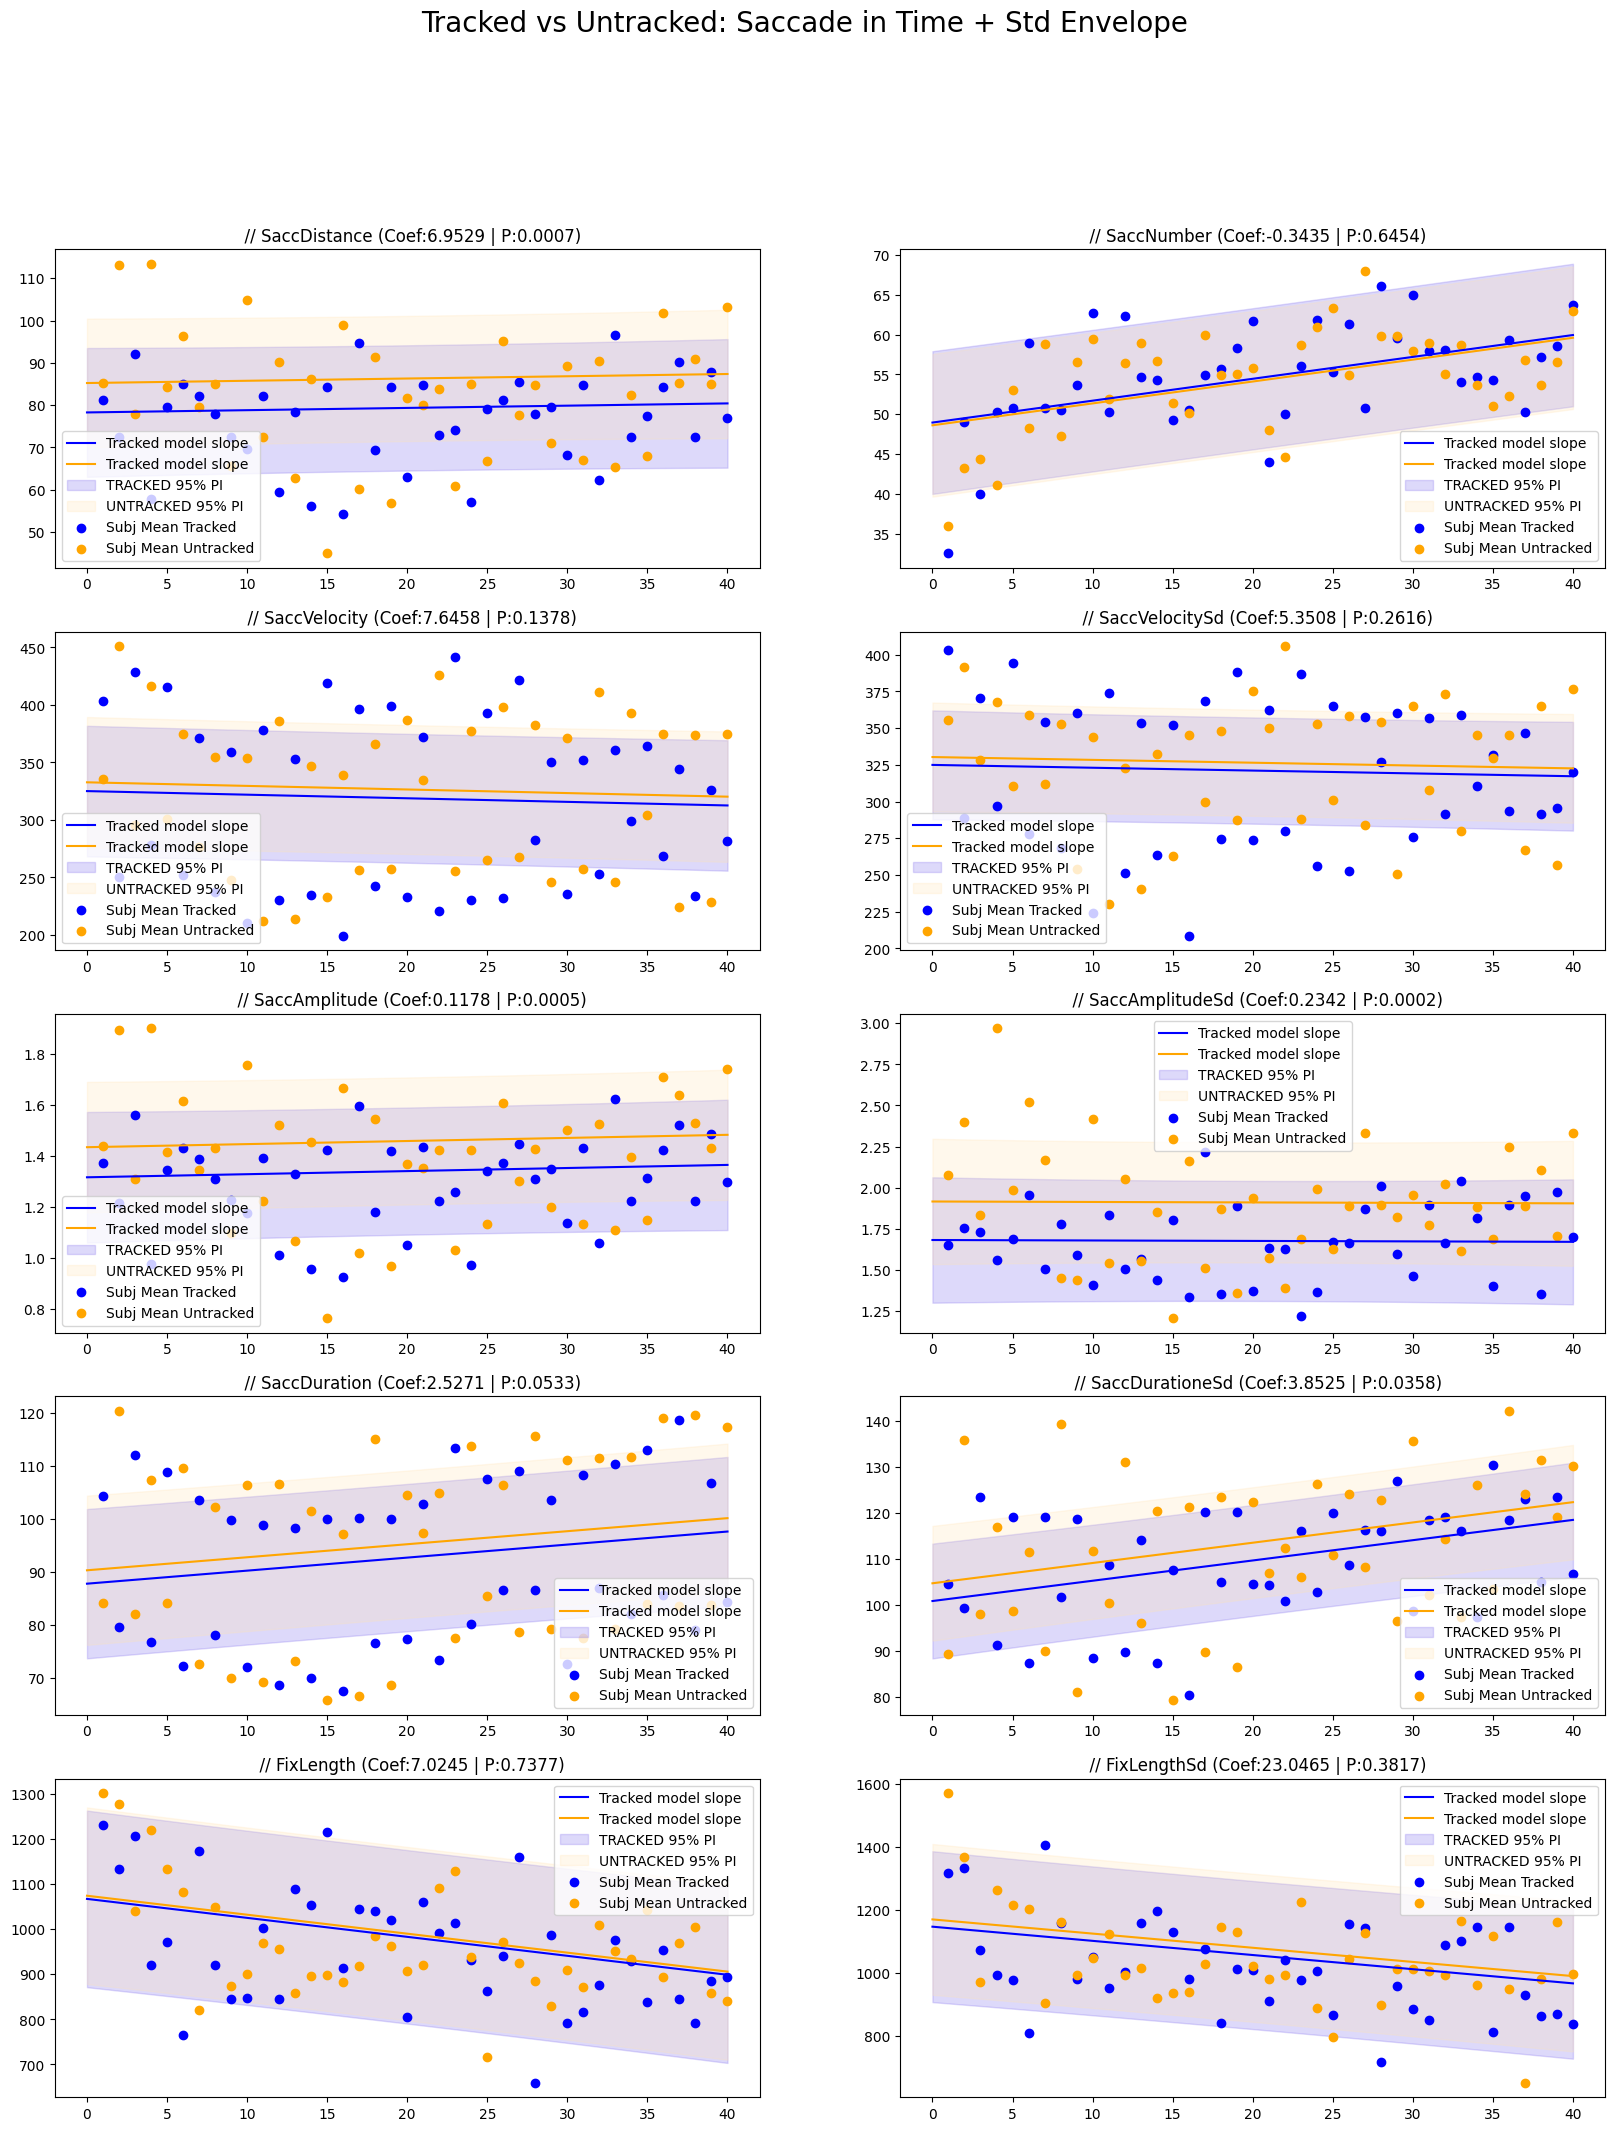

In [423]:
import statsmodels.formula.api as smf
models = []

fig, axes = plt.subplots(5,2,figsize=(20,24))
fig.suptitle("Tracked vs Untracked: Saccade in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.9.1) Saccade vs Tracking (Saccade ~ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Saccades'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Saccades {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Saccades'][ind[0]][ind[1]], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking'], grand_df['MW_Estimate']]).T
    currentDf.columns = ['Saccade', 'DS', 'trialNum', 'Tracking','MW_Estimate']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Saccade', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Saccade'] = pd.to_numeric(currentDf['Saccade'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Saccade'] - currentDf['Saccade'].mean() <3*currentDf['Saccade'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Saccade ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])
    indx.append("Saccade")
    eye.append(ind[0])
    analysis.append(ind[1])

    plotTrialTrack(m,"Saccade",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"SaccadevsTracking_Unc_{est}_{exclusionName}.png"))

#### (1.9.2) Saccades vs Mind Wandering



======== Test MW vs Saccades  // SaccDistance =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Saccade   
No. Observations: 1123    Method:             REML      
No. Groups:       29      Scale:              1172.4849 
Min. group size:  17      Log-Likelihood:     -5614.0390
Max. group size:  40      Converged:          Yes       
Mean group size:  38.7                                  
--------------------------------------------------------
             Coef.   Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     82.769    7.430 11.139 0.000 68.206 97.333
MW_Estimate    4.180    1.037  4.031 0.000  2.148  6.213
DS Var      1570.078   12.752                           



======== Test MW vs Saccades  // SaccNumber =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Saccade   
No. Observations: 1152    Method:             REML  

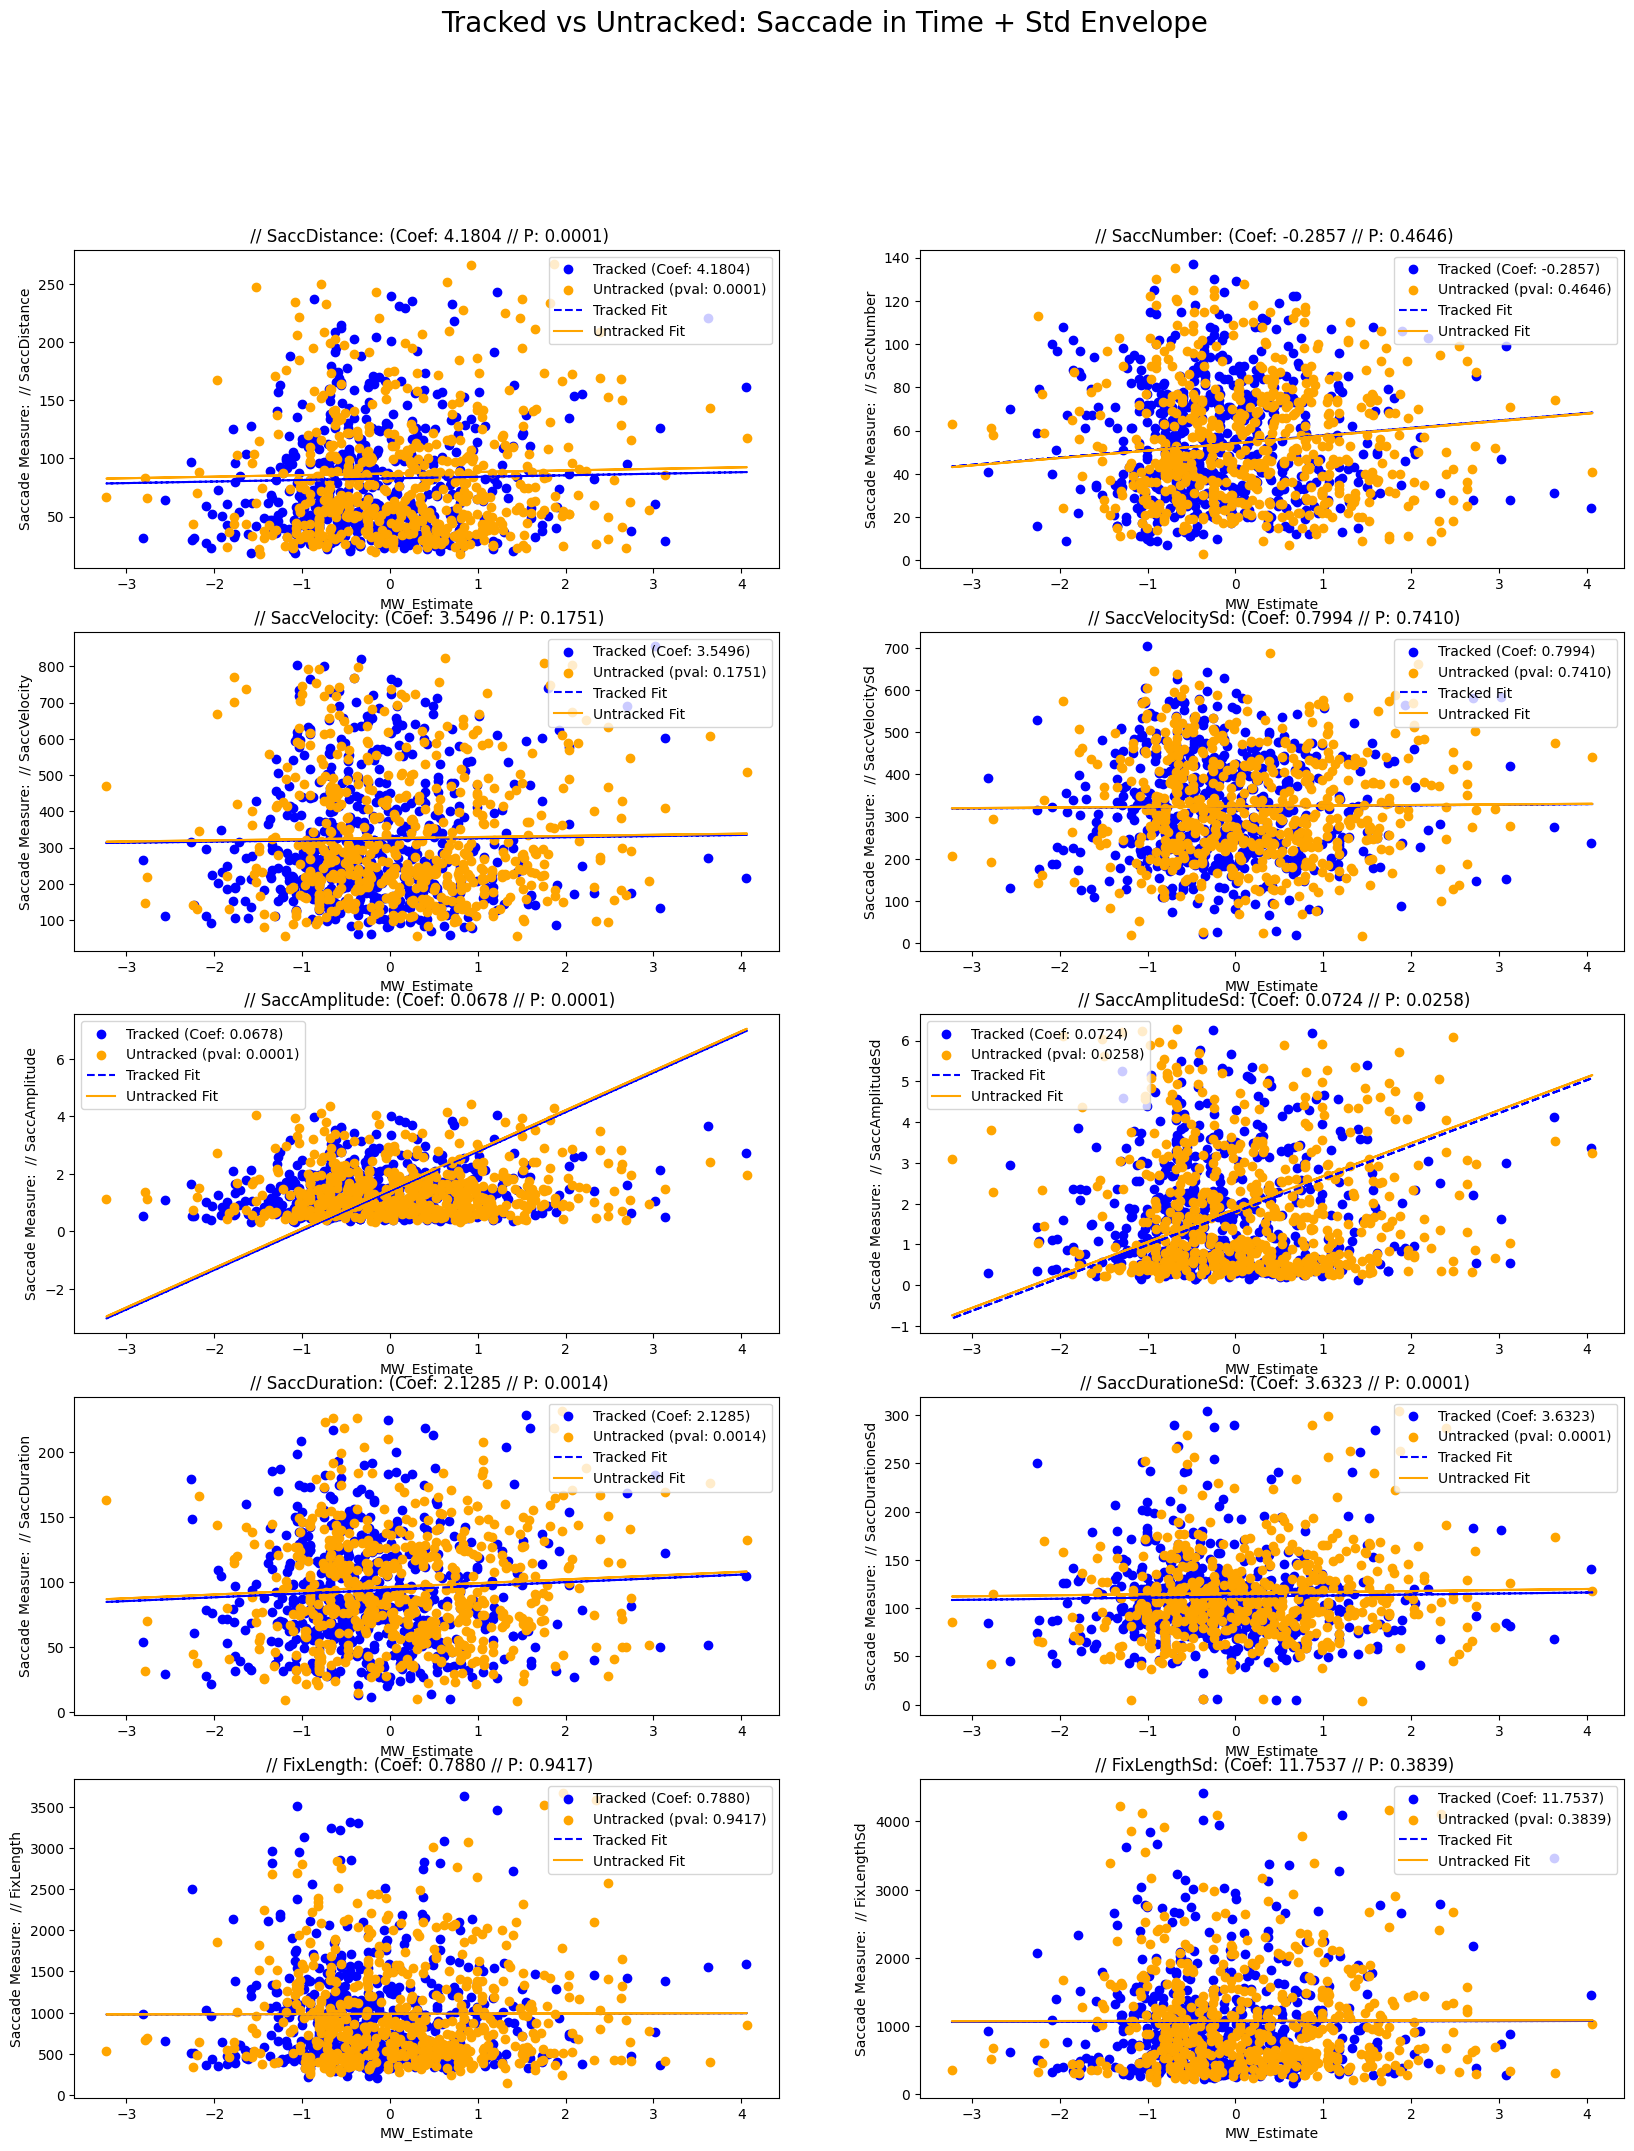

In [424]:
import statsmodels.formula.api as smf
models = []

import matplotlib.pyplot as plt
from analysisFunctions import plot_pupil_vs_mw
fig, axes = plt.subplots(5, 2, figsize=(20, 24))  # Adjust rows/columns as needed
fig.suptitle("Tracked vs Untracked: Saccade in Time + Std Envelope", fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
currentModels =[];

log_file.write("\n(1.9.2) Saccades vs MW (Saccade ~ MW +Tracking +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Saccades'].columns):
    print("\n\n=============================================================")
    print(f"======== Test MW vs Saccades {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Saccades'][ind[0]][ind[1]], grand_df['MW_Estimate'], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Saccade','MW_Estimate', 'DS', 'trialNum', 'Tracking']

    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this
    # Clean the data
    currentDf = currentDf.dropna(subset=['Saccade','MW_Estimate', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Saccade'] = pd.to_numeric(currentDf['Saccade'], errors='coerce')  # Ensure numeric
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Saccade'] - currentDf['Saccade'].mean() <3*currentDf['Saccade'].std()]
    # Fit the mixed effects model
    m = smf.mixedlm("Saccade ~ MW_Estimate ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    currentModels.append(m)
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")

    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Saccade x MW")
    eye.append(ind[0])
    analysis.append(ind[1])

    print(m.summary())  # ≈ summary(lm(...)) in R
    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas='Saccade',meas2=1)
plt.savefig(os.path.join(statPath,f"SaccadevsMW_Unc_{est}_{exclusionName}.png"))

#### (1.9.3) Blink vs Tracking/Untracking



======== Test for Blinks  // BlinkNumber =======

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Blinks    
No. Observations:     1139      Method:               REML      
No. Groups:           29        Scale:                22.7471   
Min. group size:      26        Log-Likelihood:       -3468.6417
Max. group size:      40        Converged:            Yes       
Mean group size:      39.3                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             14.784    1.732  8.536 0.000 11.389 18.178
Tracking[T.UNTRACKED] -0.139    0.283 -0.491 0.624 -0.693  0.415
trialNum               0.093    0.012  7.626 0.000  0.069  0.118
DS Var                84.028    4.802                           



======== Test for Blinks  // BlinkRate =======




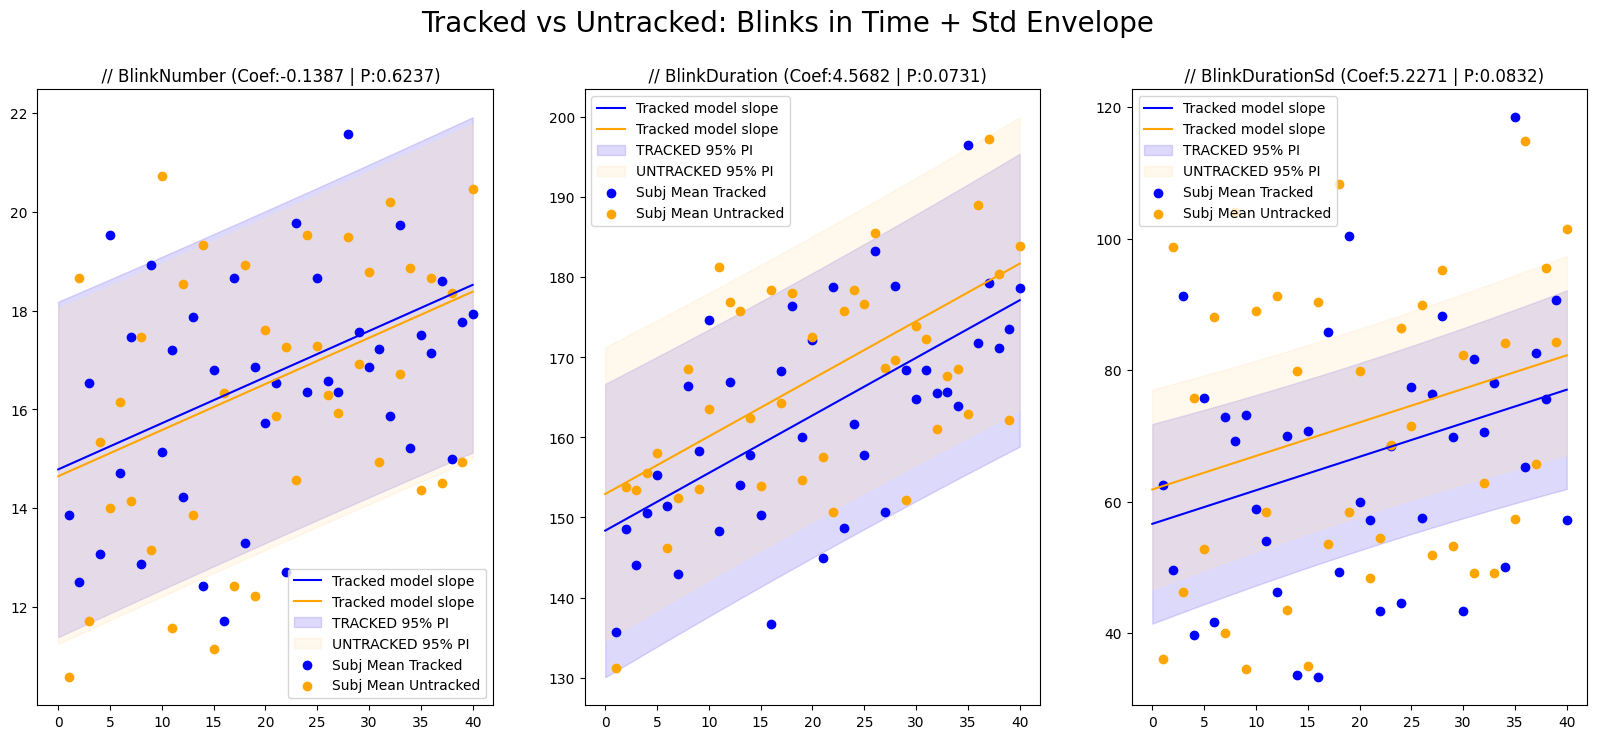

In [425]:
import statsmodels.formula.api as smf
models = []

fig, axes = plt.subplots(1,3,figsize=(20,8))
fig.suptitle("Tracked vs Untracked: Blinks in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.9.1) Blinks vs Tracking (Blinks ~ Tracking +TrialNum +(1|Subjects)) \n")

mcount = -1;
for i, ind in enumerate(grand_df['Blinks'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Blinks {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")
    if ind[1] == 'BlinkRate':
        continue
    mcount += 1
    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Blinks'][ind[0]][ind[1]], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking'], grand_df['MW_Estimate']]).T
    currentDf.columns = ['Blinks', 'DS', 'trialNum', 'Tracking','MW_Estimate']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Blinks', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Blinks'] = pd.to_numeric(currentDf['Blinks'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Blinks'] - currentDf['Blinks'].mean() <3*currentDf['Blinks'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Blinks ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])
    indx.append("Blinks")
    eye.append(ind[0])
    analysis.append(ind[1])

    plotTrialTrack(m,"Blinks",currentDf,axes[mcount],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"BlinksvsTracking_Unc_{est}_{exclusionName}.png"))

#### (1.9.4) Blink vs Mind Wandering



======== Test MW vs Blinks  // BlinkNumber =======

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Blinks    
No. Observations:     1139      Method:               REML      
No. Groups:           29        Scale:                22.7657   
Min. group size:      26        Log-Likelihood:       -3469.5772
Max. group size:      40        Converged:            Yes       
Mean group size:      39.3                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             14.806    1.733  8.542 0.000 11.409 18.203
Tracking[T.UNTRACKED] -0.156    0.288 -0.541 0.588 -0.720  0.409
MW_Estimate            0.047    0.149  0.314 0.753 -0.245  0.339
trialNum               0.093    0.012  7.455 0.000  0.068  0.117
DS Var                84.015    4.800             

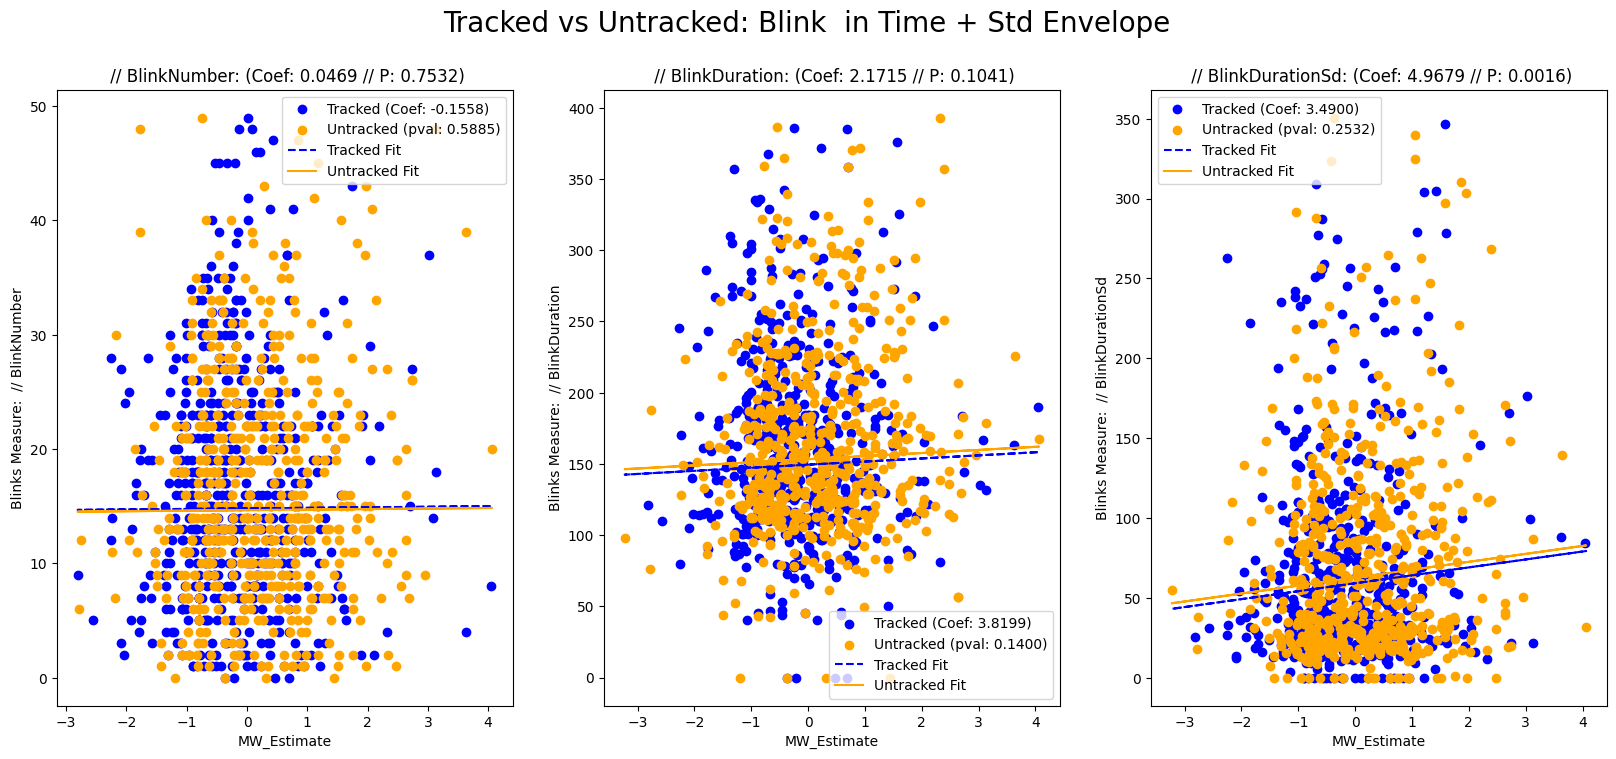

In [426]:
import statsmodels.formula.api as smf
models = []

import matplotlib.pyplot as plt
from analysisFunctions import plot_pupil_vs_mw
fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Adjust rows/columns as needed
fig.suptitle("Tracked vs Untracked: Blink  in Time + Std Envelope", fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
currentModels =[];

log_file.write("\n(1.9.2) Blinks vs MW (Blinks ~ MW +Tracking +(1|Subjects)) \n")
mcount = -1
for i, ind in enumerate(grand_df['Blinks'].columns):
    print("\n\n=============================================================")
    print(f"======== Test MW vs Blinks {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")
    if ind[1] == 'BlinkRate':
        continue
    mcount += 1
    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([grand_df['Blinks'][ind[0]][ind[1]], grand_df['MW_Estimate'], grand_df['DS'], grand_df['trialNum'], grand_df['Tracking']]).T
    currentDf.columns = ['Blinks','MW_Estimate', 'DS', 'trialNum', 'Tracking']

    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this
    # Clean the data
    currentDf = currentDf.dropna(subset=['Blinks','MW_Estimate', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Blinks'] = pd.to_numeric(currentDf['Blinks'], errors='coerce')  # Ensure numeric
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Blinks'] - currentDf['Blinks'].mean() <3*currentDf['Blinks'].std()]
    # Fit the mixed effects model
    m = smf.mixedlm("Blinks ~ MW_Estimate +Tracking  +trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    currentModels.append(m)
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")

    coefs.append(m.params[m.params.keys()[2]])
    zvals.append(m.tvalues[m.params.keys()[2]])
    pvals.append(m.pvalues[m.params.keys()[2]])
    conf1.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[2]][1])

    coefsT.append(m.params[m.params.keys()[3]])
    zvalsT.append(m.tvalues[m.params.keys()[3]])
    pvalsT.append(m.pvalues[m.params.keys()[3]])
    conf1T.append(m.conf_int().loc[m.params.keys()[3]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[3]][1])

    indx.append("Blinks x MW")
    eye.append(ind[0])
    analysis.append(ind[1])

    print(m.summary())  # ≈ summary(lm(...)) in R
    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[mcount],meas='Blinks')
plt.savefig(os.path.join(statPath,f"BlinksvsMW_Unc_{est}_{exclusionName}.png"))

#### Save Our First Data

In [427]:

def write_sheet(all_stats, sheet_name, writer,checkCol="P"):
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    for r, pval in enumerate(all_stats[checkCol], start=start_row):
        try:
            if pd.notna(pval) and float(pval) <= 0.05:
                ws.set_row(r, None, bold)
        except Exception:
            pass
# Create a MultiIndex DataFrame and Save All Oindxur Data 

index = pd.MultiIndex.from_arrays([ indx, eye, analysis], names=['Analysis Name', 'Eye', 'Mode'])
stats_df = pd.DataFrame({('Main','Coefficient'): coefs,  ('Main','Z-score'): zvals ,('Main','p-value'): pvals,('Main','conf1'):conf1,('Main','conf2'):conf2,
                         ('Trial','Coefficient'): coefsT,  ('Trial','Z-score'): zvalsT ,('Trial','p-value'): pvalsT,('Trial','conf1'):conf1T,('Trial','conf2'):conf2T}, index=index)

with pd.ExcelWriter(os.path.join(statPath,f"statistics_unc_{est}_{exclusionName}.xlsx"), engine="xlsxwriter") as writer:
    write_sheet(stats_df, writer=writer, sheet_name="All_Stats",checkCol=("Main","p-value"))


In [428]:
len(coefs)

53

## (2) CORRECTED: Test Is Tracked Entity Different from Untracked Entity?

Since there are some trials and subjects that are clearly Unreliable, we can exclude them based on preordained criteria:

(WARNING it may be relevant only for Pupil Diameter dependent measures )

- Those that No-Pupi Events (Blinks, Outside of the screen) have not been more than 10%
- Those that General No screen + Clustering have not been 75%
- Those in which Pupil Period is not contaminated by Measurments and the rate of artefacts is less than 0.05

#### (1.1) Test Whether Pupil Diameter Differs between Tracked and Untracked Entity: 

We controll immediatley for SUBJECTS

so Making Basic Models:

        MW_estimate ~ Tracking +trialNum + (1|Subjects)


Additionally we plot the Envelope of STD from subjects as well as provide the Mean differs across subjects of MW Both in TIme as in Absolute:

Important here to check:
+ Whether there is a difference between Tracked and Untracked Entity
+ Whether there is an Effect of Trial Number (As MW Rate should increase in time)

In [429]:

from analysisFunctions import qualityChecks
partiaclCheck0 = grand_df[grand_df['Checks']['']['gazeRate'] <0.20]
partiaclCheck1L,partiaclCheck2L,trmw1L,untrmw1L,trmw2L,untrmw2L =  qualityChecks(partiaclCheck0,'Left')
partiaclCheck1R,partiaclCheck2R,trmw1R,untrmw1R,trmw2R,untrmw2R =  qualityChecks(partiaclCheck0,'Right')

mw = grand_df[grand_df['Tracking'] == 'TRACKED'].groupby(['Tracking','DS'])
umw = grand_df[grand_df['Tracking'] == 'UNTRACKED'].groupby(['Tracking','DS'])

trmw = partiaclCheck0[partiaclCheck0['Tracking']=="TRACKED"].groupby(['Tracking','DS'])
untrmw  = partiaclCheck0[partiaclCheck0['Tracking']=="UNTRACKED"].groupby(['Tracking','DS'])


log_file.write("\n===# CHECKS #=== \n\n")
log_file.write(f"   Gaze Rate Rej Threshold:      {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Left NaN Rej Threshold:       {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Right NaN Rej Threshold:      {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Left Pup NaN Rej Threshold:   {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Right Pup NaN Rej Threshold:  {0.1*100}%\n\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")

print(f"   Gaze Rate Rej Threshold:      {0.1*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"   NaN Rej Threshold:            {0.751*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"      N. After Removal:           (Tr: {int(trmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"   Pup NaN Rej Threshold:        {0.95*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"      N. After Removal:           (Tr: {int(trmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")


for i,ds in enumerate(grand_df['DS'].unique()):
    print(i)
    log_file.write(f"\n  ={ds}= \n\n")
    log_file.write(f"      N. good Trials            {len(np.unique(partiaclCheck0[partiaclCheck0['DS'] == ds]['trialNum']))}\n")
    log_file.write(f"      N. of NaN Trials:         {np.sum(grand_df[grand_df['DS'] ==ds]['Pupil_Diameter']['Mean']['Left_Eye'].isna())}/{len(grand_df[grand_df['DS'] == ds])}\n")
    log_file.write(f"      Mean Good Left:           {grand_df[grand_df['DS'] == ds]['Checks']['']['goodRatioLeft'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['goodRatioLeft'].std():3.3f})\n")
    log_file.write(f"      Mean Good Right:          {grand_df[grand_df['DS'] == ds]['Checks']['']['goodRatioRight'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['goodRatioRight'].std():3.3f})\n")
    log_file.write(f"      Mean Good Pup Right:      {grand_df[grand_df['DS'] == ds]['Checks']['']['goodPupRatioLeft'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['goodPupRatioLeft'].std():3.3f})\n")
    log_file.write(f"      Mean Good Pup Right:      {grand_df[grand_df['DS'] == ds]['Checks']['']['goodPupRatioRight'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['goodPupRatioRight'].std():3.3f})\n")
    log_file.write(f"      Mean non Gaze Rate:       {grand_df[grand_df['DS'] == ds]['Checks']['']['gazeRate'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['gazeRate'].std():3.3f})\n")
    log_file.write(f"      Mean R/L Pupil Diff:      {grand_df[grand_df['DS'] == ds]['Checks']['']['pupilDiff'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['pupilDiff'].std():3.3f})\n")





C:\Users\barak\AppData\Local\Temp\ipykernel_33620\70090207.py:15: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  log_file.write(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
C:\Users\barak\AppData\Local\Temp\ipykernel_33620\70090207.py:15: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  log_file.write(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
C:\Users\barak\AppData\Local\Temp\ipykernel_33620\70090207.py:15: PerformanceWar

   Gaze Rate Rej Threshold:      10.0%
      N. After Removal:           (Tr: 567/578 || Untr: 560/576 )
   NaN Rej Threshold:            75.1%
      N. After Removal:           (Tr: 567/578 || Untr: 560/576 )
      N. After Removal:           (Tr: 567/578 || Untr: 560/576 )
   Pup NaN Rej Threshold:        95.0%
      N. After Removal:           (Tr: 533/578 || Untr: 520/576 )
      N. After Removal:           (Tr: 533/578 || Untr: 520/576 )

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


In [430]:
partiaclCheck0

MW_Estimate GazeDifference Pupil_Diameter                                \
                                          Mean                 Std             
                                      Left_Eye Right_Eye  Left_Eye Right_Eye   
0       0.788517      26.748062       0.165902  0.176082  0.092613  0.095953   
1       1.961518      23.260986      -0.061699 -0.023947  0.085620  0.106022   
2      -0.123817      24.600092       0.202896  0.162992  0.103276  0.107081   
3       1.179518      26.890070      -0.045546 -0.051558  0.044909  0.051968   
4      -1.166484      25.912801       0.004061 -0.015297  0.053249  0.064988   
...          ...            ...            ...       ...       ...       ...   
1235    2.396204      51.018427       0.080320  0.092290  0.018586  0.016326   
1236    0.101248      47.842086       0.090209  0.067271  0.027284  0.020216   
1237    1.518721      44.538468       0.298564  0.267630  0.091881  0.072976   
1238    0.776235      49.443932      -0.211616 -0.149011  0.040120  0.031139   
1239    0.506240      47.616072      -0.143066 -0.128307  0.013278  0.011107   

                                                  ...          Blinks  \
          diff                   auc              ...                   
      Left_Eye Right_Eye    Left_Eye   Right_Eye  ... BlinkDurationSd   
0    -0.125268 -0.127531  205.381851  197.185187  ...       26.689053   
1    -0.045222 -0.004766  -76.407290  -26.848570  ...      138.355677   
2    -0.109430 -0.124932  251.168775  182.519259  ...       25.582908   
3    -0.061406 -0.076708  -56.427647  -57.785944  ...       15.633559   
4     0.205500  0.229746    5.052714  -17.125622  ...       28.988469   
...        ...       ...         ...         ...  ...             ...   
1235 -0.130476 -0.103036   99.426508  103.354707  ...      111.402183   
1236 -0.150406 -0.091024  111.661766   75.326300  ...      144.305016   
1237  0.010927  0.012414  369.626867  299.715513  ...       94.145419   
1238 -0.060146 -0.061894 -262.037215 -166.916565  ...      129.501969   
1239 -0.054030 -0.049058 -177.165912 -143.727810  ...       94.251989   

           Gaze                                                         \
           mean                                         std              
          LeftX     RightX      LeftY     RightY      LeftX     RightX   
0     -3.714250  -2.560918   2.887622   4.813998  16.353546  11.365964   
1      7.165421   0.320350  14.019685   9.173113  11.046577  10.125931   
2      4.711742   4.221188  16.432872   8.802660  12.733200  11.437350   
3      3.664226   9.032275  14.769480   4.003652  11.154809  11.387285   
4     13.774986   5.089739  22.862603  11.564292   9.689280   9.517526   
...         ...        ...        ...        ...        ...        ...   
1235  60.623571  15.407607  10.967308  -6.685228  13.901098  13.726186   
1236  57.782715  19.559366  12.211433  -4.941053  17.024129  18.555451   
1237  51.281521  12.761914   8.439256   8.438566  14.514985  13.260174   
1238  54.878427   9.515158  15.808502   9.285638  13.664141  15.521909   
1239  62.806900  19.373925  14.597543  -0.732546  10.287102  11.060728   

                             Subject  
                                      
          LeftY     RightY            
0     16.909412  13.091461  AGKO2706  
1     16.112850  13.774400  AGKO2706  
2     16.955096  12.286137  AGKO2706  
3     14.588388  13.025893  AGKO2706  
4     13.872746  12.201810  AGKO2706  
...         ...        ...       ...  
1235  17.266783  16.977229  ZURY1007  
1236  21.303953  24.874722  ZURY1007  
1237  18.834381  25.582891  ZURY1007  
1238  15.258673  18.287334  ZURY1007  
1239  10.576586  14.005917  ZURY1007  

[1127 rows x 48 columns]

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    1127      Method:               REML       
No. Groups:          29        Scale:                0.8973     
Min. group size:     26        Log-Likelihood:       -1546.2605 
Max. group size:     40        Converged:            Yes        
Mean group size:     38.9                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.488    0.064 -7.660 0.000 -0.613 -0.363
Tracking[T.UNTRACKED]  0.323    0.056  5.728 0.000  0.213  0.434
trialNum               0.015    0.002  6.107 0.000  0.010  0.020
DS Var                 0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


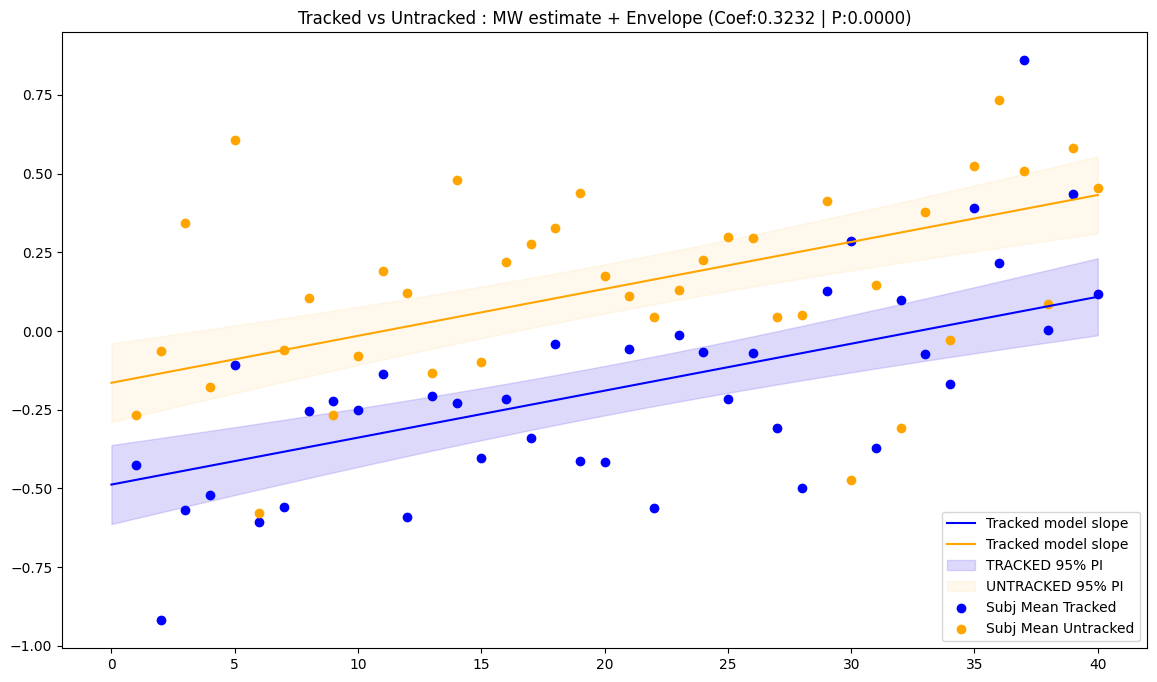

In [431]:
### Current Subject Specfic Checks: 
# 1)


import statsmodels.formula.api as smf

m = smf.mixedlm("MW_Estimate ~ Tracking+ trialNum ", data=partiaclCheck0[['DS','trialNum','Tracking','MW_Estimate']],
                groups="DS",          # random intercept
               # re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   


log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")

coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate Corr")
eye.append('')
analysis.append('Tracking')

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',partiaclCheck0,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_corr_{est}_{exclusionName}.png"))

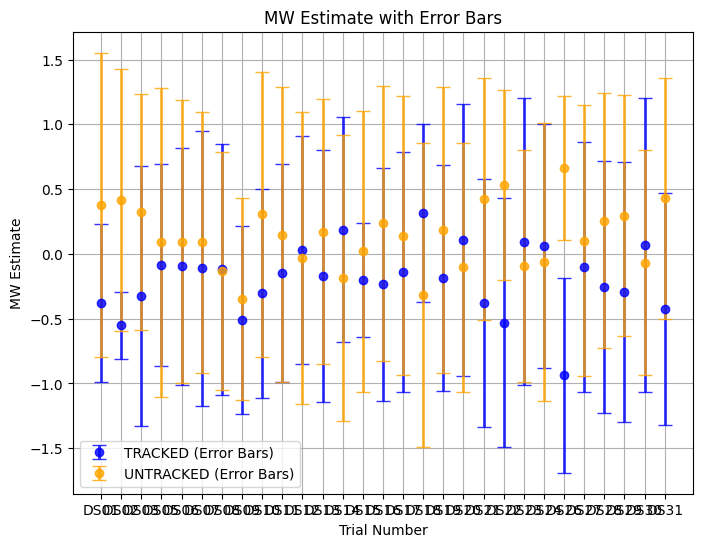

In [432]:
mew2 = partiaclCheck0[partiaclCheck0['Tracking'] == 'TRACKED'][['DS','MW_Estimate']].groupby(['DS'])
ume2 = partiaclCheck0[partiaclCheck0['Tracking'] == 'UNTRACKED'][['DS','MW_Estimate']].groupby(['DS'])


plt.figure(figsize=(8, 6))

# Plot for TRACKED group
plt.errorbar(mew2.mean().index, 
             mew2.mean()['MW_Estimate'].values, 
             yerr=mew2.std()['MW_Estimate'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(ume2.mean().index, 
             ume2.mean()['MW_Estimate'].values, 
             yerr=ume2.std()['MW_Estimate'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('MW Estimate')
plt.title('MW Estimate with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"MWacrossSubj_Corr_{est}_{exclusionName}.png"))



======== Test for Pupil Diameter Mean // Left_Eye =======

             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Pupil   
No. Observations:     1051       Method:                REML    
No. Groups:           29         Scale:                 0.0440  
Min. group size:      20         Log-Likelihood:        111.0613
Max. group size:      40         Converged:             Yes     
Mean group size:      36.2                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.131    0.021 -6.185 0.000 -0.172 -0.089
Tracking[T.UNTRACKED] -0.006    0.013 -0.449 0.653 -0.031  0.020
trialNum               0.001    0.001  1.482 0.138 -0.000  0.002
DS Var                 0.007    0.010                           



======== Test for Pupil Diameter Mean //

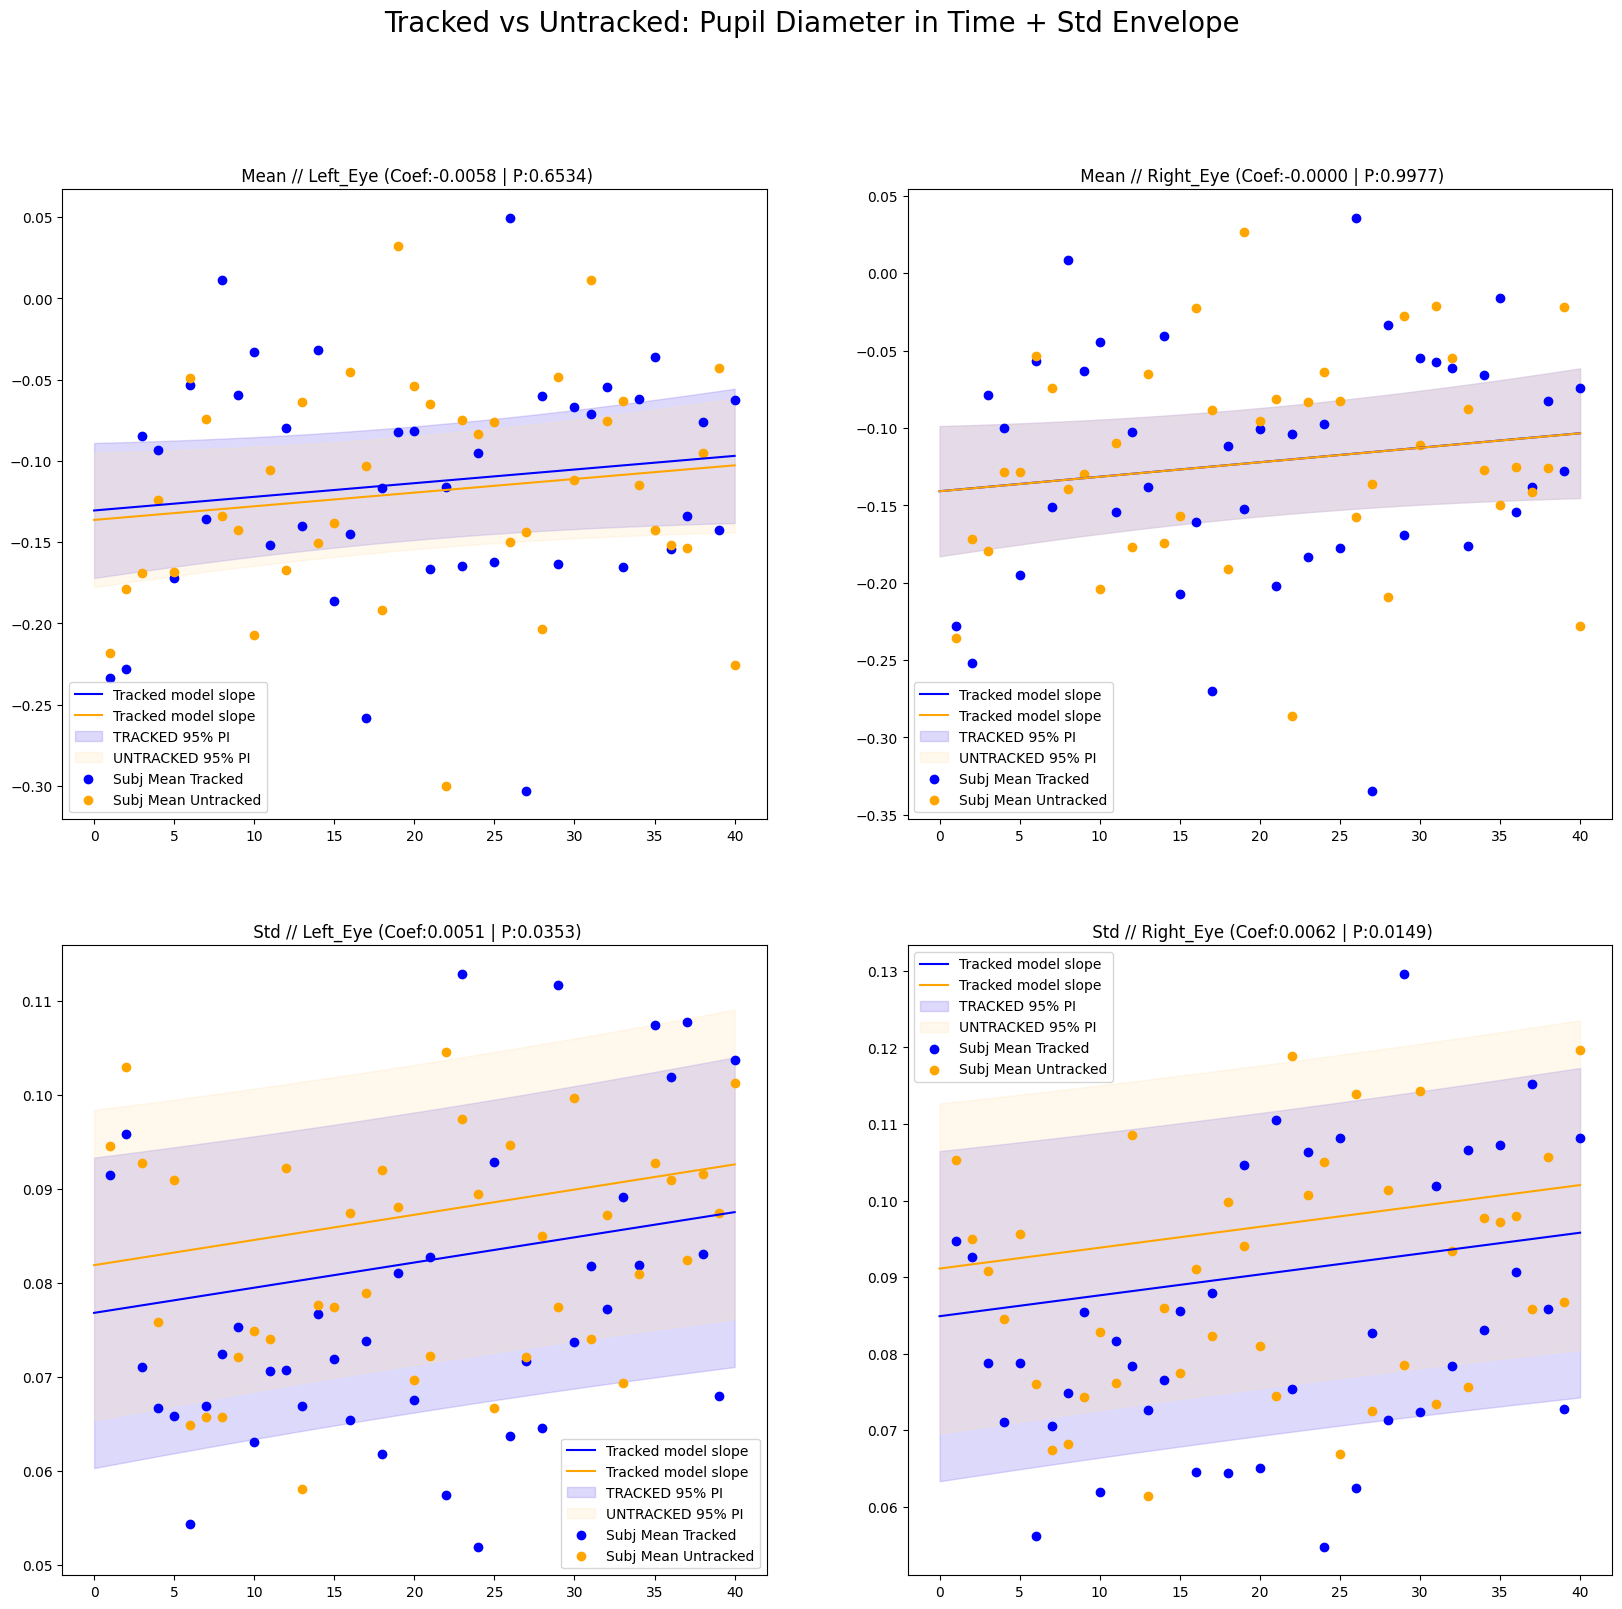

In [433]:
import statsmodels.formula.api as smf
models = []


fig, axes = plt.subplots(2,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.2) Pupil Diameter vs Tracking (Pupil ~ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Pupil_Diameter'].columns):

    if i >3:
        continue
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")


    if ind[1] == "Right_Eye":
        currentCheck = partiaclCheck2R;
    else:
        currentCheck = partiaclCheck2L;

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([currentCheck['Pupil_Diameter'][ind[0]][ind[1]], currentCheck['DS'], currentCheck['trialNum'], currentCheck['Tracking']]).T
    currentDf.columns = ['Pupil', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    

    # Clean the data
    currentDf = currentDf.dropna(subset=['Pupil', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Pupil'] = pd.to_numeric(currentDf['Pupil'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Pupil'] - currentDf['Pupil'].mean()<3*currentDf['Pupil'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Pupil ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])
    indx.append("Pupil Diam Corr")
    eye.append(ind[0])
    analysis.append(ind[1])
    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


    plotTrialTrack(m,"Pupil",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"PupilvsTracking_Corr_{est}_{exclusionName}.png" ))



======== Test for Pupil Diameter Mean // Left_Eye =======

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Pupil   
No. Observations: 1051    Method:             REML    
No. Groups:       29      Scale:              0.0441  
Min. group size:  20      Log-Likelihood:     115.9602
Max. group size:  40      Converged:          Yes     
Mean group size:  36.2                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept   -0.116    0.017 -7.026 0.000 -0.149 -0.084
MW_Estimate  0.004    0.007  0.620 0.536 -0.009  0.017
DS Var       0.007    0.010                           



======== Test for Pupil Diameter Mean // Right_Eye =======

        Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Pupil  
No. Observations:  1050    Method:             REML   
No. Groups:   

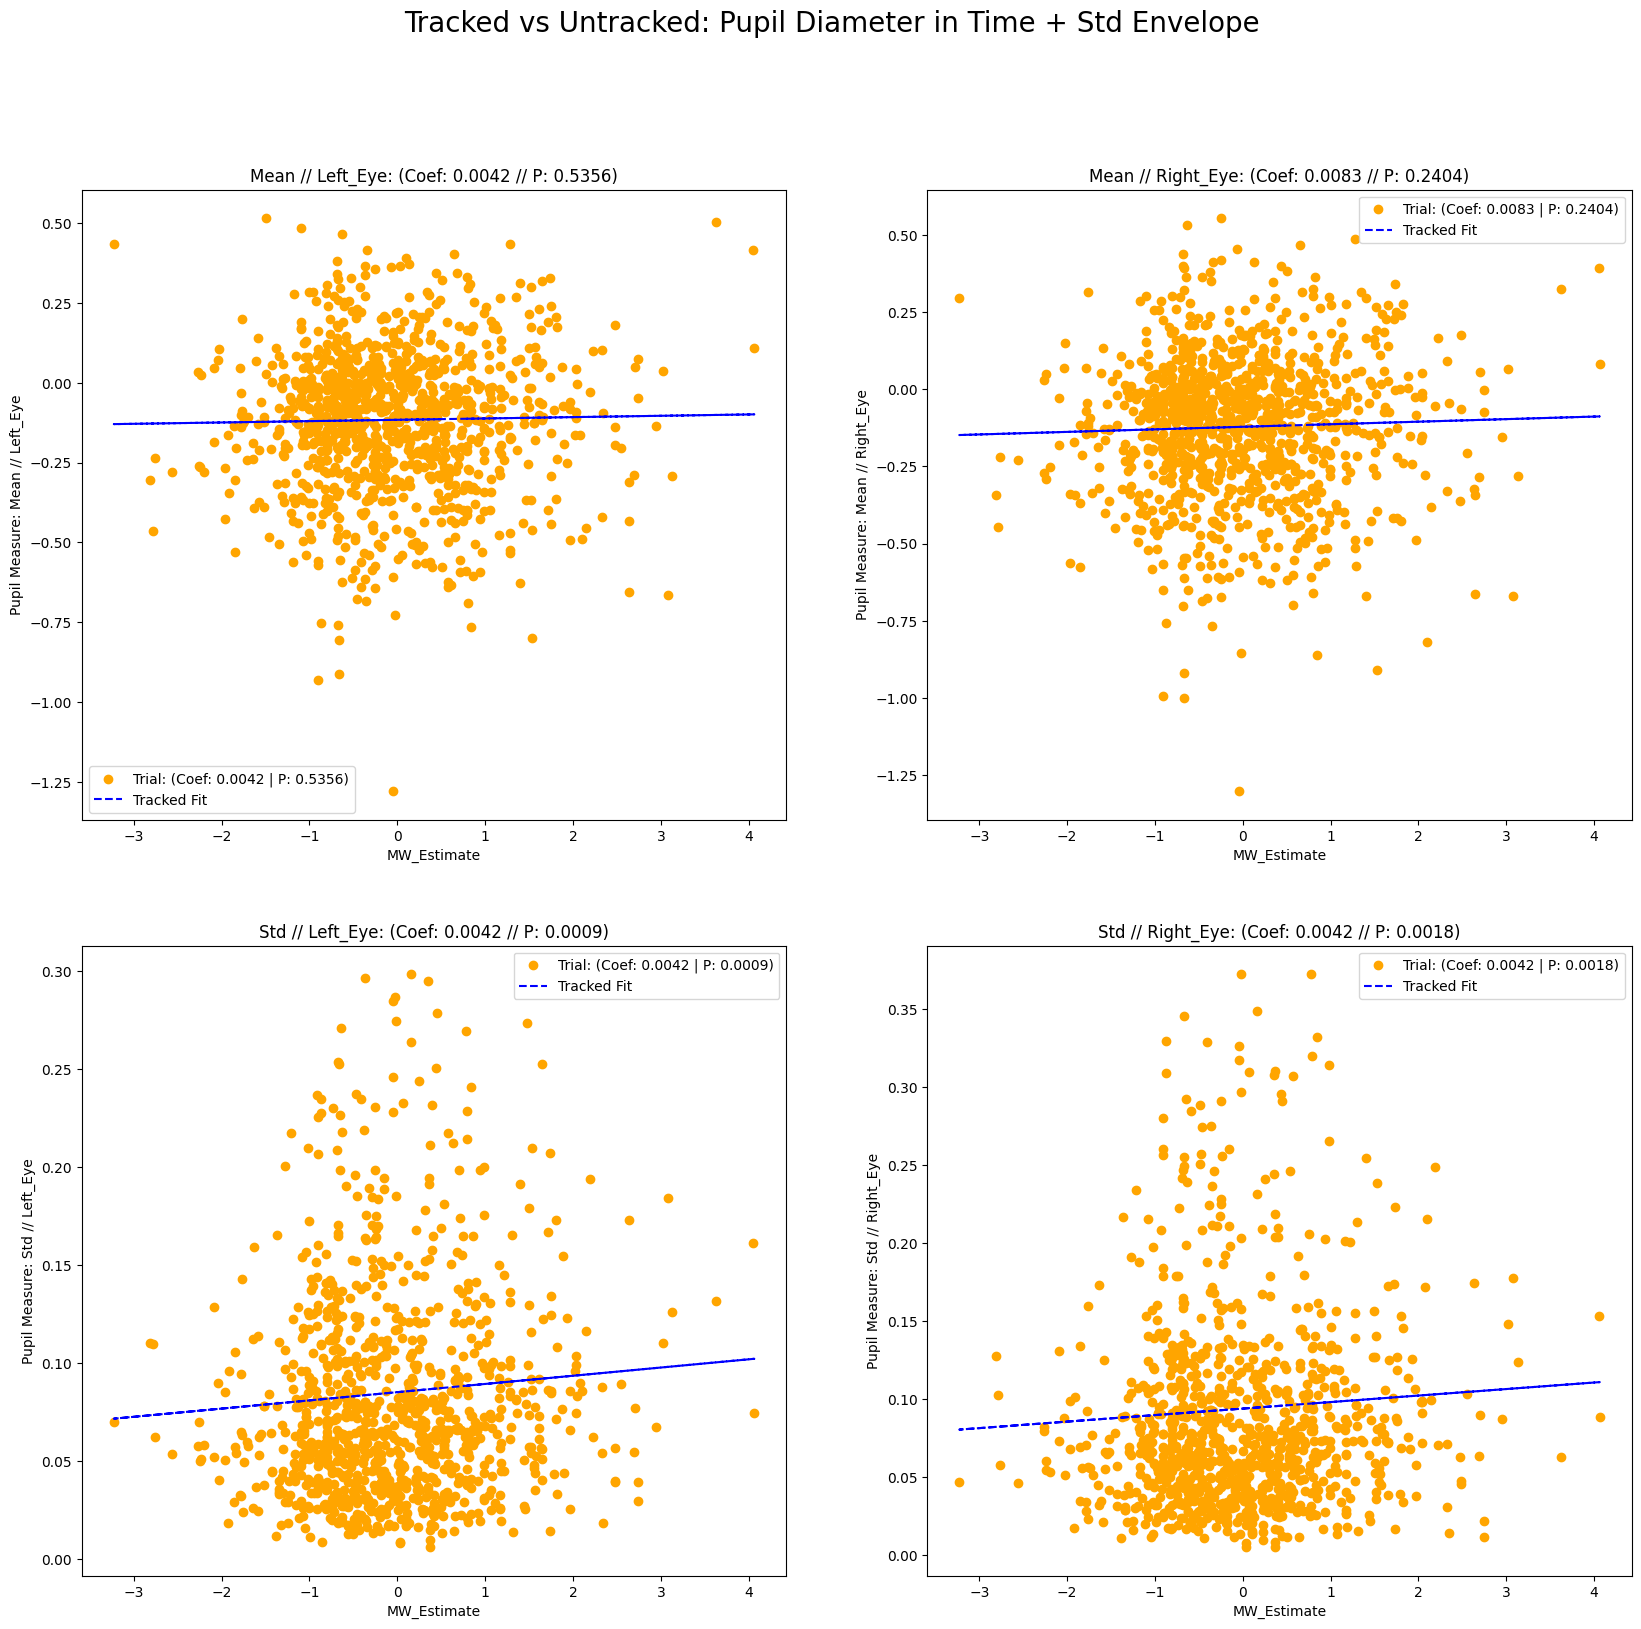

In [434]:

fig, axes = plt.subplots(2, 2, figsize=(20, 18))  # Adjust rows/columns as needed
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope", fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes

log_file.write("\n(1.3) Pupil Diameter vs MW (Pupil ~ MW +Tracking +(1|Subjects)) \n")

for i, ind in enumerate(grand_df['Pupil_Diameter'].columns):

    if i >3:
        continue

    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")


    if ind[1] == "Right_Eye":
        currentCheck = partiaclCheck2R;
    else:
        currentCheck = partiaclCheck2L;

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([currentCheck['Pupil_Diameter'][ind[0]][ind[1]], currentCheck['MW_Estimate'], currentCheck['DS'], currentCheck['trialNum'], currentCheck['Tracking']]).T
    currentDf.columns = ['Pupil','MW_Estimate', 'DS', 'trialNum', 'Tracking']

    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this
    # Clean the data
    currentDf = currentDf.dropna(subset=['Pupil','MW_Estimate', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Pupil'] = pd.to_numeric(currentDf['Pupil'], errors='coerce')  # Ensure numeric
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Pupil'] - currentDf['Pupil'].mean() <3*currentDf['Pupil'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Pupil ~ MW_Estimate ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
     

    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Pupil x MW corr")
    eye.append(ind[0])
    analysis.append(ind[1])

    print(m.summary())
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")

    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas2=1,tracking=False)
plt.savefig(os.path.join(statPath,f"PupilvsMW_Corr_{est}_{exclusionName}.png"))

### Gaze Velocity Corrected

              Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  GazeDifference
No. Observations:    1154     Method:              REML          
No. Groups:          29       Scale:               378.2607      
Min. group size:     37       Log-Likelihood:      -5123.6401    
Max. group size:     40       Converged:           Yes           
Mean group size:     39.8                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              58.609    5.404 10.846 0.000 48.018 69.200
Tracking[T.UNTRACKED]   0.486    1.145  0.425 0.671 -1.758  2.731
trialNum               -0.005    0.050 -0.104 0.917 -0.103  0.092
DS Var                797.922   11.234                           



c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


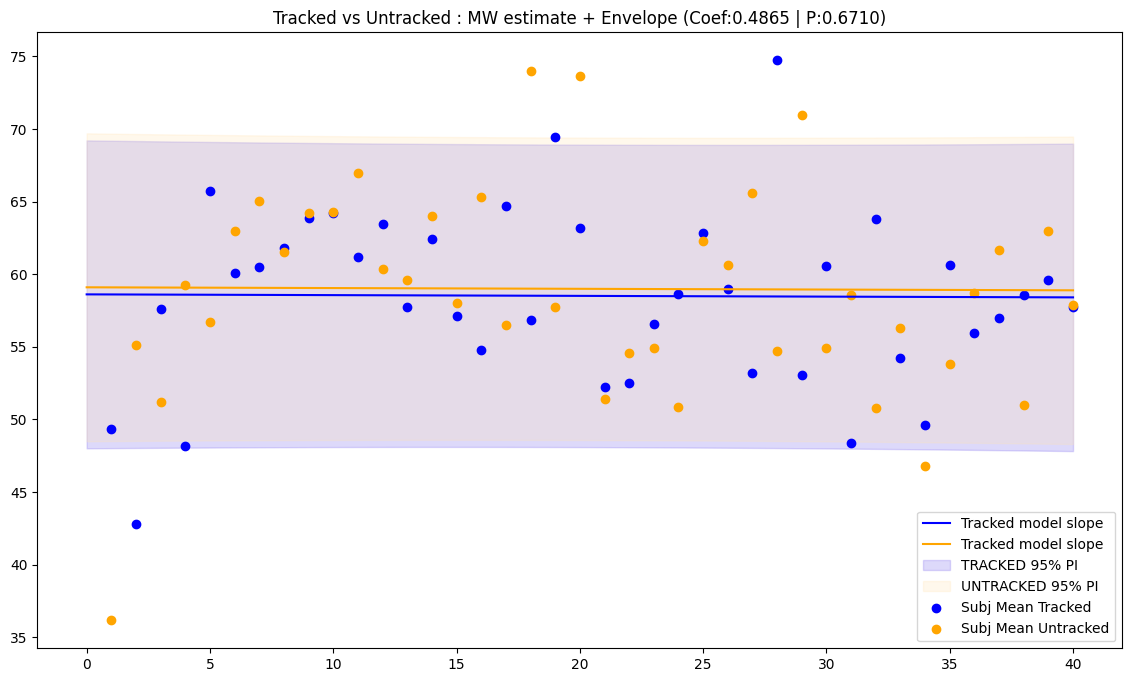

In [435]:
import statsmodels.formula.api as smf

m = smf.mixedlm("GazeDifference ~ Tracking +trialNum", data=grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()

log_file.write("(1.4.1) Uncorrected Samples (GazeDifference ~ Tracking  +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("Gaze Difference Corrected ")
eye.append('')
analysis.append('Tracking')

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'GazeDifference',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" ,paramNum = [0,1,2])
plt.savefig(os.path.join(statPath,f"GazeDiff_TrVsUntr_Corr_{est}_{exclusionName}.png"))



Intercept                5.136933
Tracking[T.UNTRACKED]    1.000000
trialNum                 1.000000
dtype: float64


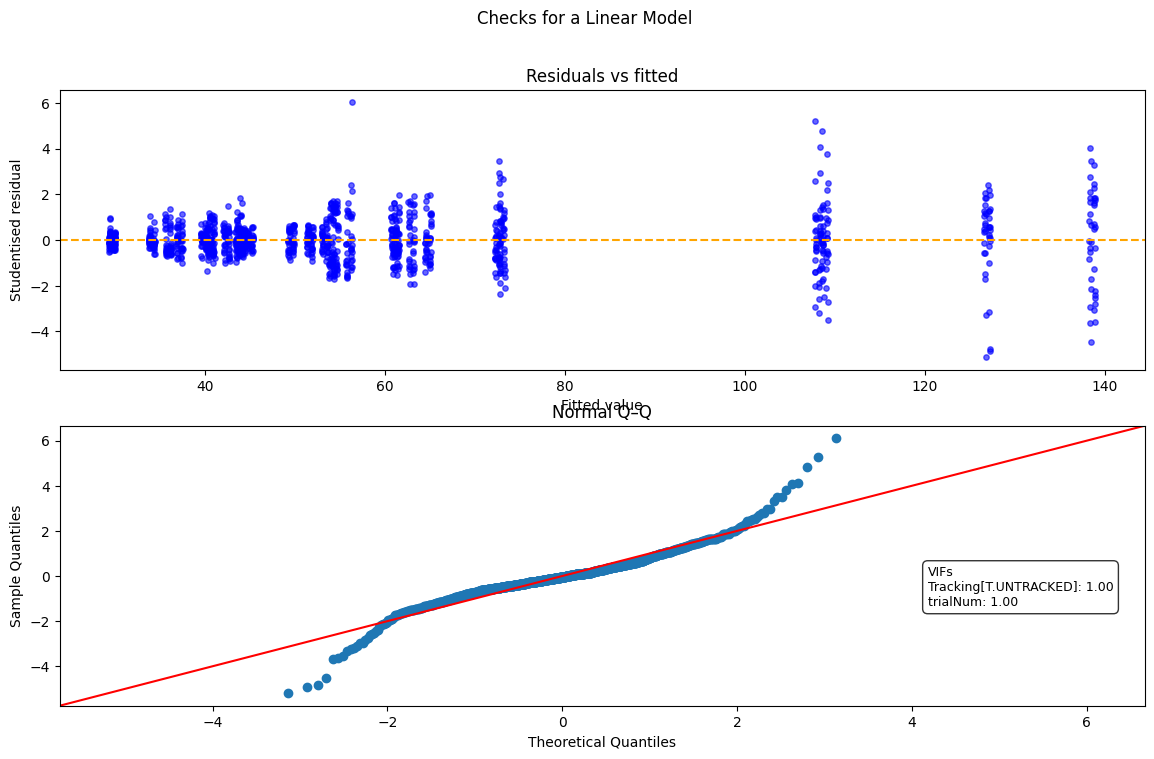

In [436]:
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df,formula="GazeDifference ~ Tracking +trialNum")
plt.savefig(os.path.join(statPath,f"GazeDiffCorr_TrVsUntr_Unc_Check_{est}_{exclusionName}.png"))

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: GazeDifference
No. Observations: 1154    Method:             REML          
No. Groups:       29      Scale:              376.5725      
Min. group size:  37      Log-Likelihood:     -5120.2240    
Max. group size:  40      Converged:          Yes           
Mean group size:  39.8                                      
-------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept     58.754     5.277  11.133  0.000  48.411  69.097
MW_Estimate    1.192     0.580   2.054  0.040   0.055   2.328
DS Var       798.161    11.262                               



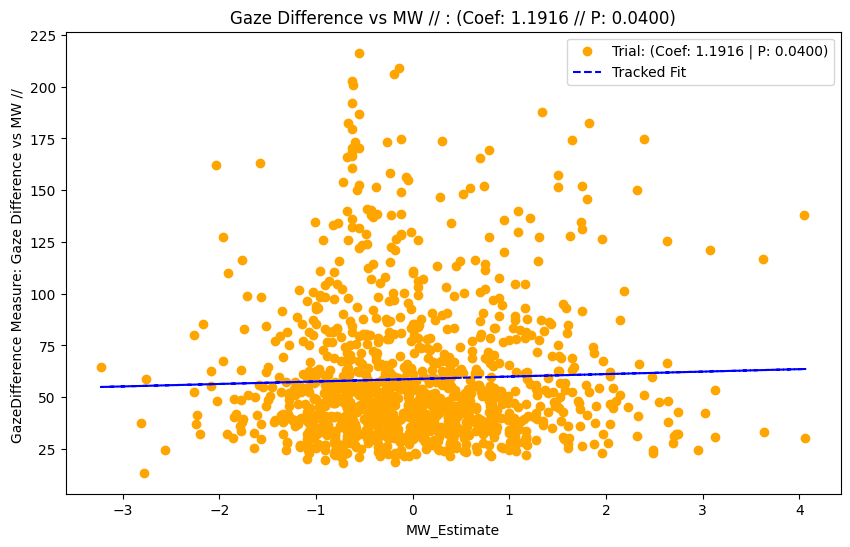

In [437]:
# Combine single-level and multi-level columns
subset = pd.concat([
    grand_df[('MW_Estimate', '', '')].rename('MW_Estimate'),

    grand_df[('Tracking', '', '')].rename('Tracking'),
    grand_df[('DS', '', '')].rename('DS'),
    grand_df[('trialNum', '', '')].rename('trialNum'),
    grand_df[('Checks', '', 'gazeDiff')].rename('gazeDiff')
], axis=1)



import statsmodels.formula.api as smf

m = smf.mixedlm(" GazeDifference~ MW_Estimate ", data=grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()

log_file.write("(1.4.2) Uncorrected Samples (MW_Estimate ~ GazeDifference+Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      MW_Estimate Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
# log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[3]]:3.3f}| Z: {m.tvalues[m.params.keys()[3]]:3.3f}| P: {m.pvalues[m.params.keys()[3]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[3]][0]:3.3f} {m.conf_int().loc[m.params.keys()[3]][1]:3.3f})\n")




print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("Gaze Difference Corr")
eye.append('')
analysis.append('MW_estimate')

plot_pupil_vs_mw(m, grand_df[['MW_Estimate','DS','Tracking','trialNum','GazeDifference']], ["Gaze Difference vs MW",""], ax=None,meas='GazeDifference',meas1=1,meas2=1,target='MW_Estimate',tracking=False)
plt.savefig(os.path.join(statPath,f"MWvsGaze_Corr_{est}_{exclusionName}.png"))


Intercept      1.000039
MW_Estimate    1.000000
dtype: float64


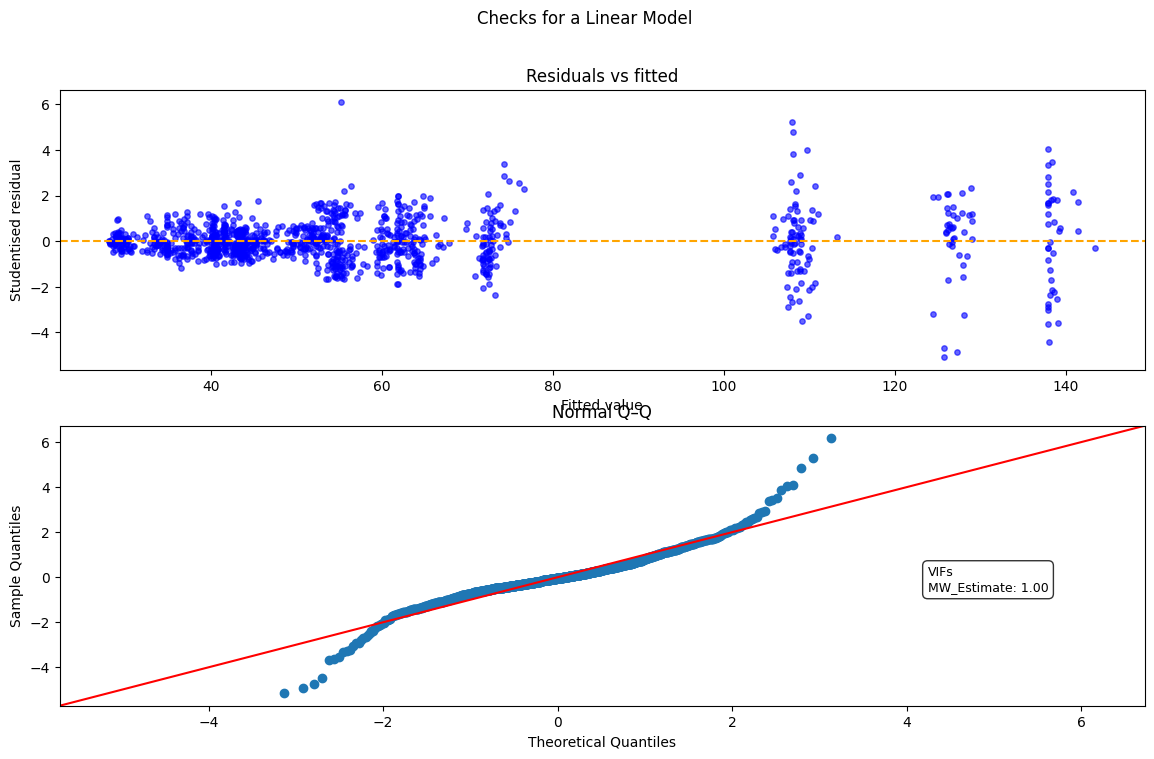

In [438]:
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df, formula="GazeDifference ~ MW_Estimate")
plt.savefig(os.path.join(statPath,f"MWvsGaze_Corr_Check_{est}_{exclusionName}.png"))

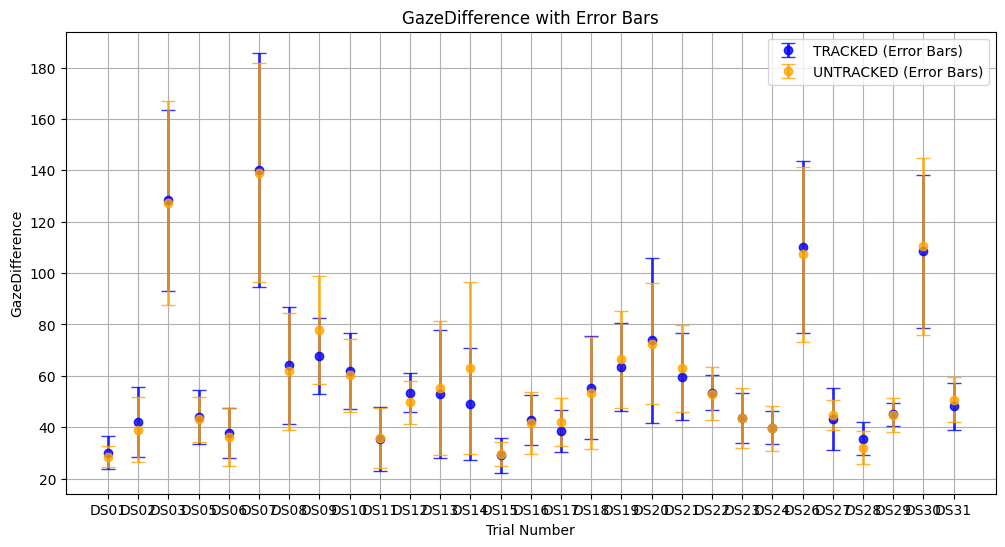

In [439]:
mew = grand_df[grand_df['Tracking'] == 'TRACKED'][['DS','GazeDifference']].groupby(['DS'])
umew = grand_df[grand_df['Tracking'] == 'UNTRACKED'][['DS','GazeDifference']].groupby(['DS'])


plt.figure(figsize=(12, 6))

# Plot for TRACKED group
plt.errorbar(mew.mean().index, 
             mew.mean()['GazeDifference'].values, 
             yerr=mew.std()['GazeDifference'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(umew.mean().index, 
             umew.mean()['GazeDifference'].values, 
             yerr=umew.std()['GazeDifference'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('GazeDifference')
plt.title('GazeDifference with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"GazeDiffacrossSubjCorr__{est}_{exclusionName}.png"))

#### Gaze Corrected



======== Test for Pupil Diameter mean // LeftX =======

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Gaze      
No. Observations:     1127       Method:                REML      
No. Groups:           29         Scale:                 369.0364  
Min. group size:      26         Log-Likelihood:        -4978.7287
Max. group size:      40         Converged:             Yes       
Mean group size:      38.9                                        
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept              15.704    3.568   4.402 0.000  8.711 22.697
Tracking[T.UNTRACKED]   0.928    1.145   0.810 0.418 -1.316  3.172
trialNum               -0.499    0.050 -10.056 0.000 -0.596 -0.402
DS Var                320.589    4.655                            



======== Test fo

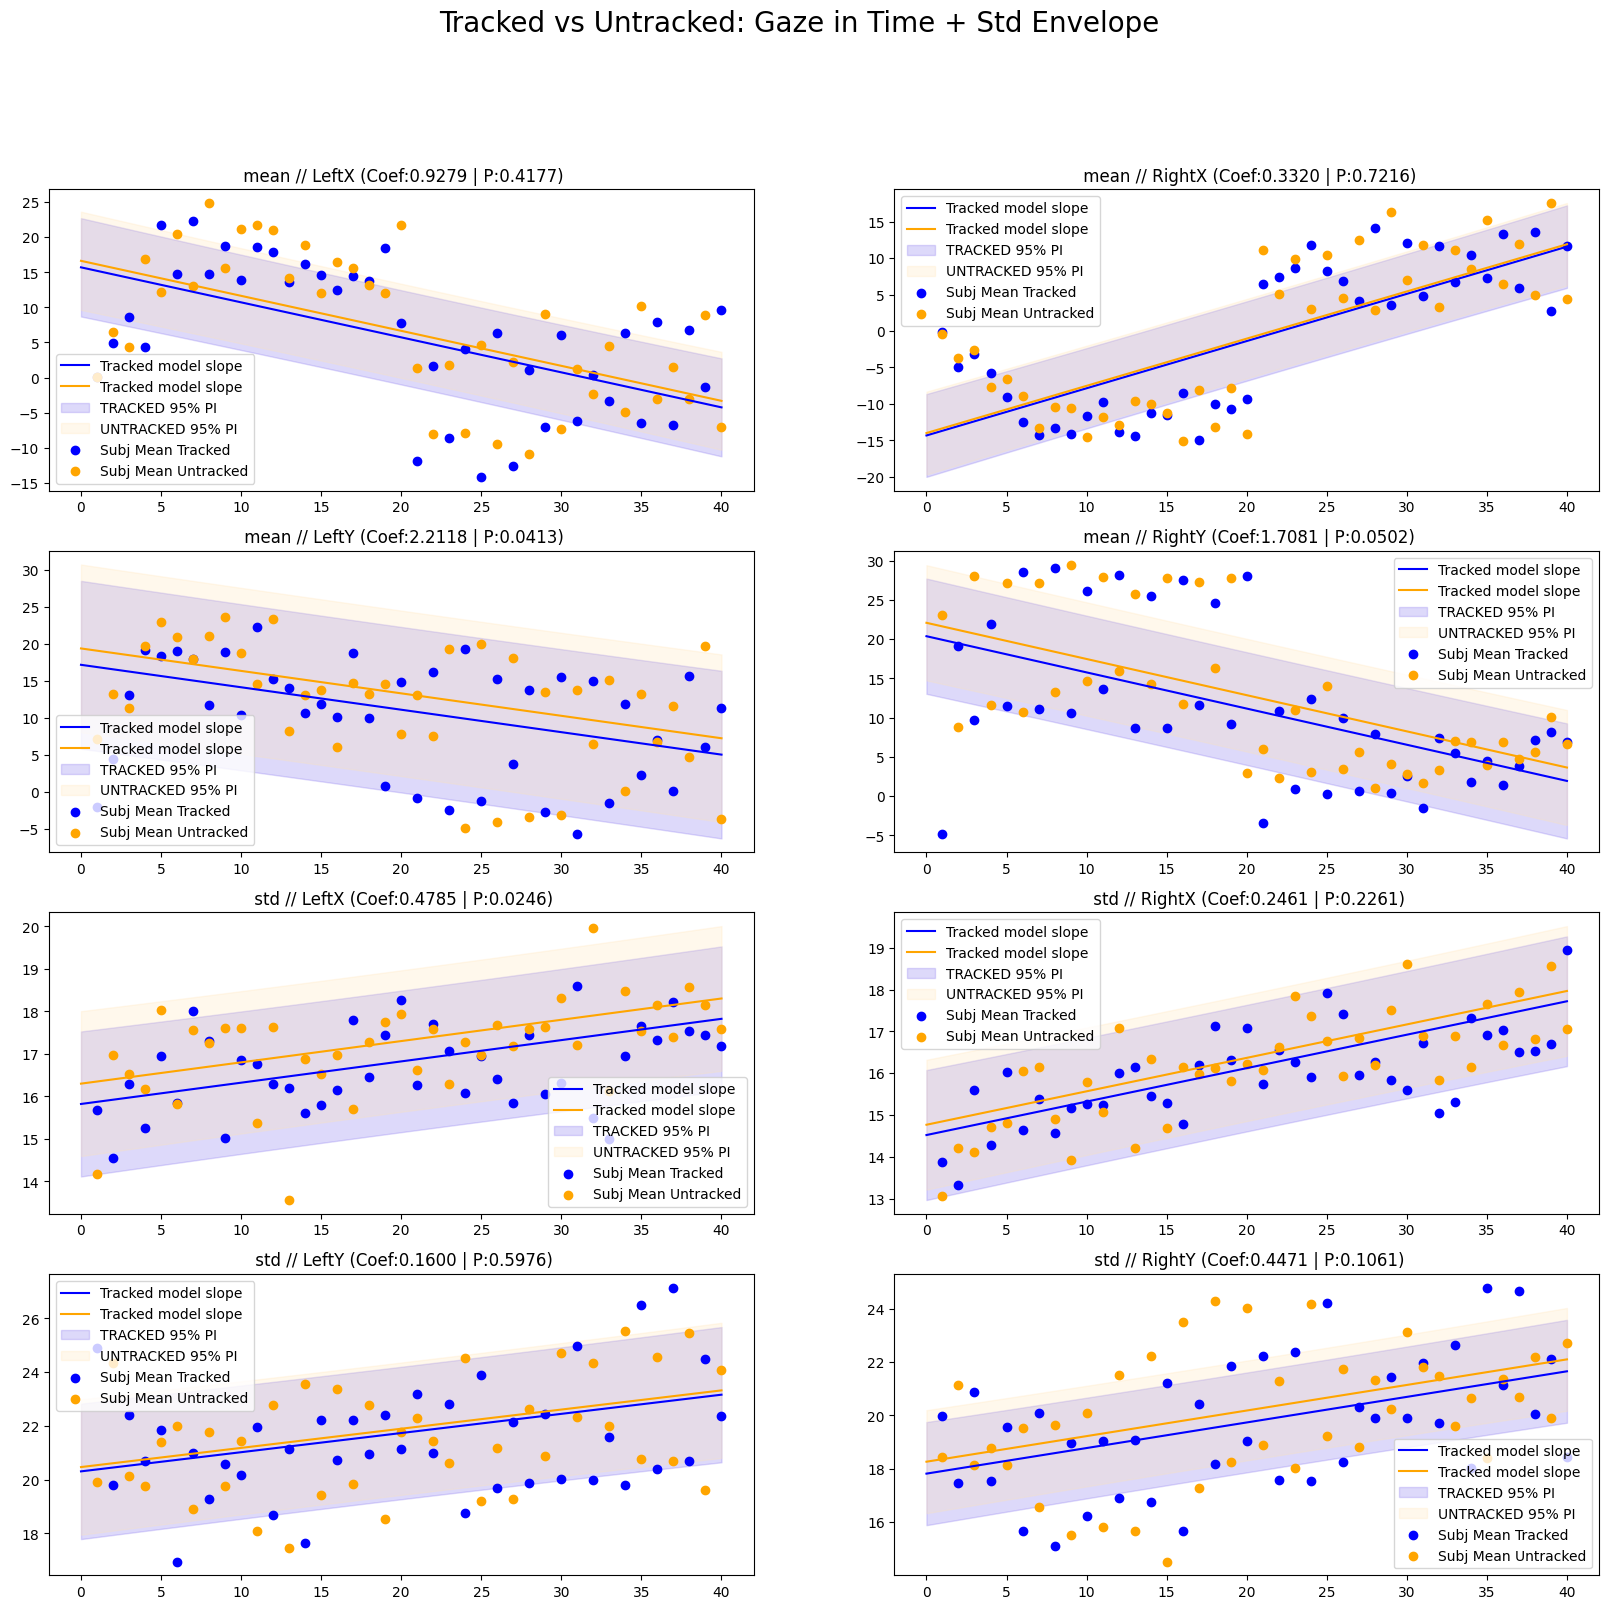

In [440]:
import statsmodels.formula.api as smf
from analysisFunctions import plotTrialTrack
models = []
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Gaze in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.8.1) Gaze Parameters vs Tracking (Gaze ~ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(partiaclCheck0['Gaze'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([partiaclCheck0['Gaze'][ind[0]][ind[1]], partiaclCheck0['DS'], partiaclCheck0['trialNum'], partiaclCheck0['Tracking']]).T
    currentDf.columns = ['Gaze', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Gaze', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Gaze'] = pd.to_numeric(currentDf['Gaze'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Gaze'] - currentDf['Gaze'].mean() <3*currentDf['Gaze'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Gaze ~ Tracking +trialNum ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])


    indx.append("Gaze vs Tracking Corrected")
    eye.append(ind[0])
    analysis.append(ind[1])



    plotTrialTrack(m,"Gaze",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"GzevsTrackinCorr_{est}_{exclusionName}.png"))



======== Test for Pupil Diameter mean // LeftX =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Gaze      
No. Observations: 1127    Method:             REML      
No. Groups:       29      Scale:              401.6606  
Min. group size:  26      Log-Likelihood:     -5024.3112
Max. group size:  40      Converged:          Yes       
Mean group size:  38.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      5.947    3.379  1.760 0.078 -0.675 12.569
MW_Estimate   -1.127    0.614 -1.835 0.066 -2.330  0.077
DS Var       320.613    4.473                           



======== Test for Pupil Diameter mean // RightX =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Gaze      
No. Observations: 1127    Method:             R

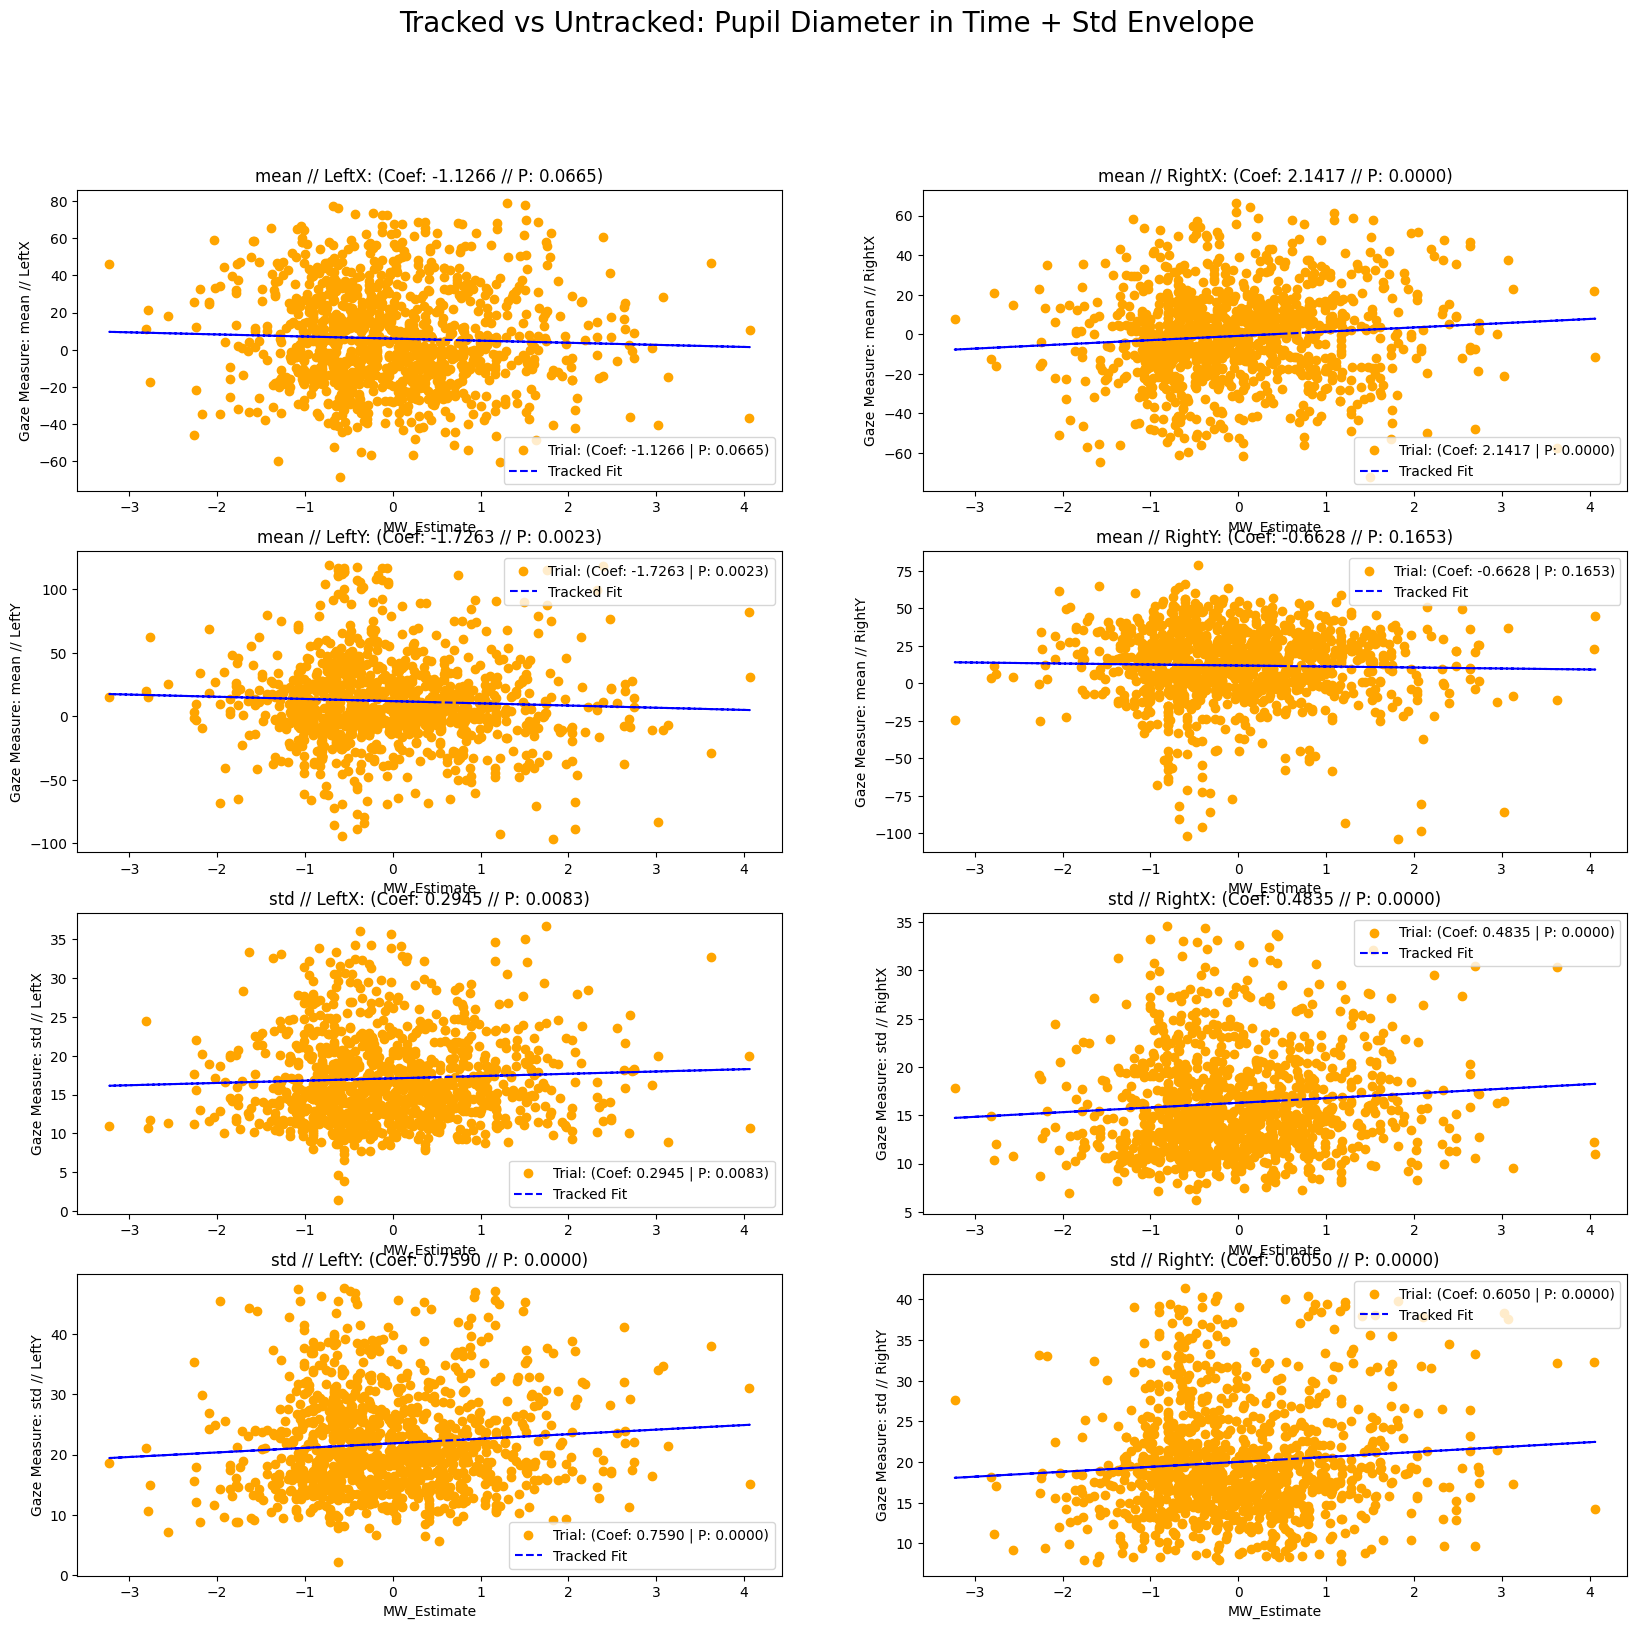

In [441]:
import statsmodels.formula.api as smf
from analysisFunctions import plotTrialTrack
models = []
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,2,figsize=(20,18))
fig.suptitle("Tracked vs Untracked: Pupil Diameter in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.8.2) Gaze Parameters vs MW (Gaze ~ MW_Estimate+ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(partiaclCheck0['Gaze'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Pupil Diameter {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([partiaclCheck0['Gaze'][ind[0]][ind[1]],partiaclCheck0['MW_Estimate'], partiaclCheck0['DS'], partiaclCheck0['trialNum'], partiaclCheck0['Tracking']]).T
    currentDf.columns = ['Gaze','MW_Estimate', 'DS', 'trialNum', 'Tracking']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric    
    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this

    # Clean the data
    currentDf = currentDf.dropna(subset=['Gaze', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Gaze'] = pd.to_numeric(currentDf['Gaze'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Gaze'] - currentDf['Gaze'].mean() <3*currentDf['Gaze'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Gaze ~ MW_Estimate", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Gaze vs MW Corrected")
    eye.append(ind[0])
    analysis.append(ind[1])

    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas='Gaze',meas2=1,tracking=False)

plt.savefig(os.path.join(statPath,f"GazevsMWCorr_{est}_{exclusionName}.png"))

### (1.9) Saccade and BLink Testing

Here we check whethet tracking Untracking Conditions, as well as Mind Wandering depends on Saccades And/ Or Blinks:
WARNING This is for ALL of the duration of Trial


#### (1.9.1) Saccades vs Tracking/Untracking



======== Test for Saccades  // SaccDistance =======

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Saccade   
No. Observations:    1097       Method:                REML      
No. Groups:          29         Scale:                 1151.0020 
Min. group size:     18         Log-Likelihood:        -5475.8950
Max. group size:     40         Converged:             Yes       
Mean group size:     37.8                                        
-----------------------------------------------------------------
                       Coef.   Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               77.316    7.853 9.845 0.000 61.924 92.708
Tracking[T.UNTRACKED]    6.259    2.051 3.052 0.002  2.240 10.278
trialNum                 0.087    0.089 0.976 0.329 -0.087  0.261
DS Var                1632.851   13.366                          



======== Test for Saccades  // S

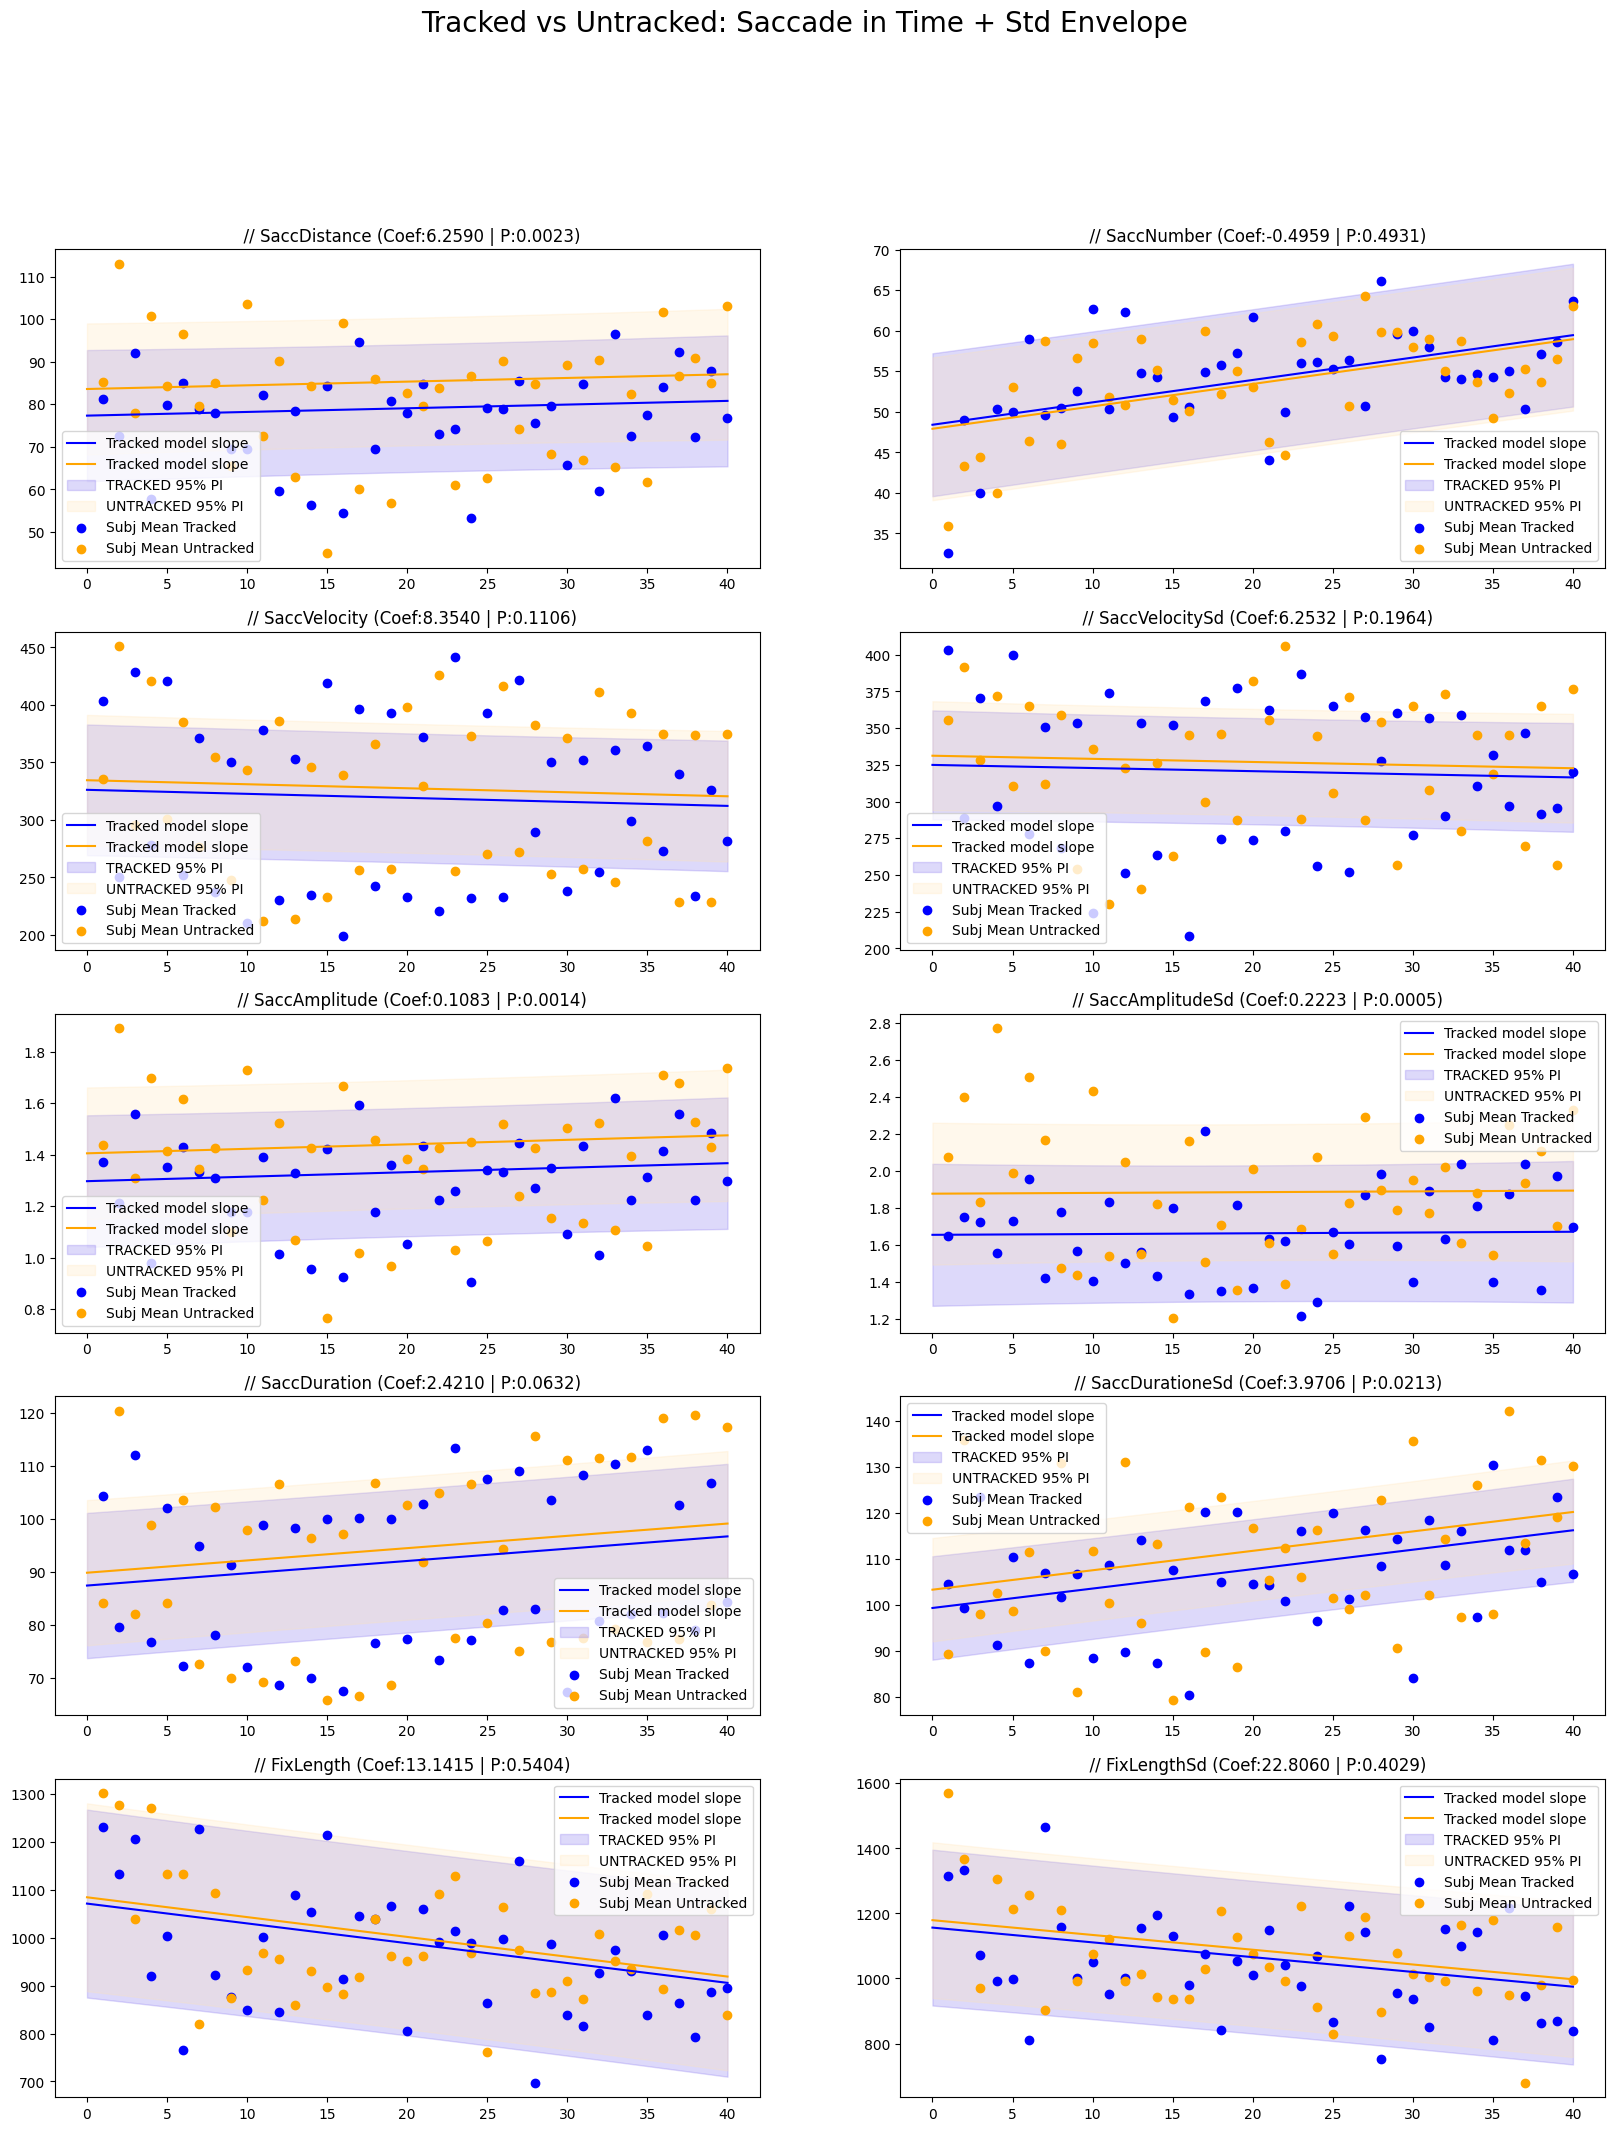

In [442]:
import statsmodels.formula.api as smf
models = []

fig, axes = plt.subplots(5,2,figsize=(20,24))
fig.suptitle("Tracked vs Untracked: Saccade in Time + Std Envelope",fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
log_file.write("\n(1.9.1) Saccade vs Tracking (Saccade ~ Tracking +TrialNum +(1|Subjects)) \n")

for i, ind in enumerate(partiaclCheck0['Saccades'].columns):
    print("\n\n=============================================================")
    print(f"======== Test for Saccades {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([partiaclCheck0['Saccades'][ind[0]][ind[1]], partiaclCheck0['DS'], partiaclCheck0['trialNum'], partiaclCheck0['Tracking'], partiaclCheck0['MW_Estimate']]).T
    currentDf.columns = ['Saccade', 'DS', 'trialNum', 'Tracking','MW_Estimate']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    
    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Saccade', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Saccade'] = pd.to_numeric(currentDf['Saccade'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Saccade'] - currentDf['Saccade'].mean() <3*currentDf['Saccade'].std()]

    # Fit the mixed effects model
    m = smf.mixedlm("Saccade ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
    log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
    
    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])
    indx.append("Saccade Tr Corrected")
    eye.append(ind[0])
    analysis.append(ind[1])

    plotTrialTrack(m,"Saccade",currentDf,axes[i],titl=f" {ind[0]} // {ind[1]} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

plt.savefig(os.path.join(statPath,f"SaccadevsTracking_Corr_{est}_{exclusionName}.png"))

In [443]:
SaccOgr = partiaclCheck0[partiaclCheck0['Saccades']['']['SaccAmplitude'] < 2.5]



======== Test MW vs Saccades  // SaccDistance =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Saccade   
No. Observations: 980     Method:             REML      
No. Groups:       29      Scale:              583.5191  
Min. group size:  1       Log-Likelihood:     -4557.6243
Max. group size:  40      Converged:          Yes       
Mean group size:  33.8                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     70.687    4.626 15.280 0.000 61.620 79.754
MW_Estimate    2.718    0.802  3.387 0.001  1.145  4.290
DS Var       590.986    7.250                           



======== Test MW vs Saccades  // SaccNumber =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Saccade   
No. Observations: 979     Method:             REML  

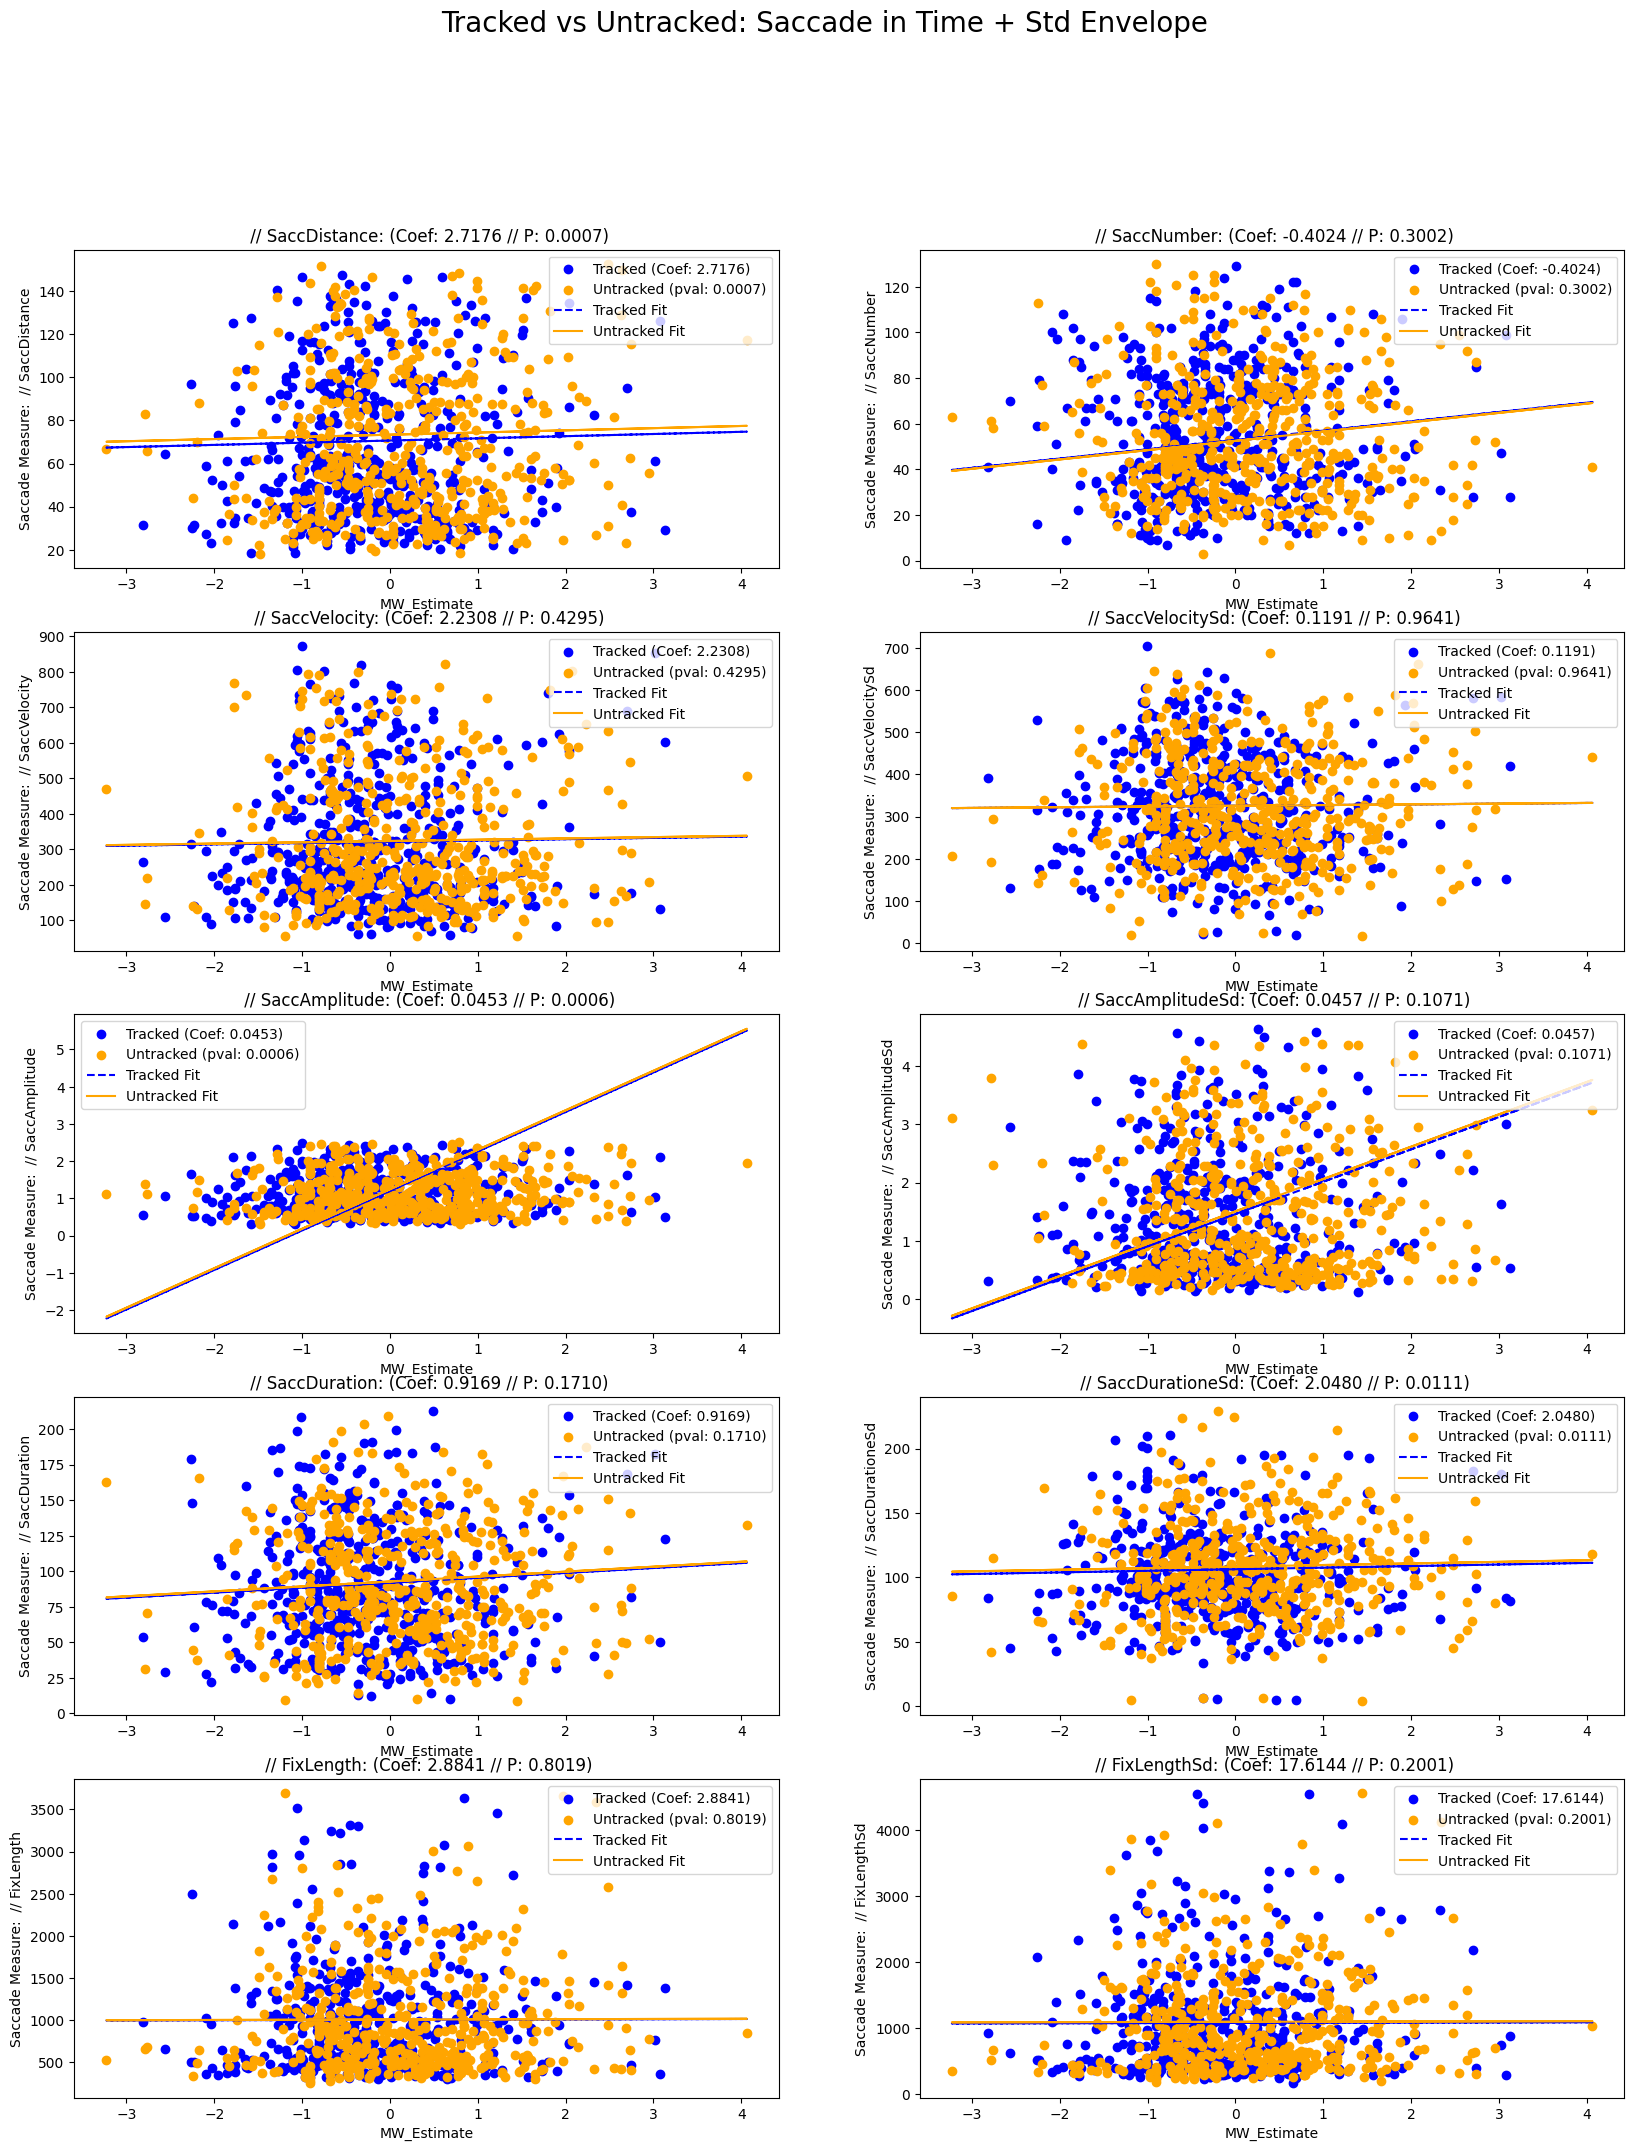

In [444]:
import statsmodels.formula.api as smf
models = []

import matplotlib.pyplot as plt
from analysisFunctions import plot_pupil_vs_mw
fig, axes = plt.subplots(5, 2, figsize=(20, 24))  # Adjust rows/columns as needed
fig.suptitle("Tracked vs Untracked: Saccade in Time + Std Envelope", fontsize=20)
axes = axes.flatten()  # Flatten to easily iterate over axes
currentModels =[];

# log_file.write("\n(1.9.2) Saccades vs MW (Saccade ~ MW +Tracking +(1|Subjects)) \n")

for i, ind in enumerate(SaccOgr['Saccades'].columns):
    print("\n\n=============================================================")
    print(f"======== Test MW vs Saccades {ind[0]} // {ind[1]} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = pd.DataFrame([SaccOgr['Saccades'][ind[0]][ind[1]], SaccOgr['MW_Estimate'], SaccOgr['DS'], SaccOgr['trialNum'], SaccOgr['Tracking']]).T
    currentDf.columns = ['Saccade','MW_Estimate', 'DS', 'trialNum', 'Tracking']

    currentDf['MW_Estimate'] = pd.to_numeric(currentDf['MW_Estimate'], errors='coerce')   # <─ add this
    # Clean the data
    currentDf = currentDf.dropna(subset=['Saccade','MW_Estimate', 'Tracking', 'trialNum'])  # Drop rows with NaN
    currentDf['Saccade'] = pd.to_numeric(currentDf['Saccade'], errors='coerce')  # Ensure numeric
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric
    currentDf = currentDf[currentDf['Saccade'] - currentDf['Saccade'].mean() <3*currentDf['Saccade'].std()]
    # Fit the mixed effects model
    m = smf.mixedlm("Saccade ~ MW_Estimate ", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    currentModels.append(m)
    # log_file.write(f"    {ind[0]} // {ind[1]}  \n")

    # log_file.write(f"      MW Estimate Effect     (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")

    coefs.append(m.params[m.params.keys()[1]])
    zvals.append(m.tvalues[m.params.keys()[1]])
    pvals.append(m.pvalues[m.params.keys()[1]])
    conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
    conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

    coefsT.append(m.params[m.params.keys()[2]])
    zvalsT.append(m.tvalues[m.params.keys()[2]])
    pvalsT.append(m.pvalues[m.params.keys()[2]])
    conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
    conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

    indx.append("Saccade x MW Corrected")
    eye.append(ind[0])
    analysis.append(ind[1])

    print(m.summary())  # ≈ summary(lm(...)) in R
    plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas='Saccade',meas2=1)
plt.savefig(os.path.join(statPath,f"SaccadevsMW_Corr_{est}_{exclusionName}.png"))

In [445]:
plot_pupil_vs_mw(m, currentDf, ind, ax=axes[i],meas='Saccade',meas2=1)


In [446]:


def write_sheet(all_stats, sheet_name, writer,checkCol="P"):
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    for r, pval in enumerate(all_stats[checkCol], start=start_row):
        try:
            if pd.notna(pval) and float(pval) <= 0.05:
                ws.set_row(r, None, bold)
        except Exception:
            pass
# Create a MultiIndex DataFrame and Save All Our Data 

index = pd.MultiIndex.from_arrays([ indx, eye, analysis], names=['Analysis Name', 'Eye', 'Mode'])
stats_df = pd.DataFrame({('Main','Coefficient'): coefs,  ('Main','Z-score'): zvals ,('Main','p-value'): pvals,('Main','conf1'):conf1,('Main','conf2'):conf2,
                         ('Trial','Coefficient'): coefsT,  ('Trial','Z-score'): zvalsT ,('Trial','p-value'): pvalsT,('Trial','conf1'):conf1T,('Trial','conf2'):conf2T}, index=index)

with pd.ExcelWriter(os.path.join(statPath,f"statistics_all_{est}_{exclusionName}.xlsx"), engine="xlsxwriter") as writer:
    write_sheet(stats_df, writer=writer, sheet_name="All_Stats",checkCol=("Main","p-value"))

log_file.close()